In [1]:
import numpy as np
if not hasattr(np, 'longfloat'):
    np.longfloat = np.float64
import serpentTools as st
from pathlib import Path
from numpy.linalg import norm
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import openmc
import openmc.deplete
import scipy as sp

# Global style defaults applied to all figures
plt.rcParams.update({
    'font.size':        14,
    'axes.labelsize':   16,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  13,
    'lines.linewidth':  2.5,
    'lines.markersize': 7,
    'errorbar.capsize': 4,
})


# Post-Processing Functions

In [3]:
def calculate_reactivity(keff, keff_err, confidence_factor=3):
    """Calculate reactivity and uncertainty from keff values."""
    rho = (1 - 1/keff) * 1e5  # Convert to pcm
    rho_err = confidence_factor * (1/keff**2) * keff_err * 1e5
    return rho, rho_err

def load_openmc_results(filepath):
    """Load OpenMC depletion results and calculate reactivity."""
    results = openmc.deplete.Results(filename=filepath)
    time, keff = results.get_keff(time_units='d')
    k_values = keff[:, 0]
    k_errors = keff[:, 1]
    rho, rho_err = calculate_reactivity(k_values, k_errors)
    burnup = time * 0.600 / 6.56
    return burnup, rho, rho_err

def load_serpent_results(res_path, dep_path):
    """Load Serpent results and calculate reactivity."""
    dep = st.read(res_path)
    burnup = st.read(dep_path).burnup
    k_values = dep['impKeff'][:, 0]
    k_errors = dep['impKeff'][:, 1]
    rho, rho_err = calculate_reactivity(k_values, k_errors)
    return burnup, rho, rho_err

def adjust_for_hydrogen_loss(rho, burnup, bias_correction=574.099788591,
                             h_loss_rate=260.401947391,
                             h_loss_threshold_index=25,
                             burnup_value=12.3476,
                             use_polynomial=False):
    rho_corrected = rho + bias_correction
    if use_polynomial:
        def cumulative_hydrogen_loss(bu, bu0):
            def integral(b):
                return (2.338230e-6*b**7 - 2.726511e-4*b**6 + 1.161189e-2*b**5 -
                        2.286456e-1*b**4 + 2.317447*b**3 - 9.012680*b**2 +
                        6.736471e+1*b)
            return integral(bu) - integral(bu0)
        hydrogen_loss = np.zeros_like(burnup)
        bu0 = burnup[0]
        for i in range(len(burnup)):
            hydrogen_loss[i] = cumulative_hydrogen_loss(burnup[i], bu0)
    else:
        hydrogen_loss = np.zeros_like(burnup)
        hydrogen_loss[h_loss_threshold_index:] = h_loss_rate * (
            burnup[h_loss_threshold_index:] - burnup_value)
    rho_adjusted = rho_corrected - hydrogen_loss
    return rho_adjusted

def calculate_heat_transfer_coefficient(temperature_kelvin):
    x = temperature_kelvin
    coefficient = -3e-10*x**4 + 9e-7*x**3 - 0.001*x**2 + 0.5402*x - 99.739
    return coefficient

def coolant_flow_heat_capacity(T_c, T_f):
    UA = calculate_heat_transfer_coefficient(T_c)
    dT = 111.708
    return UA*(T_f - T_c)/dT

def power_change(T_i, T_f):
    UA = calculate_heat_transfer_coefficient(T_f)
    dT = T_f - T_i
    return UA*dT, UA

def normalize_array(arr):
    integrated_value = np.mean(arr)
    normalized_array = arr/integrated_value
    return normalized_array

def volume_normalize(valarr, minLen, maxLen):
    normalized_array = valarr
    for i in range(0, len(minLen)):
        norm_factor = np.pi * (maxLen[i]**2 - minLen[i]**2)
        normalized_array[i] = valarr[i]/norm_factor
    return normalized_array

def plot_tallies_from_hex_fix_x(detector, tolerance=1e-6, sigma=1, normalize=False, norm_type='unity'):
    centers = detector.centers
    tallies = detector.tallies
    errors = detector.errors
    x_coords = centers[:, 0]
    y_coords = centers[:, 1]
    at_x_zero = np.abs(x_coords) <= tolerance
    y_at_x_zero = y_coords[at_x_zero]
    tallies_at_x_zero = tallies.flat[at_x_zero]
    errors_at_x_zero = errors.flat[at_x_zero]
    absolute_errors = tallies_at_x_zero * errors_at_x_zero * sigma
    sort_indices = np.argsort(y_at_x_zero)
    y_sorted = y_at_x_zero[sort_indices]
    tallies_sorted = tallies_at_x_zero[sort_indices]
    errors_sorted = absolute_errors[sort_indices]
    if normalize:
        if norm_type == 'unity':
            from scipy import integrate
            integral = integrate.simpson(tallies_sorted, y_sorted)
            if integral > 0:
                tallies_sorted = tallies_sorted / integral
                errors_sorted = errors_sorted / integral
        elif norm_type == 'peak':
            peak_idx   = np.argmax(tallies_sorted)
            peak_value = tallies_sorted[peak_idx]
            peak_err   = errors_sorted[peak_idx]   # absolute σ of the peak bin
            if peak_value > 0:
                f              = tallies_sorted / peak_value
                errors_sorted  = (1.0 / peak_value) * np.sqrt(
                                    errors_sorted**2 + (f * peak_err)**2
                                )
                tallies_sorted = f
                print(errors_sorted)
    return y_sorted, tallies_sorted, errors_sorted

def plot_tallies_from_hex_axial(detector, tolerance=1e-6, sigma=3, normalize=False, norm_type='unity'):
    tallies = detector.tallies
    errors = detector.errors
    z_data = detector.grids['Z']
    z_coords = np.array([z_array[2] for z_array in z_data])
    tallies_axial = tallies.flat if tallies.ndim > 1 else tallies
    errors_axial = errors.flat if errors.ndim > 1 else errors
    min_length = min(len(z_coords), len(tallies_axial), len(errors_axial))
    z_coords = z_coords[:min_length]
    tallies_axial = tallies_axial[:min_length] * 0.0433551586803
    errors_axial = errors_axial[:min_length]
    absolute_errors = tallies_axial * errors_axial * sigma
    sort_indices = np.argsort(z_coords)
    z_sorted = z_coords[sort_indices]
    tallies_sorted = tallies_axial[sort_indices]
    errors_sorted = absolute_errors[sort_indices]
    if normalize:
        if norm_type == 'unity':
            from scipy import integrate
            integral = integrate.simpson(tallies_sorted, z_sorted)
            if integral > 0:
                tallies_sorted = tallies_sorted / integral
                errors_sorted = errors_sorted / integral
        elif norm_type == 'peak':
            peak_idx   = np.argmax(tallies_sorted)
            peak_value = tallies_sorted[peak_idx]
            peak_err   = errors_sorted[peak_idx]   # absolute σ of the peak bin
            if peak_value > 0:
                f              = tallies_sorted / peak_value
                errors_sorted  = (1.0 / peak_value) * np.sqrt(
                                    errors_sorted**2 + (f * peak_err)**2
                                )
                tallies_sorted = f
                print(errors_sorted)
    return z_sorted, tallies_sorted, errors_sorted

def analyze_power_distribution(analysis_type='radial', normalize=False, norm_type='unity'):
    current_dir = Path.cwd()
    base_path = current_dir / "Serpent/power_distrib"

    if analysis_type == 'radial':
        detector_name = 'PinMesh1'
        csv_suffix = '_rad.csv'
        coord_column = 'Points:1'
        coord_label = 'Radial Position [cm]'
        plot_function = plot_tallies_from_hex_fix_x
    else:
        detector_name = 'rmesh'
        csv_suffix = '_axi.csv'
        coord_column = 'Points:2'
        coord_label = 'Axial Position [cm]'
        plot_function = plot_tallies_from_hex_axial

    if normalize:
        ylabel = 'Normalized Power' if norm_type == 'peak' else 'Normalized Power Distribution [1/cm]'
    else:
        ylabel = 'Power [W]'

    file_configs = [
        (base_path / '5_MWd/s82d_ac_c3_gcu_ringres.main_det0.m',  'Serpent 5 MWd'),
        (base_path / '10_MWd/s82d_ac_c3_gcu_ringres.main_det0.m', 'Serpent 10 MWd'),
        (base_path / '15_MWd/s82d_ac_c3_gcu_ringres.main_det0.m', 'Serpent 15 MWd'),
    ]

    all_data = []
    plt.style.use('tableau-colorblind10')
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    serpent_color = colors[1]
    griffin_Tfuel_color = colors[2]

    for file_path, label in file_configs:
        step_data = st.read(file_path)
        step_res = step_data.detectors[detector_name]
        normalization_factor = 280.346931947 * 1000
        step_res._tallies *= normalization_factor
        step_res.hexType = 3
        step_res.pitch = 1.4603179929725998
        coords, tallies, abs_errors = plot_function(step_res, tolerance=1e-6, sigma=3,
                                                    normalize=normalize, norm_type=norm_type)
        all_data.append((coords, tallies, abs_errors, label))

    csv_configs = [
        (base_path / f'5_MWd/pow_density_5{csv_suffix}',  'Griffin 5 MWd'),
        (base_path / f'10_MWd/pow_density_10{csv_suffix}', 'Griffin 10 MWd'),
        (base_path / f'15_MWd/pow_density_15{csv_suffix}', 'Griffin 15 MWd'),
    ]

    for file_path, label in csv_configs:
        csv_data = pd.read_csv(file_path)
        tallies = csv_data['griffin_power_density_prompt_ene'].values * 0.0137696
        coords = csv_data[coord_column].values * 100
        abs_errors = np.zeros_like(tallies)
        if normalize:
            from scipy import integrate
            sorted_idx = np.argsort(coords)
            if norm_type == 'unity':
                integral = integrate.simpson(tallies[sorted_idx], coords[sorted_idx])
                if integral > 0:
                    tallies = tallies / integral
                    abs_errors = abs_errors / integral
            elif norm_type == 'peak':
                peak_value = np.max(tallies)
                if peak_value > 0:
                    tallies = tallies / peak_value
                    abs_errors = abs_errors / peak_value
        all_data.append((coords, tallies, abs_errors, label))

    plt.figure(figsize=(12, 8))

    serpent_colors = ['#08306b', '#4292c6', '#9ecae1']
    griffin_colors  = ['#67000d', '#ef3b2c', '#fc9272']
    line_styles  = ['-',  '--',  '-' ]
    linewidths   = [2.5,   3.0,  1.5 ]
    markers      = ['o',  None,  None]
    markersizes  = [7,      0,     0  ]

    for i, (coords, tallies, abs_errors, label) in enumerate(all_data):
        mwd_index = i % 3
        is_griffin = i >= 3
        color   = griffin_colors[mwd_index] if is_griffin else serpent_colors[mwd_index]
        ls      = line_styles[mwd_index]
        lw      = linewidths[mwd_index]
        marker  = markers[mwd_index]
        ms      = markersizes[mwd_index]
        display_label = label.replace('Griffin', 'Griffin Multiphysics') if is_griffin else label
        display_label = display_label.replace('MWd', 'MWd/kg')

        plt.errorbar(
            coords, tallies, yerr=abs_errors,
            fmt=f'{marker if marker else ""}{ls}',
            color=color, linewidth=lw, markersize=ms,
            markerfacecolor=color, markeredgecolor=color,
            capsize=4, capthick=1.5, label=display_label,
        )

    plt.ylabel(ylabel,      fontsize=16)
    plt.xlabel(coord_label, fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if not normalize:
        from scipy import integrate
        serpent_integrals = []
        griffin_integrals = []
        burnup_levels = ['5 MWd', '10 MWd', '15 MWd']
        relative_differences = []

        integration_title = f'{analysis_type.capitalize()} Integration Results:'
        print(f"\n{integration_title}")
        print("=" * 60)

        for i in range(3):
            serpent_data = all_data[i]
            griffin_data = all_data[i + 3]
            serpent_coords, serpent_tallies, _, _ = serpent_data
            griffin_coords, griffin_tallies, _, _ = griffin_data
            serpent_sorted_idx = np.argsort(serpent_coords)
            griffin_sorted_idx = np.argsort(griffin_coords)
            serpent_integral = integrate.simpson(serpent_tallies[serpent_sorted_idx], serpent_coords[serpent_sorted_idx])
            griffin_integral = integrate.simpson(griffin_tallies[griffin_sorted_idx], griffin_coords[griffin_sorted_idx])
            serpent_integrals.append(serpent_integral)
            griffin_integrals.append(griffin_integral)
            relative_diff = (serpent_integral - griffin_integral) / griffin_integral * 100
            relative_differences.append(relative_diff)
            print(f"\n{burnup_levels[i]}:")
            print(f"  Serpent integrated power: {serpent_integral:.6e} W·cm")
            print(f"  Griffin integrated power: {griffin_integral:.6e} W·cm")
            print(f"  Relative difference: {relative_diff:.2f}%")

        plt.figure(figsize=(12, 8))
        x = np.arange(len(burnup_levels))
        width = 0.35
        serpent_bars = plt.bar(x - width/2, serpent_integrals, width,
                               label='Serpent', color=serpent_color, alpha=0.7)
        griffin_bars = plt.bar(x + width/2, griffin_integrals, width,
                               label='Griffin', color=griffin_Tfuel_color, alpha=0.7)
        plt.xlabel('Burnup Level', fontsize=16)
        plt.ylabel('Integrated Power [W·cm]', fontsize=16)
        plt.xticks(x, burnup_levels, fontsize=14)
        plt.yticks(fontsize=14)
        plt.legend(fontsize=13)
        plt.grid(True, alpha=0.3, axis='y')
        for i, (sb, gb) in enumerate(zip(serpent_bars, griffin_bars)):
            plt.text(sb.get_x() + sb.get_width()/2,
                     sb.get_height() + max(serpent_integrals + griffin_integrals)*0.01,
                     f'{serpent_integrals[i]:.3e}', ha='center', va='bottom', fontsize=11)
            plt.text(gb.get_x() + gb.get_width()/2,
                     gb.get_height() + max(serpent_integrals + griffin_integrals)*0.01,
                     f'{griffin_integrals[i]:.3e}', ha='center', va='bottom', fontsize=11)
        plt.tight_layout()
        plt.show()

        summary_title = f'{analysis_type.upper()} POWER DISTRIBUTION SUMMARY TABLE'
        print("\n" + "="*80)
        print(summary_title)
        print("="*80)
        print(f"{'Burnup':<10} {'Serpent [W·cm]':<25} {'Griffin [W·cm]':<25} {'Rel. Diff [%]':<12}")
        print("-"*80)
        for i in range(3):
            print(f"{burnup_levels[i]:<10} {serpent_integrals[i]:<25.6e} {griffin_integrals[i]:<25.6e} {relative_differences[i]:<12.2f}")
        print("="*80)
        return all_data, serpent_integrals, griffin_integrals, relative_differences
    else:
        print("\nNote: Distributions are normalized. Integration analysis skipped.")
        return all_data, None, None, None

def extract_peak_points(csv_file_path, tolerance=5e5):
    df = pd.read_csv(csv_file_path)
    valid_data = df.dropna(subset=['heat_source', 'heat_source_std_dev', 'Points:0']).copy()
    valid_data = valid_data.sort_values('Points:0').reset_index(drop=True)
    print(f"Processing {len(valid_data)} valid data points...")
    peaks = []
    current_peak = []
    last_value = None
    for idx, row in valid_data.iterrows():
        current_value = row['heat_source']
        if last_value is None or abs(current_value - last_value) <= tolerance:
            current_peak.append(idx)
        else:
            if len(current_peak) > 0:
                peaks.append(current_peak)
            current_peak = [idx]
        last_value = current_value
    if len(current_peak) > 0:
        peaks.append(current_peak)
    print(f"Identified {len(peaks)} potential peaks")
    significant_peaks = [peak for peak in peaks if len(peak) >= 3]
    print(f"Found {len(significant_peaks)} significant flat peaks")
    peak_points = []
    for i, peak_indices in enumerate(significant_peaks):
        middle_idx = peak_indices[len(peak_indices) // 2]
        peak_point = valid_data.loc[middle_idx].copy()
        peak_point['peak_id'] = i + 1
        peak_point['peak_size'] = len(peak_indices)
        peak_point['peak_start_position'] = valid_data.loc[peak_indices[0]]['Points:0']
        peak_point['peak_end_position'] = valid_data.loc[peak_indices[-1]]['Points:0']
        peak_points.append(peak_point)
        print(f"Peak {i+1}: heat_source={peak_point['heat_source']:.3e}, "
              f"std_dev={peak_point['heat_source_std_dev']:.3e}, "
              f"position={peak_point['Points:0']:.6f}, "
              f"peak_size={len(peak_indices)} points")
    result_df = pd.DataFrame(peak_points)
    return result_df

def extract_data_points(csv_file_path):
    result_df = pd.read_csv(csv_file_path)
    return result_df

def analyze_power_distribution_BOL(analysis_type='radial', normalize=False, norm_type='unity'):
    current_dir = Path.cwd()
    base_path = current_dir / "Serpent/power_distrib"
    openmc_path = current_dir / "OpenMC_Cardinal/standard_conditions"
    griffin_path = current_dir / "Griffin/standard_conditions/griffin_standalone"

    if analysis_type == 'radial':
        detector_name = 'PinMesh1'
        csv_suffix = '_rad.csv'
        coord_column = 'Points:0'
        coord_label = 'Radial Position [cm]'
        plot_function = plot_tallies_from_hex_fix_x
        openmc_data_fun = extract_peak_points
    else:
        detector_name = 'rmesh'
        csv_suffix = '_axi.csv'
        coord_column = 'Points:2'
        coord_label = 'Axial Position [cm]'
        plot_function = plot_tallies_from_hex_axial
        openmc_data_fun = extract_data_points

    if normalize:
        ylabel = 'Normalized Power' if norm_type == 'peak' else 'Normalized Power Distribution [1/cm]'
    else:
        ylabel = 'Power [W]'

    file_configs = [
        (base_path / '0_MWd/s82d_ac_c3_gcu_ringres.main_det0.m', 'Serpent')
    ]

    all_data = []
    plt.style.use('tableau-colorblind10')
    colors = [
        '#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB',
    ]
    serpent_color          = colors[1]
    griffin_multi_color    = colors[2]
    griffin_standalone_color = colors[3]
    openmc_multi_color     = colors[4]
    openmc_standalone_color = colors[6]

    for file_path, label in file_configs:
        step_data = st.read(file_path)
        step_res = step_data.detectors[detector_name]
        normalization_factor = 280.346931947 * 1000
        step_res._tallies *= normalization_factor
        step_res.hexType = 3
        step_res.pitch = 1.4603179929725998
        coords, tallies, abs_errors = plot_function(step_res, tolerance=1e-6, sigma=3,
                                                    normalize=normalize, norm_type=norm_type)
        all_data.append((coords, tallies, abs_errors, label))

    csv_configs = [(base_path / f'0_MWd/pow_density_0{csv_suffix}', 'Griffin Multiphysics')]
    for file_path, label in csv_configs:
        csv_data = pd.read_csv(file_path)
        tallies = csv_data['griffin_power_density'].values * 1.376959e-02
        coords = csv_data[coord_column].values * 100
        abs_errors = np.zeros_like(tallies)
        if normalize:
            from scipy import integrate
            sorted_idx = np.argsort(coords)
            if norm_type == 'unity':
                integral = integrate.simpson(tallies[sorted_idx], coords[sorted_idx])
                if integral > 0:
                    tallies = tallies / integral; abs_errors = abs_errors / integral
            elif norm_type == 'peak':
                peak_value = np.max(tallies)
                if peak_value > 0:
                    tallies = tallies / peak_value; abs_errors = abs_errors / peak_value
        all_data.append((coords, tallies, abs_errors, label))

    csv_configs = [(griffin_path / f'pow_density{csv_suffix}', 'Griffin Standalone')]
    for file_path, label in csv_configs:
        csv_data = pd.read_csv(file_path)
        tallies = csv_data['griffin_power_density'].values * 1.376959e-02
        coords = csv_data[coord_column].values * 100
        abs_errors = np.zeros_like(tallies)
        if normalize:
            from scipy import integrate
            sorted_idx = np.argsort(coords)
            if norm_type == 'unity':
                integral = integrate.simpson(tallies[sorted_idx], coords[sorted_idx])
                if integral > 0:
                    tallies = tallies / integral; abs_errors = abs_errors / integral
            elif norm_type == 'peak':
                peak_value = np.max(tallies)
                if peak_value > 0:
                    tallies = tallies / peak_value; abs_errors = abs_errors / peak_value
        all_data.append((coords, tallies, abs_errors, label))

    csv_configs = [(openmc_path / f'OpenMC_data{csv_suffix}', 'OpenMC Multiphysics')]
    for file_path, label in csv_configs:
        csv_data = openmc_data_fun(file_path)
        tallies = csv_data['heat_source'].values
        coords = csv_data[coord_column].values * 100
        if analysis_type != 'radial':
            coords = coords + 1.778
        abs_errors = csv_data['heat_source_std_dev'].values * 3
        if normalize:
            from scipy import integrate
            sorted_idx = np.argsort(coords)
            if norm_type == 'unity':
                integral = integrate.simpson(tallies[sorted_idx], coords[sorted_idx])
                if integral > 0:
                    tallies = tallies / integral; abs_errors = abs_errors / integral
            elif norm_type == 'peak':
                peak_value = np.max(tallies)
                if peak_value > 0:
                    tallies = tallies / peak_value; abs_errors = abs_errors / peak_value
        all_data.append((coords, tallies, abs_errors, label))

    csv_configs = [(openmc_path / f'../OpenMC_standalone/OpenMC_data{csv_suffix}', 'OpenMC Standalone')]
    for file_path, label in csv_configs:
        csv_data = openmc_data_fun(file_path)
        tallies = csv_data['heat_source'].values
        coords = csv_data[coord_column].values * 100
        if analysis_type != 'radial':
            coords = coords + 1.778
        abs_errors = csv_data['heat_source_std_dev'].values * 3
        if normalize:
            from scipy import integrate
            sorted_idx = np.argsort(coords)
            if norm_type == 'unity':
                integral = integrate.simpson(tallies[sorted_idx], coords[sorted_idx])
                if integral > 0:
                    tallies = tallies / integral; abs_errors = abs_errors / integral
            elif norm_type == 'peak':
                peak_value = np.max(tallies)
                if peak_value > 0:
                    tallies = tallies / peak_value; abs_errors = abs_errors / peak_value
        all_data.append((coords, tallies, abs_errors, label))

    plt.figure(figsize=(12, 8))
    markers    = ['o', 's', '^', 'D', 'v']
    labels_list = ['Serpent', 'Griffin Multiphysics', 'Griffin Standalone',
                   'OpenMC Multiphysics', 'OpenMC Standalone']
    color_list = [serpent_color, griffin_multi_color, griffin_standalone_color,
                  openmc_multi_color, openmc_standalone_color]

    for i, (coords, tallies, abs_errors, label) in enumerate(all_data):
        if len(tallies) > 0:
            print(f"{label} - Max power: {max(tallies):.6e} - Data points: {len(tallies)}")
        else:
            print(f"{label} - No data found (empty tallies array)")
            continue
        plt.errorbar(coords, tallies, yerr=abs_errors,
                     fmt=f'{markers[i]}-',
                     color=color_list[i],
                     linewidth=2.5, markersize=7,
                     capsize=4, capthick=1.5,
                     label=label, alpha=0.85)

    plt.xlabel(coord_label, fontsize=16)
    plt.ylabel(ylabel,      fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=13, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return all_data, labels_list


In [4]:
"""
Post-processing corrections for Serpent depletion reactivity results.
"""

import numpy as np
from scipy.interpolate import interp1d
from enum import IntEnum

class CorrectionMode(IntEnum):
    BIAS_ONLY           = 1
    BIAS_LONGTERM       = 2
    BIAS_LONGTERM_HLOSS = 3

_LONGTERM_BURNUP = np.array([
    0.070967888, 0.425807331, 0.603227052, 0.887098606, 1.241938048,
    1.490325657, 1.8451651,   2.235488486, 2.625811873, 3.19355498,
    3.903233865, 4.861300359, 5.677431076, 6.138722351, 6.848401235,
    7.487112231, 8.409694781, 9.296793387, 10.21937594, 11.00002271,
    11.81615343, 12.77421992, 13.59035064, 14.26454558, 15.00970841,
    15.79035518, 16.53551801, 17.06777717, 17.74197211, 18.48713494,
    19.16132988, 19.90649271, 20.50971976, 21.36133442, 22.1419812,
    23.06456375, 23.95166235, 24.8742449,  25.61940773, 26.47102239,
    27.25166916, 28.03231594, 28.03231594, 28.95489849, 29.91296498,
    30.7290957,
])

_LONGTERM_RHO = np.array([
    -3.3,   46.2,   77.0,  113.3,  150.7,  191.4,  228.8,  268.4,
    310.2,  354.2,  394.9,  436.7,  465.3,  478.5,  485.1,  490.6,
    492.8,  487.3,  478.5,  464.2,  447.7,  425.7,  402.6,  380.6,
    350.9,  330.0,  304.7,  281.6,  255.2,  227.7,  198.0,  169.4,
    141.9,  105.6,   69.3,   28.6,   -8.8,  -52.8,  -85.8, -127.6,
   -162.8, -200.2, -200.2, -244.2, -290.4, -328.9,
])

_longterm_interp = interp1d(
    _LONGTERM_BURNUP, _LONGTERM_RHO,
    kind="linear", bounds_error=False,
    fill_value=(_LONGTERM_RHO[0], _LONGTERM_RHO[-1]),
)

def _hydrogen_loss(burnup, h_loss_rate=260.401947391,
                   h_loss_threshold_index=25, burnup_value=12.3476,
                   use_polynomial=False):
    hydrogen_loss = np.zeros_like(burnup, dtype=float)
    if use_polynomial:
        def _integral(b):
            return (2.338230e-6*b**7 - 2.726511e-4*b**6 + 1.161189e-2*b**5
                    - 2.286456e-1*b**4 + 2.317447*b**3 - 9.012680*b**2
                    + 6.736471e+1*b)
        bu0 = burnup[0]
        for i, bu in enumerate(burnup):
            hydrogen_loss[i] = _integral(bu) - _integral(bu0)
    else:
        idx = h_loss_threshold_index
        hydrogen_loss[idx:] = h_loss_rate * (burnup[idx:] - burnup_value)
    return hydrogen_loss

def apply_corrections(rho, burnup, mode=CorrectionMode.BIAS_LONGTERM_HLOSS,
                      bias_correction=574.099788591, h_loss_rate=260.401947391,
                      h_loss_threshold_index=25, h_loss_burnup_value=12.3476,
                      use_polynomial_hloss=False):
    rho    = np.asarray(rho,    dtype=float)
    burnup = np.asarray(burnup, dtype=float)
    if rho.shape != burnup.shape:
        raise ValueError("rho and burnup must have the same shape.")
    result = {"rho_raw": rho.copy(), "rho_bias": None, "rho_longterm": None,
              "rho_hloss": None, "longterm_delta": None, "hloss_delta": None, "mode": mode}
    rho_bias = rho + bias_correction
    result["rho_bias"] = rho_bias
    if mode == CorrectionMode.BIAS_ONLY:
        return result
    longterm_delta = _longterm_interp(burnup)
    rho_longterm   = rho_bias + longterm_delta
    result["longterm_delta"] = longterm_delta
    result["rho_longterm"]   = rho_longterm
    if mode == CorrectionMode.BIAS_LONGTERM:
        return result
    hloss_delta = _hydrogen_loss(burnup, h_loss_rate=h_loss_rate,
                                 h_loss_threshold_index=h_loss_threshold_index,
                                 burnup_value=h_loss_burnup_value,
                                 use_polynomial=use_polynomial_hloss)
    rho_hloss = rho_longterm - hloss_delta
    result["hloss_delta"] = hloss_delta
    result["rho_hloss"]   = rho_hloss
    return result

if __name__ == "__main__":
    burnup_example = np.linspace(0.1, 30.0, 50)
    rho_example    = np.zeros_like(burnup_example)
    for mode in CorrectionMode:
        res = apply_corrections(rho_example, burnup_example, mode=mode)
        label = {CorrectionMode.BIAS_ONLY: "Bias only",
                 CorrectionMode.BIAS_LONGTERM: "Bias + long-term",
                 CorrectionMode.BIAS_LONGTERM_HLOSS: "Bias + long-term + H-loss"}[mode]
        final = (res["rho_hloss"] if mode == CorrectionMode.BIAS_LONGTERM_HLOSS else
                 res["rho_longterm"] if mode == CorrectionMode.BIAS_LONGTERM else res["rho_bias"])
        print(f"[Mode {int(mode)}] {label}: rho @ 15 MWd/kgU ≈ {np.interp(15.0, burnup_example, final):.1f} pcm")


[Mode 1] Bias only: rho @ 15 MWd/kgU ≈ 574.1 pcm
[Mode 2] Bias + long-term: rho @ 15 MWd/kgU ≈ 927.3 pcm
[Mode 3] Bias + long-term + H-loss: rho @ 15 MWd/kgU ≈ 599.9 pcm


# Mesh Refinement Study

## Axial Refine for Fuel and Coolant

READING DATA FILES
5_node: Fuel T_max = 1051.500 K, Coolant T_max = 964.000 K, Reflector T_max = 917.720 K
10_node: Fuel T_max = 1033.100 K, Coolant T_max = 970.960 K, Reflector T_max = 925.620 K
20_node: Fuel T_max = 1035.800 K, Coolant T_max = 967.320 K, Reflector T_max = 927.860 K
30_node: Fuel T_max = 1037.100 K, Coolant T_max = 968.240 K, Reflector T_max = 929.630 K

MAX FUEL TEMPERATURE CONVERGENCE
Nodes      T_max [K]       Rel. Diff.     
----------------------------------------------------------------------
5          1051.500000     N/A            
10         1033.100000     1.781047e-02   
20         1035.800000     2.606681e-03   
30         1037.100000     1.253495e-03   

RELATIVE L² NORM CONVERGENCE (FUEL)
Comparison           Rel. L² Norm   
----------------------------------------------------------------------
5 → 10 nodes        2.422714e-02   
10 → 20 nodes        5.602707e-03   
20 → 30 nodes        3.385674e-03   

Convergence threshold: 5.0e-03
10 nodes: ✗ Not con

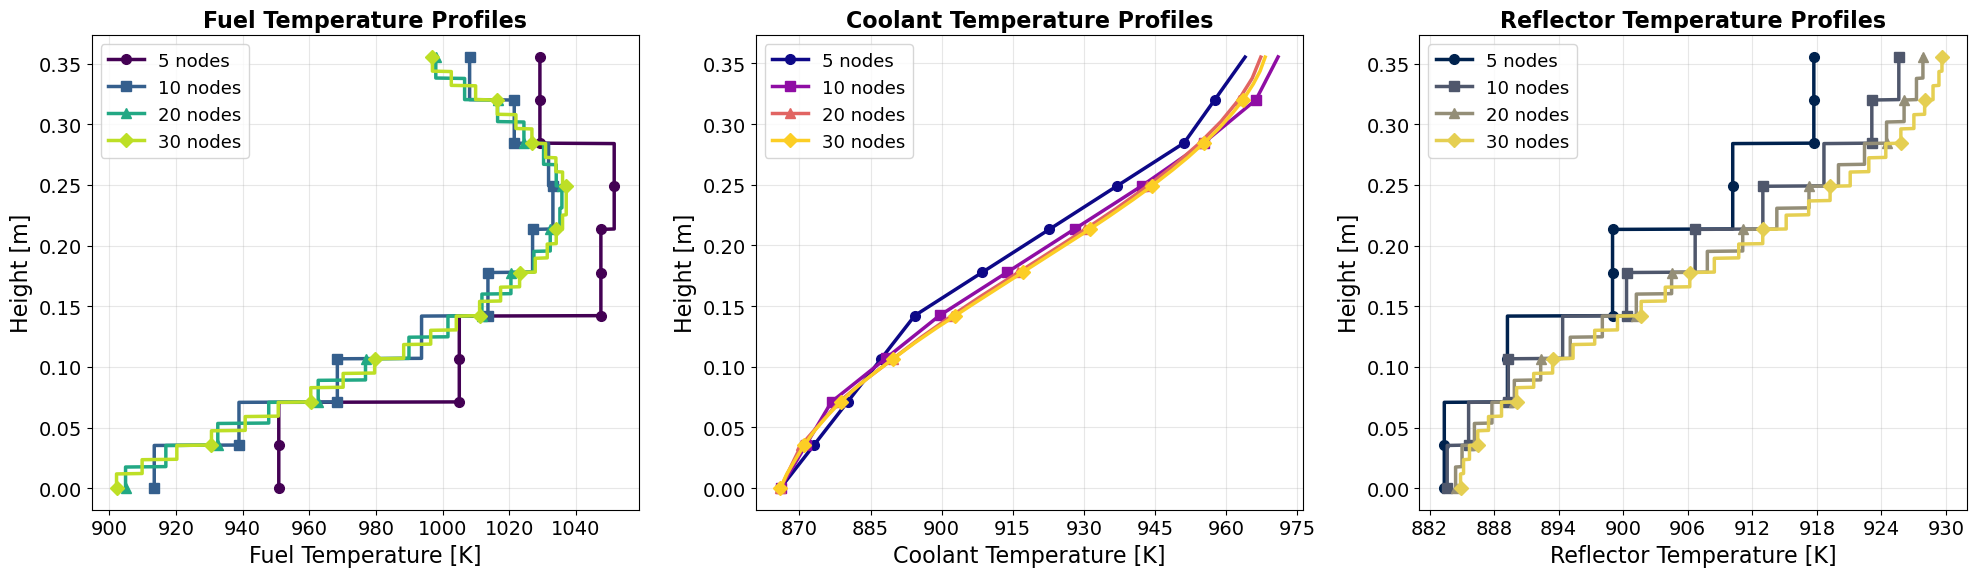

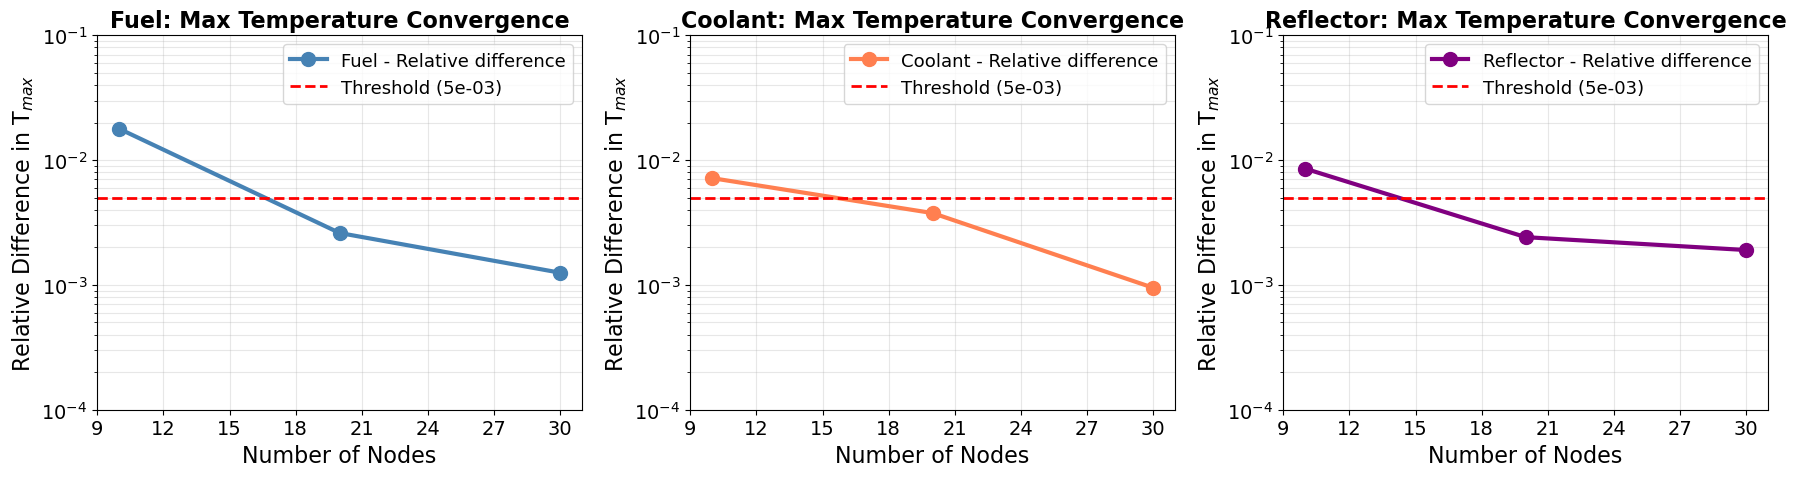

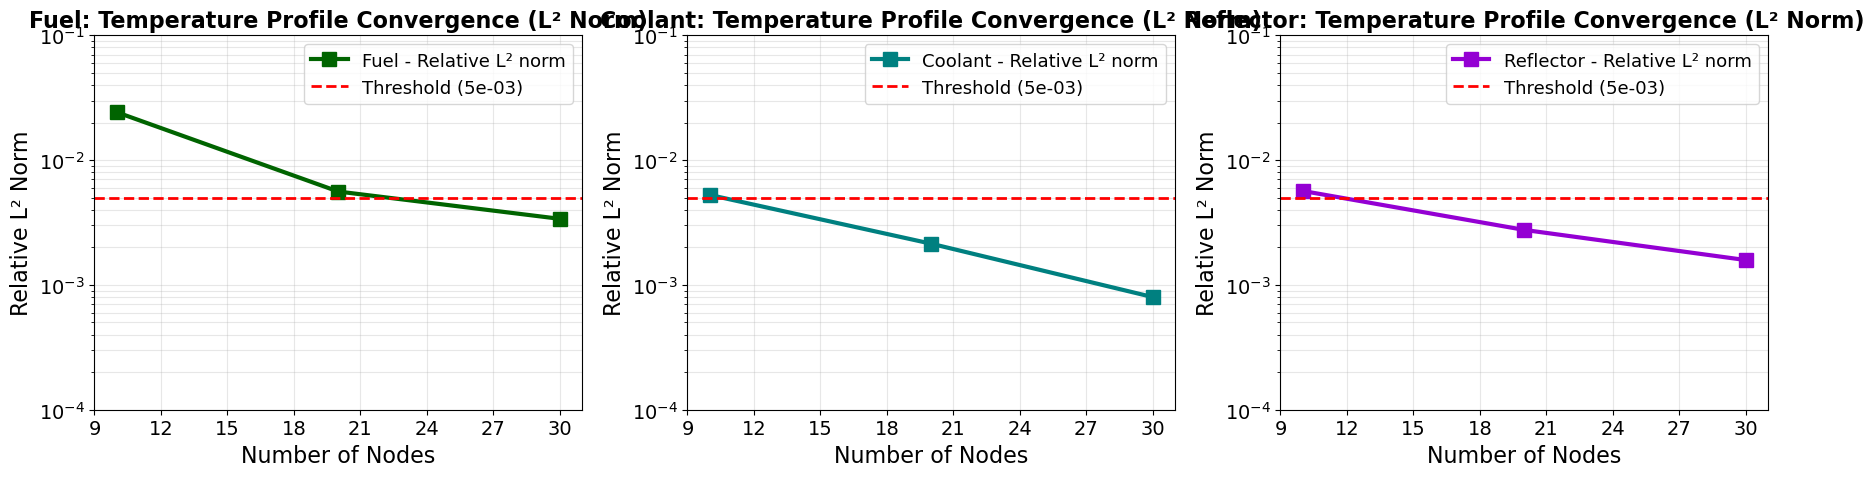

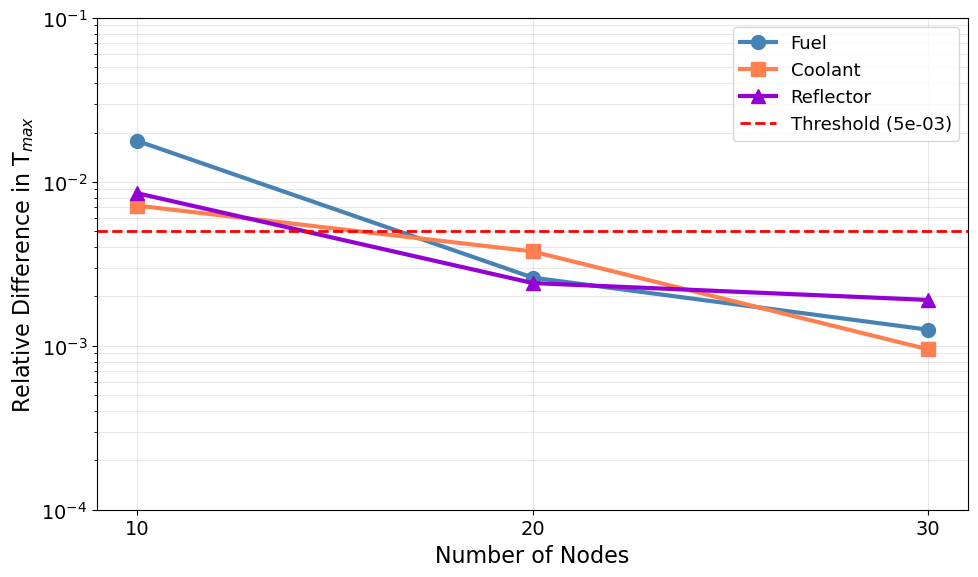

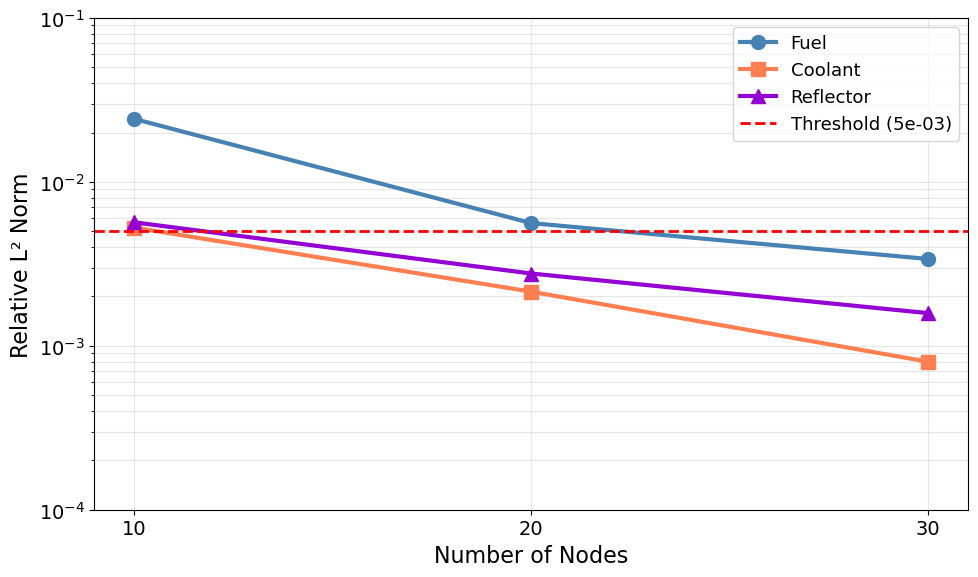


FINAL COMPARISON SUMMARY
Metric                                        Fuel            Coolant         Reflector      
----------------------------------------------------------------------
Final T_max [K]                               1037.100        968.240         929.630        


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

current_dir = Path.cwd()
base_path = current_dir / "OpenMC_Cardinal/standard_conditions"
node_counts = [5, 10, 20, 30]

fuel_data = {}
coolant_data = {}
reflector_data = {}

print("="*70)
print("READING DATA FILES")
print("="*70)

for n_nodes in node_counts:
    fuel_df      = pd.read_csv(base_path / f"{n_nodes}_node" / "fuel_temp.csv")
    coolant_df   = pd.read_csv(base_path / f"{n_nodes}_node" / "cool_temp.csv")
    reflector_df = pd.read_csv(base_path / f"{n_nodes}_node" / "inner_ref_temp.csv")

    fuel_data[n_nodes]      = {'height': fuel_df['Points:2'].values,
                                'temp':   fuel_df['temp'].values,
                                'T_max':  np.max(fuel_df['temp'].values)}
    coolant_data[n_nodes]   = {'height': coolant_df['Points:2'].values,
                                'temp':   coolant_df['T'].values,
                                'T_max':  np.max(coolant_df['T'].values)}
    reflector_data[n_nodes] = {'height': reflector_df['Points:2'].values,
                                'temp':   reflector_df['temp'].values,
                                'T_max':  np.max(reflector_df['temp'].values)}

    print(f"{n_nodes}_node: Fuel T_max = {fuel_data[n_nodes]['T_max']:.3f} K, "
          f"Coolant T_max = {coolant_data[n_nodes]['T_max']:.3f} K, "
          f"Reflector T_max = {reflector_data[n_nodes]['T_max']:.3f} K")

def compute_relative_L2_norm(z1, T1, z2, T2):
    diff_squared = (T1 - T2)**2
    T2_squared   = T2**2
    numerator    = np.sqrt(np.trapz(diff_squared, z1))
    denominator  = np.sqrt(np.trapz(T2_squared,   z2))
    return numerator / denominator

def analyze_convergence(data, name):
    max_temps    = np.array([data[n]['T_max'] for n in node_counts])
    rel_diff_max = np.abs(np.diff(max_temps)) / max_temps[1:]

    print("\n" + "="*70)
    print(f"MAX {name.upper()} TEMPERATURE CONVERGENCE")
    print("="*70)
    print(f"{'Nodes':<10} {'T_max [K]':<15} {'Rel. Diff.':<15}")
    print("-"*70)
    print(f"{node_counts[0]:<10} {max_temps[0]:<15.6f} {'N/A':<15}")
    for i in range(1, len(node_counts)):
        print(f"{node_counts[i]:<10} {max_temps[i]:<15.6f} {rel_diff_max[i-1]:<15.6e}")

    rel_L2_norms      = []
    comparison_nodes  = []
    print("\n" + "="*70)
    print(f"RELATIVE L² NORM CONVERGENCE ({name.upper()})")
    print("="*70)
    print(f"{'Comparison':<20} {'Rel. L² Norm':<15}")
    print("-"*70)
    for i in range(len(node_counts) - 1):
        n1, n2 = node_counts[i], node_counts[i+1]
        rel_L2 = compute_relative_L2_norm(data[n1]['height'], data[n1]['temp'],
                                          data[n2]['height'], data[n2]['temp'])
        rel_L2_norms.append(rel_L2)
        comparison_nodes.append(n2)
        print(f"{n1} → {n2} nodes{'':<7} {rel_L2:<15.6e}")

    rel_L2_norms     = np.array(rel_L2_norms)
    comparison_nodes = np.array(comparison_nodes)
    threshold = 5e-3
    print(f"\nConvergence threshold: {threshold:.1e}")
    for i, n in enumerate(comparison_nodes):
        status = "✓ CONVERGED" if rel_L2_norms[i] < threshold else "✗ Not converged"
        print(f"{n} nodes: {status}")

    converged_max = np.where(rel_diff_max   < threshold)[0]
    converged_L2  = np.where(rel_L2_norms   < threshold)[0]
    if len(converged_max) > 0:
        print(f"Max temperature converged at: {node_counts[converged_max[0]+1]} nodes")
    else:
        print("Max temperature NOT converged within tested range")
    if len(converged_L2) > 0:
        print(f"L² norm converged at: {comparison_nodes[converged_L2[0]]} nodes")
    else:
        print("L² norm NOT converged within tested range")

    return {'max_temps': max_temps, 'rel_diff_max': rel_diff_max,
            'rel_L2_norms': rel_L2_norms, 'comparison_nodes': comparison_nodes}

fuel_results      = analyze_convergence(fuel_data,      "Fuel")
coolant_results   = analyze_convergence(coolant_data,   "Coolant")
reflector_results = analyze_convergence(reflector_data, "Reflector")

threshold = 5e-3

# ---- Figure 1: Temperature Profiles ----------------------------------------
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
colors_fuel      = plt.cm.viridis(np.linspace(0, 0.9, len(node_counts)))
colors_coolant   = plt.cm.plasma( np.linspace(0, 0.9, len(node_counts)))
colors_reflector = plt.cm.cividis(np.linspace(0, 0.9, len(node_counts)))
markers = ['o', 's', '^', 'D', 'v']

for i, n in enumerate(node_counts):
    ax1.plot(fuel_data[n]['temp'], fuel_data[n]['height'],
             marker=markers[i], markevery=100, markersize=7, linewidth=2.5,
             label=f'{n} nodes', color=colors_fuel[i])
ax1.set_xlabel('Fuel Temperature [K]',   fontsize=16)
ax1.set_ylabel('Height [m]',              fontsize=16)
ax1.set_title('Fuel Temperature Profiles', fontsize=16, fontweight='bold')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=13)
ax1.grid(True, alpha=0.3)

for i, n in enumerate(node_counts):
    ax2.plot(coolant_data[n]['temp'], coolant_data[n]['height'],
             marker=markers[i], markevery=100, markersize=7, linewidth=2.5,
             label=f'{n} nodes', color=colors_coolant[i])
ax2.set_xlabel('Coolant Temperature [K]',   fontsize=16)
ax2.set_ylabel('Height [m]',                 fontsize=16)
ax2.set_title('Coolant Temperature Profiles', fontsize=16, fontweight='bold')
ax2.legend(fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.tick_params(labelsize=14)

for i, n in enumerate(node_counts):
    ax3.plot(reflector_data[n]['temp'], reflector_data[n]['height'],
             marker=markers[i], markevery=100, markersize=7, linewidth=2.5,
             label=f'{n} nodes', color=colors_reflector[i])
ax3.set_xlabel('Reflector Temperature [K]',   fontsize=16)
ax3.set_ylabel('Height [m]',                   fontsize=16)
ax3.set_title('Reflector Temperature Profiles', fontsize=16, fontweight='bold')
ax3.legend(fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('combined_temperature_profiles.png', dpi=300, bbox_inches='tight')
print("Saved: combined_temperature_profiles.png")

# ---- Figure 2: Max-Temperature Convergence (3 subplots) --------------------
fig2, (ax4, ax5, ax6) = plt.subplots(1, 3, figsize=(18, 5))

for ax, results, color, label_str, title_str in [
    (ax4, fuel_results,      'steelblue', 'Fuel',      'Fuel: Max Temperature Convergence'),
    (ax5, coolant_results,   'coral',     'Coolant',   'Coolant: Max Temperature Convergence'),
    (ax6, reflector_results, 'purple',    'Reflector', 'Reflector: Max Temperature Convergence'),
]:
    ax.semilogy(node_counts[1:], results['rel_diff_max'], 'o-',
                linewidth=3, markersize=10, color=color,
                label=f'{label_str} - Relative difference')
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
               label=f'Threshold ({threshold:.0e})')
    ax.set_xlabel('Number of Nodes', fontsize=16)
    ax.set_ylabel('Relative Difference in T$_{max}$', fontsize=16)
    ax.set_title(title_str, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=13)
    ax.set_ylim([1e-4, 1e-1])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('combined_max_temp_convergence.png', dpi=300, bbox_inches='tight')
print("Saved: combined_max_temp_convergence.png")

# ---- Figure 3: L² Norm Convergence (3 subplots) ----------------------------
fig3, (ax7, ax8, ax9) = plt.subplots(1, 3, figsize=(18, 5))

for ax, results, color, label_str, title_str in [
    (ax7, fuel_results,      'darkgreen',  'Fuel',      'Fuel: Temperature Profile Convergence (L² Norm)'),
    (ax8, coolant_results,   'teal',       'Coolant',   'Coolant: Temperature Profile Convergence (L² Norm)'),
    (ax9, reflector_results, 'darkviolet', 'Reflector', 'Reflector: Temperature Profile Convergence (L² Norm)'),
]:
    ax.semilogy(results['comparison_nodes'], results['rel_L2_norms'], 's-',
                linewidth=3, markersize=10, color=color,
                label=f'{label_str} - Relative L² norm')
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
               label=f'Threshold ({threshold:.0e})')
    ax.set_xlabel('Number of Nodes', fontsize=16)
    ax.set_ylabel('Relative L² Norm', fontsize=16)
    ax.set_title(title_str, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=13)
    ax.set_ylim([1e-4, 1e-1])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('combined_L2_convergence.png', dpi=300, bbox_inches='tight')
print("Saved: combined_L2_convergence.png")

# ---- Figure 4: Max-Temperature Comparison (all on one axes) ----------------
import matplotlib.ticker as tck
fig4, ax10 = plt.subplots(1, 1, figsize=(10, 6))
ax10.semilogy(node_counts[1:], fuel_results['rel_diff_max'],      'o-',
              linewidth=3, markersize=10, color='steelblue', label='Fuel')
ax10.semilogy(node_counts[1:], coolant_results['rel_diff_max'],   's-',
              linewidth=3, markersize=10, color='coral',     label='Coolant')
ax10.semilogy(node_counts[1:], reflector_results['rel_diff_max'], '^-',
              linewidth=3, markersize=10, color='darkviolet', label='Reflector')
ax10.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
             label=f'Threshold ({threshold:.0e})')
ax10.set_xlabel('Number of Nodes', fontsize=16)
ax10.set_ylabel('Relative Difference in T$_{max}$', fontsize=16)
ax10.grid(True, alpha=0.3, which='both')
ax10.legend(fontsize=13)
ax10.set_ylim([1e-4, 1e-1])
ax10.xaxis.set_major_locator(tck.MultipleLocator(base=10))
ax10.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('max_temp_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: max_temp_comparison.png")

# ---- Figure 5: L² Norm Comparison (all on one axes) ------------------------
fig5, ax11 = plt.subplots(1, 1, figsize=(10, 6))
ax11.semilogy(fuel_results['comparison_nodes'],      fuel_results['rel_L2_norms'],      'o-',
              linewidth=3, markersize=10, color='steelblue', label='Fuel')
ax11.semilogy(coolant_results['comparison_nodes'],   coolant_results['rel_L2_norms'],   's-',
              linewidth=3, markersize=10, color='coral',     label='Coolant')
ax11.semilogy(reflector_results['comparison_nodes'], reflector_results['rel_L2_norms'], '^-',
              linewidth=3, markersize=10, color='darkviolet', label='Reflector')
ax11.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
             label=f'Threshold ({threshold:.0e})')
ax11.set_xlabel('Number of Nodes', fontsize=16)
ax11.set_ylabel('Relative L² Norm', fontsize=16)
ax11.grid(True, alpha=0.3, which='both')
ax11.legend(fontsize=13)
ax11.set_ylim([1e-4, 1e-1])
ax11.xaxis.set_major_locator(tck.MultipleLocator(base=10))
ax11.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('L2_norm_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: L2_norm_comparison.png")

plt.show()

print("\n" + "="*70)
print("FINAL COMPARISON SUMMARY")
print("="*70)
print(f"{'Metric':<45} {'Fuel':<15} {'Coolant':<15} {'Reflector':<15}")
print("-"*70)
print(f"{'Final T_max [K]':<45} {fuel_results['max_temps'][-1]:<15.3f} "
      f"{coolant_results['max_temps'][-1]:<15.3f} "
      f"{reflector_results['max_temps'][-1]:<15.3f}")


## Radial Refinement for Fuel and Reflector

READING DATA FILES - RADIAL MESH REFINEMENT

Fuel Temperature Data:
----------------------------------------------------------------------
3rad_fuel: T_max = 1093.700 K, n_points = 101
5rad_fuel: T_max = 1090.800 K, n_points = 101
10rad_fuel: T_max = 1088.800 K, n_points = 101
20rad_fuel: T_max = 1088.600 K, n_points = 101

Reflector Temperature Data:
----------------------------------------------------------------------
3rad_ref: T_max = 955.460 K, n_points = 100
6rad_ref: T_max = 955.220 K, n_points = 100
12rad_ref: T_max = 954.890 K, n_points = 100

MAX FUEL TEMPERATURE CONVERGENCE (RADIAL MESH)
Radial Mesh     T_max [K]       Rel. Diff.     
----------------------------------------------------------------------
3               1093.700000     N/A            
5               1090.800000     2.658599e-03   
10              1088.800000     1.836885e-03   
20              1088.600000     1.837222e-04   

MAX REFLECTOR TEMPERATURE CONVERGENCE (RADIAL MESH)
Radial Mesh     T_max [K]     

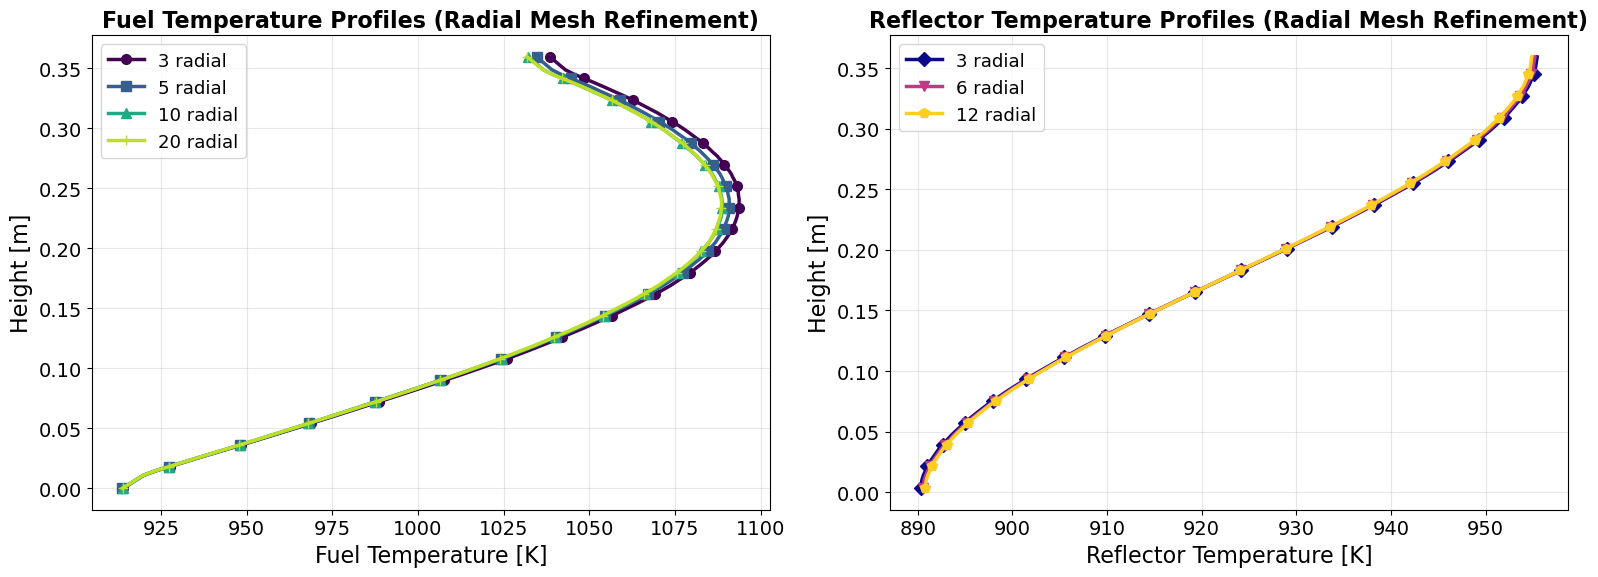

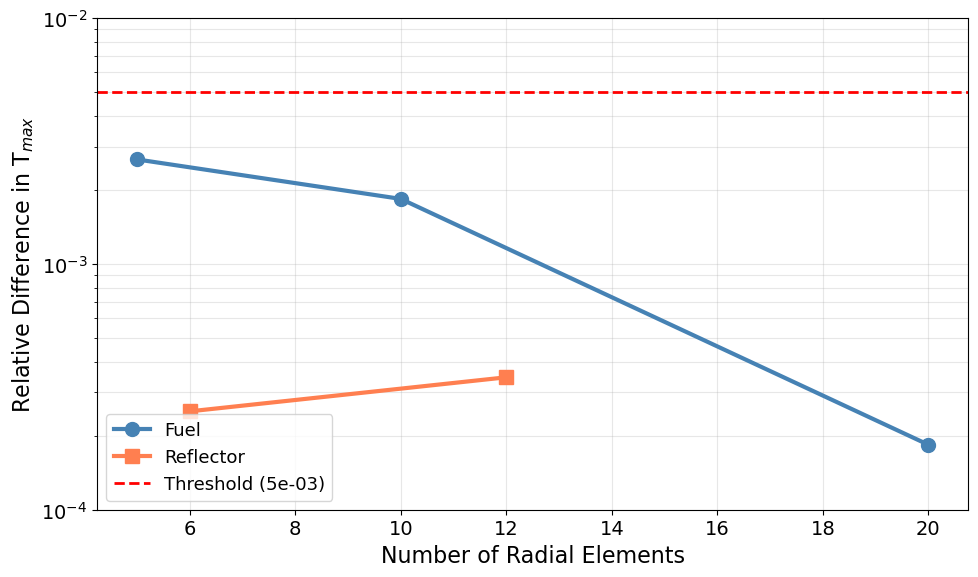

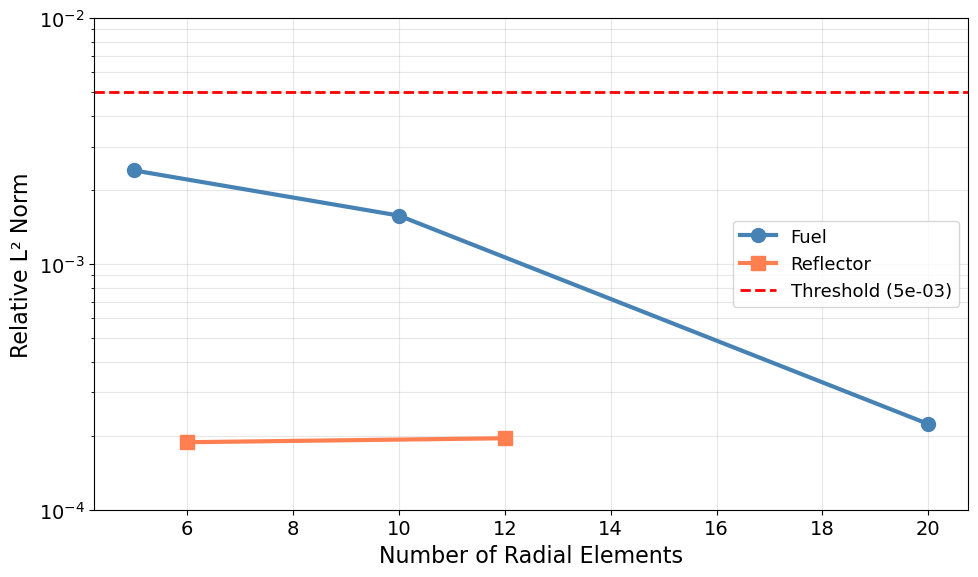

In [6]:
current_dir = Path.cwd()
base_dir = current_dir / "OpenMC_Cardinal/standard_conditions/30_node"
fuel_radial_counts = [3, 5, 10, 20]
ref_radial_counts  = [3, 6, 12]

fuel_data      = {}
reflector_data = {}

print("="*70)
print("READING DATA FILES - RADIAL MESH REFINEMENT")
print("="*70)

print("\nFuel Temperature Data:")
print("-"*70)
for n_rad in fuel_radial_counts:
    df   = pd.read_csv(base_dir / f"{n_rad}rad_fuel" / "fuel_temp.csv")
    temp = df['htm_temp'].values
    fuel_data[n_rad] = {'height': df['Points:2'].values, 'temp': temp, 'T_max': np.max(temp)}
    print(f"{n_rad}rad_fuel: T_max = {fuel_data[n_rad]['T_max']:.3f} K, n_points = {len(temp)}")

print("\nReflector Temperature Data:")
print("-"*70)
for n_rad in ref_radial_counts:
    df   = pd.read_csv(base_dir / f"{n_rad}rad_ref" / "inner_ref_temp.csv")
    temp = df['htm_temp'].values
    reflector_data[n_rad] = {'height': df['Points:2'].values, 'temp': temp, 'T_max': np.max(temp)}
    print(f"{n_rad}rad_ref: T_max = {reflector_data[n_rad]['T_max']:.3f} K, n_points = {len(temp)}")

def compute_relative_L2_norm(z1, T1, z2, T2):
    from scipy.interpolate import interp1d
    if len(z1) == len(z2):
        diff_sq = (T1 - T2)**2
        return np.sqrt(np.trapz(diff_sq, z1)) / np.sqrt(np.trapz(T2**2, z2))
    if len(z1) > len(z2):
        z_c = z1; T1i = T1
        T2i = interp1d(z2, T2, kind='cubic', fill_value='extrapolate')(z_c)
    else:
        z_c = z2; T2i = T2
        T1i = interp1d(z1, T1, kind='cubic', fill_value='extrapolate')(z_c)
    return (np.sqrt(np.trapz((T1i - T2i)**2, z_c)) /
            np.sqrt(np.trapz(T2i**2, z_c)))

def analyze_convergence_radial(data, radial_counts, name):
    max_temps    = np.array([data[n]['T_max'] for n in radial_counts])
    rel_diff_max = np.abs(np.diff(max_temps)) / max_temps[1:]
    print("\n" + "="*70)
    print(f"MAX {name.upper()} TEMPERATURE CONVERGENCE (RADIAL MESH)")
    print("="*70)
    print(f"{'Radial Mesh':<15} {'T_max [K]':<15} {'Rel. Diff.':<15}")
    print("-"*70)
    print(f"{radial_counts[0]:<15} {max_temps[0]:<15.6f} {'N/A':<15}")
    for i in range(1, len(radial_counts)):
        print(f"{radial_counts[i]:<15} {max_temps[i]:<15.6f} {rel_diff_max[i-1]:<15.6e}")

    rel_L2_norms     = []
    comparison_radial = []
    for i in range(len(radial_counts) - 1):
        n1, n2 = radial_counts[i], radial_counts[i+1]
        rel_L2 = compute_relative_L2_norm(data[n1]['height'], data[n1]['temp'],
                                          data[n2]['height'], data[n2]['temp'])
        rel_L2_norms.append(rel_L2)
        comparison_radial.append(n2)

    return {'max_temps': max_temps, 'rel_diff_max': rel_diff_max,
            'rel_L2_norms': np.array(rel_L2_norms),
            'comparison_radial': np.array(comparison_radial)}

fuel_results_rad      = analyze_convergence_radial(fuel_data,      fuel_radial_counts, "Fuel")
reflector_results_rad = analyze_convergence_radial(reflector_data, ref_radial_counts,  "Reflector")

threshold = 5e-3

# ---- Radial Figure 1: Temperature Profiles ----------------------------------
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_fuel = plt.cm.viridis(np.linspace(0, 0.9, len(fuel_radial_counts)))
colors_ref  = plt.cm.plasma( np.linspace(0, 0.9, len(ref_radial_counts)))
markers_fuel = ['o', 's', '^', '+']
markers_ref  = ['D', 'v', 'p']

for i, n_rad in enumerate(fuel_radial_counts):
    ax1.plot(fuel_data[n_rad]['temp'], fuel_data[n_rad]['height'],
             marker=markers_fuel[i], markevery=max(1, len(fuel_data[n_rad]['height'])//20),
             markersize=7, linewidth=2.5, label=f'{n_rad} radial', color=colors_fuel[i])
ax1.set_xlabel('Fuel Temperature [K]', fontsize=16)
ax1.set_ylabel('Height [m]',           fontsize=16)
ax1.set_title('Fuel Temperature Profiles (Radial Mesh Refinement)', fontsize=16, fontweight='bold')
ax1.legend(fontsize=13); ax1.grid(True, alpha=0.3); ax1.tick_params(labelsize=14)

for i, n_rad in enumerate(ref_radial_counts):
    ax2.plot(reflector_data[n_rad]['temp'], reflector_data[n_rad]['height'],
             marker=markers_ref[i], markevery=max(1, len(reflector_data[n_rad]['height'])//20),
             markersize=7, linewidth=2.5, label=f'{n_rad} radial', color=colors_ref[i])
ax2.set_xlabel('Reflector Temperature [K]', fontsize=16)
ax2.set_ylabel('Height [m]',                fontsize=16)
ax2.set_title('Reflector Temperature Profiles (Radial Mesh Refinement)', fontsize=16, fontweight='bold')
ax2.legend(fontsize=13); ax2.grid(True, alpha=0.3); ax2.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('radial_temperature_profiles.png', dpi=300, bbox_inches='tight')
print("Saved: radial_temperature_profiles.png")

# ---- Radial Figure 4: Max-Temperature Comparison ---------------------------
fig4, ax7 = plt.subplots(1, 1, figsize=(10, 6))
if len(fuel_radial_counts) > 1:
    ax7.semilogy(fuel_radial_counts[1:], fuel_results_rad['rel_diff_max'],
                 'o-', linewidth=3, markersize=10, color='steelblue', label='Fuel')
if len(ref_radial_counts) > 1:
    ax7.semilogy(ref_radial_counts[1:], reflector_results_rad['rel_diff_max'],
                 's-', linewidth=3, markersize=10, color='coral', label='Reflector')
ax7.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ({threshold:.0e})')
ax7.set_xlabel('Number of Radial Elements', fontsize=16)
ax7.set_ylabel('Relative Difference in T$_{max}$', fontsize=16)
ax7.grid(True, alpha=0.3, which='both'); ax7.legend(fontsize=13)
ax7.set_ylim([1e-4, 1e-2]); ax7.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('radial_max_temp_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: radial_max_temp_comparison.png")

# ---- Radial Figure 5: L² Norm Comparison -----------------------------------
fig5, ax8 = plt.subplots(1, 1, figsize=(10, 6))
if len(fuel_radial_counts) > 1:
    ax8.semilogy(fuel_results_rad['comparison_radial'], fuel_results_rad['rel_L2_norms'],
                 'o-', linewidth=3, markersize=10, color='steelblue', label='Fuel')
if len(ref_radial_counts) > 1:
    ax8.semilogy(reflector_results_rad['comparison_radial'], reflector_results_rad['rel_L2_norms'],
                 's-', linewidth=3, markersize=10, color='coral', label='Reflector')
ax8.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ({threshold:.0e})')
ax8.set_xlabel('Number of Radial Elements', fontsize=16)
ax8.set_ylabel('Relative L² Norm', fontsize=16)
ax8.grid(True, alpha=0.3, which='both'); ax8.legend(fontsize=13)
ax8.set_ylim([1e-4, 1e-2]); ax8.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('radial_L2_norm_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: radial_L2_norm_comparison.png")

plt.show()


# Base Operating Conditions

## BOL excess reactivity

In [7]:
current_dir = Path.cwd()
base_path   = current_dir / "Serpent/depletion"
xenon_path  = current_dir / "OpenMC_Cardinal/depletion"

serpent_res_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_res.m"
serpent_dep_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_dep.m"
serpent_burnup, serpent_rho, serpent_err = load_serpent_results(serpent_res_path, serpent_dep_path)
serpent_err = serpent_err / 3

openmc_path_dep = xenon_path / "ref_casl_results.h5"
openmc_burnup_dep_xenon, openmc_rho_dep_xenon, openmc_err_dep_xenon = load_openmc_results(openmc_path_dep)
openmc_err_dep_xenon = openmc_err_dep_xenon / 3
xenon_correction     = openmc_rho_dep_xenon[0] - openmc_rho_dep_xenon[13]
xenon_correction_err = np.sqrt(openmc_err_dep_xenon[0]**2 + openmc_err_dep_xenon[13]**2)

openmc_standalone_rho = openmc_rho_dep_xenon[13]
openmc_standalone_err = openmc_err_dep_xenon[13]

openmc_multiphysic_k   = 1.0621639
openmc_multiphysic_rho = (openmc_multiphysic_k - 1)/openmc_multiphysic_k * 1e5
openmc_multiphysic_err = (1/openmc_multiphysic_k**2) * 5.7

griffin_standalone_k   = 1.0542624306374
griffin_standalone_rho = (griffin_standalone_k - 1)/griffin_standalone_k * 1e5
griffin_standalone_err = 0

griffin_multiphysics_k   = 1.05465782
griffin_multiphysics_rho = (griffin_multiphysics_k - 1)/griffin_multiphysics_k * 1e5
griffin_multiphysics_err = 0

openmc_multiphysic_rho = openmc_multiphysic_rho - xenon_correction
openmc_multiphysic_err = np.sqrt(openmc_multiphysic_err**2 + xenon_correction_err**2)

diff_standalone_openmc    = serpent_rho[0] - openmc_standalone_rho
err_standalone_openmc     = np.sqrt(serpent_err[0]**2 + openmc_standalone_err**2)
diff_standalone_griffin   = serpent_rho[0] - griffin_standalone_rho
err_standalone_griffin    = np.sqrt(serpent_err[0]**2 + griffin_standalone_err**2)
diff_multiphysics_openmc  = serpent_rho[0] - openmc_multiphysic_rho
err_multiphysics_openmc   = np.sqrt(serpent_err[0]**2 + openmc_multiphysic_err**2)
diff_multiphysics_griffin = serpent_rho[0] - griffin_multiphysics_rho
err_multiphysics_griffin  = np.sqrt(serpent_err[0]**2 + griffin_multiphysics_err**2)

print("\nTable 6: BOL excess reactivity comparison across codes and experiment")
print("=" * 125)
print(f"{'ρ_excess [pcm]':<20} {'5600':<18} {f'{serpent_rho[0]:.0f}±{serpent_err[0]:.1f}':<18} "
      f"{f'{openmc_standalone_rho:.0f}±{openmc_standalone_err:.1f}':<18} "
      f"{f'{griffin_standalone_rho:.0f}':<18} "
      f"{f'{openmc_multiphysic_rho:.0f}±{openmc_multiphysic_err:.1f}':<18} "
      f"{f'{griffin_multiphysics_rho:.0f}':<18}")
print("=" * 125)



Table 6: BOL excess reactivity comparison across codes and experiment
ρ_excess [pcm]       5600               5056±7.8           5008±5.2           5147               5273±8.9           5183              


## Power Distribution Comparison

RADIAL POWER DISTRIBUTION ANALYSIS (BOL)
Processing 859 valid data points...
Identified 15 potential peaks
Found 15 significant flat peaks
Peak 1: heat_source=7.673e+07, std_dev=1.767e+05, position=-0.102020, peak_size=53 points
Peak 2: heat_source=7.134e+07, std_dev=1.670e+05, position=-0.087476, peak_size=53 points
Peak 3: heat_source=7.238e+07, std_dev=1.674e+05, position=-0.072473, peak_size=59 points
Peak 4: heat_source=7.614e+07, std_dev=1.715e+05, position=-0.057932, peak_size=59 points
Peak 5: heat_source=7.988e+07, std_dev=1.749e+05, position=-0.043392, peak_size=59 points
Peak 6: heat_source=8.336e+07, std_dev=1.782e+05, position=-0.028851, peak_size=58 points
Peak 7: heat_source=8.631e+07, std_dev=1.856e+05, position=-0.014541, peak_size=59 points
Peak 8: heat_source=8.761e+07, std_dev=1.841e+05, position=0.000000, peak_size=59 points
Peak 9: heat_source=8.606e+07, std_dev=1.852e+05, position=0.014541, peak_size=59 points
Peak 10: heat_source=8.339e+07, std_dev=1.737e+05, po

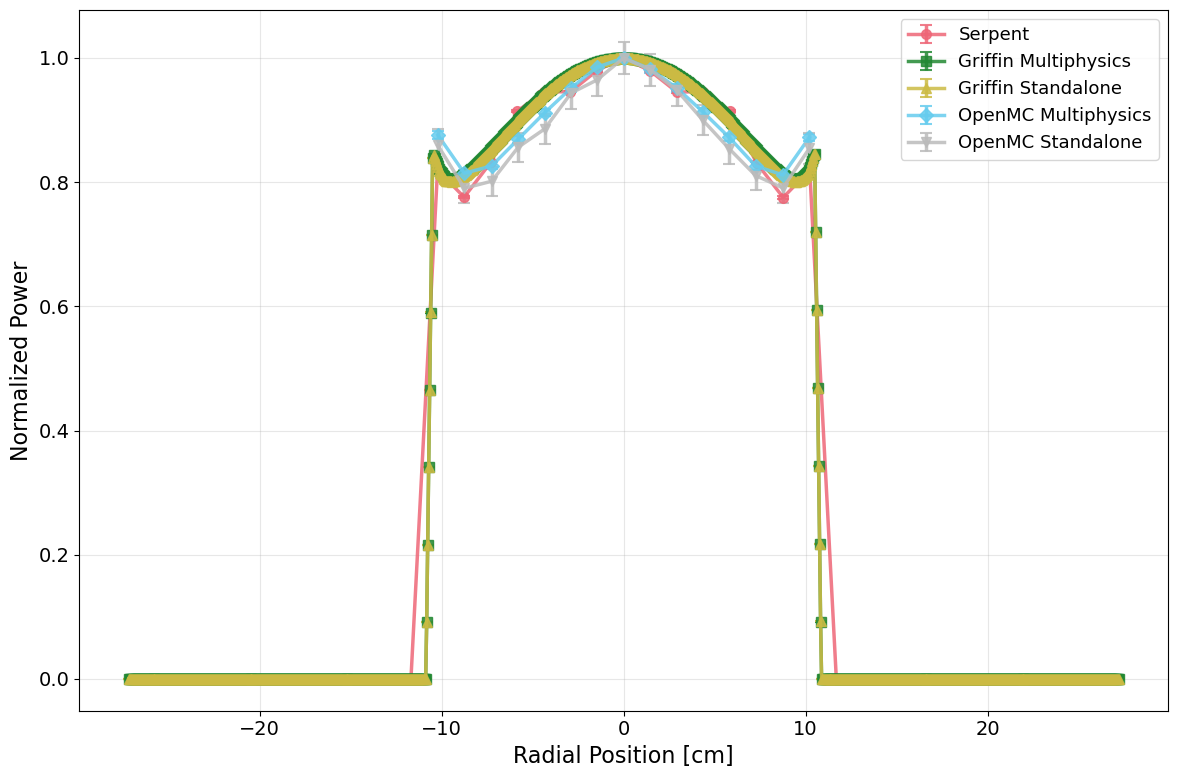


AXIAL POWER DISTRIBUTION ANALYSIS (BOL)
Serpent - Max power: 1.000000e+00 - Data points: 10
Griffin Multiphysics - Max power: 1.000000e+00 - Data points: 1001
Griffin Standalone - Max power: 1.000000e+00 - Data points: 1001
OpenMC Multiphysics - Max power: 1.000000e+00 - Data points: 12
OpenMC Standalone - Max power: 1.000000e+00 - Data points: 22


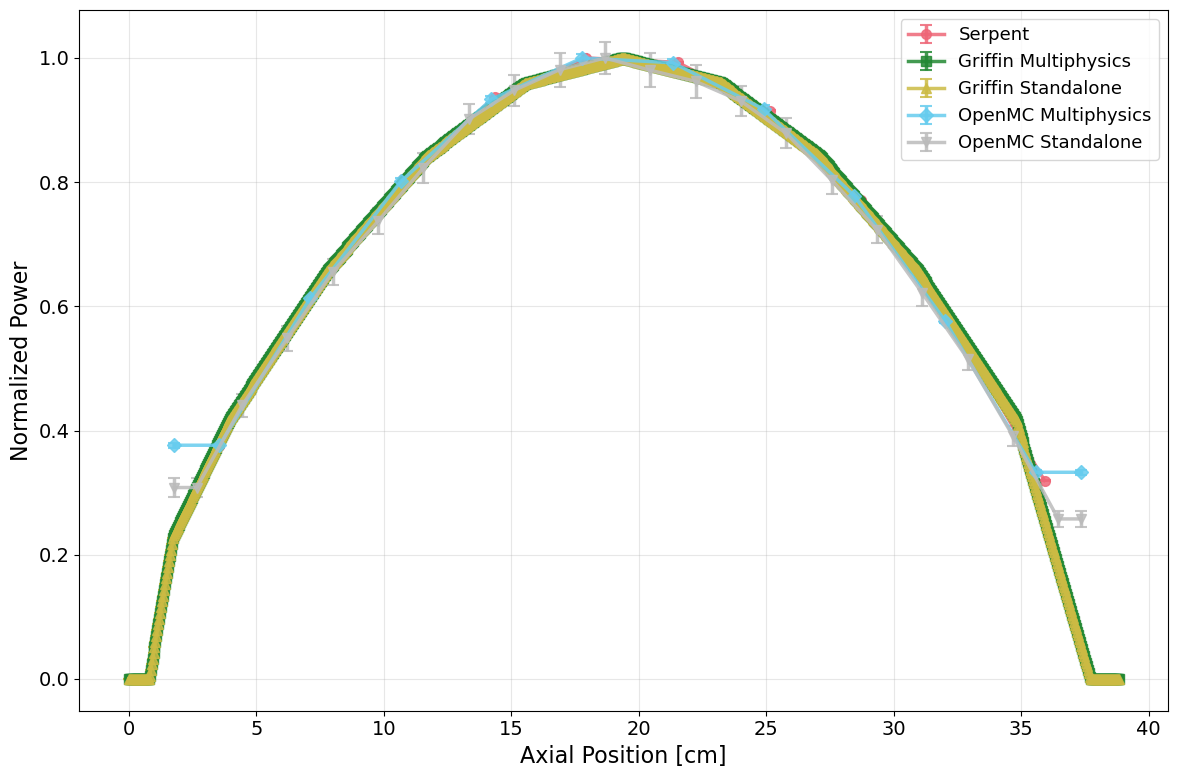

In [8]:
print("="*60)
print("RADIAL POWER DISTRIBUTION ANALYSIS (BOL)")
print("="*60)
radial_data, code_names = analyze_power_distribution_BOL('radial', normalize=True, norm_type='peak')

print("\n" + "="*60)
print("AXIAL POWER DISTRIBUTION ANALYSIS (BOL)")
print("="*60)
axial_data, _ = analyze_power_distribution_BOL('axial', normalize=True, norm_type='peak')


## Fuel, Cladding, Coolant Temperature Distribution

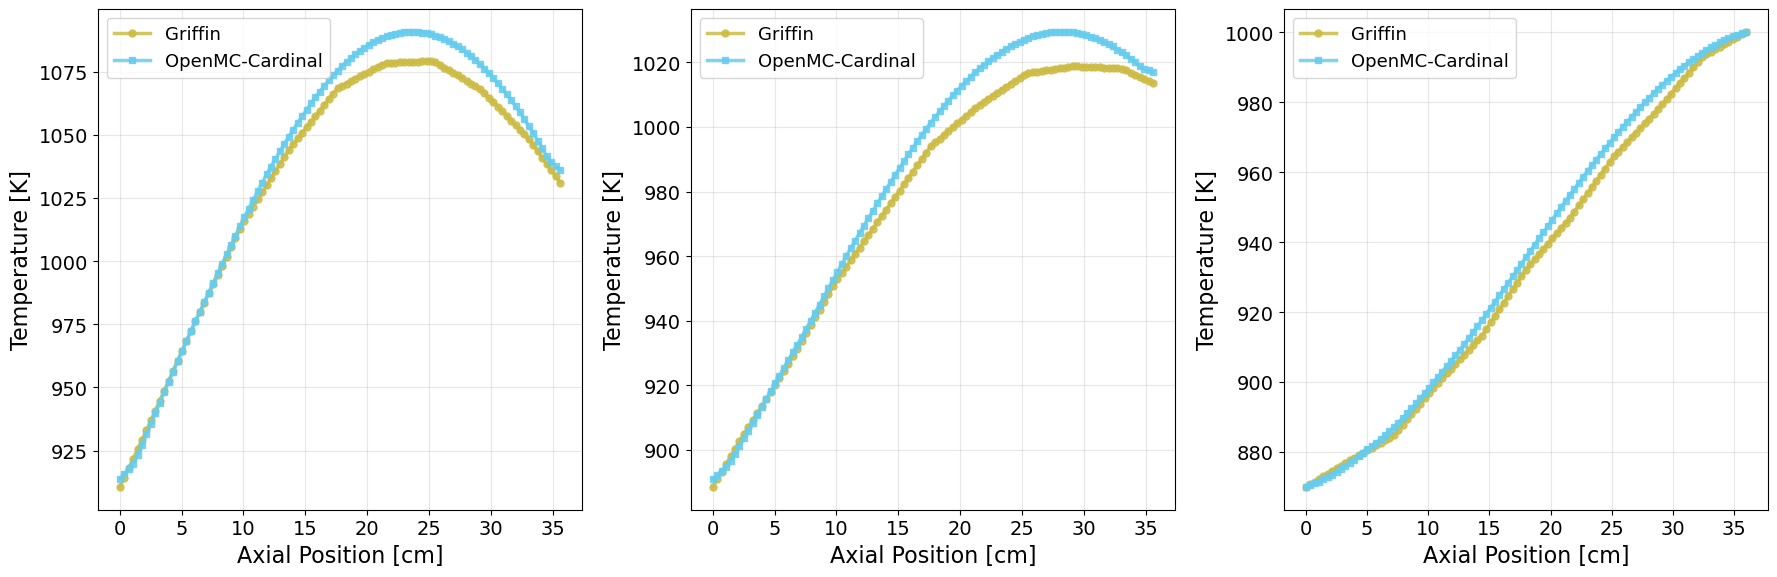

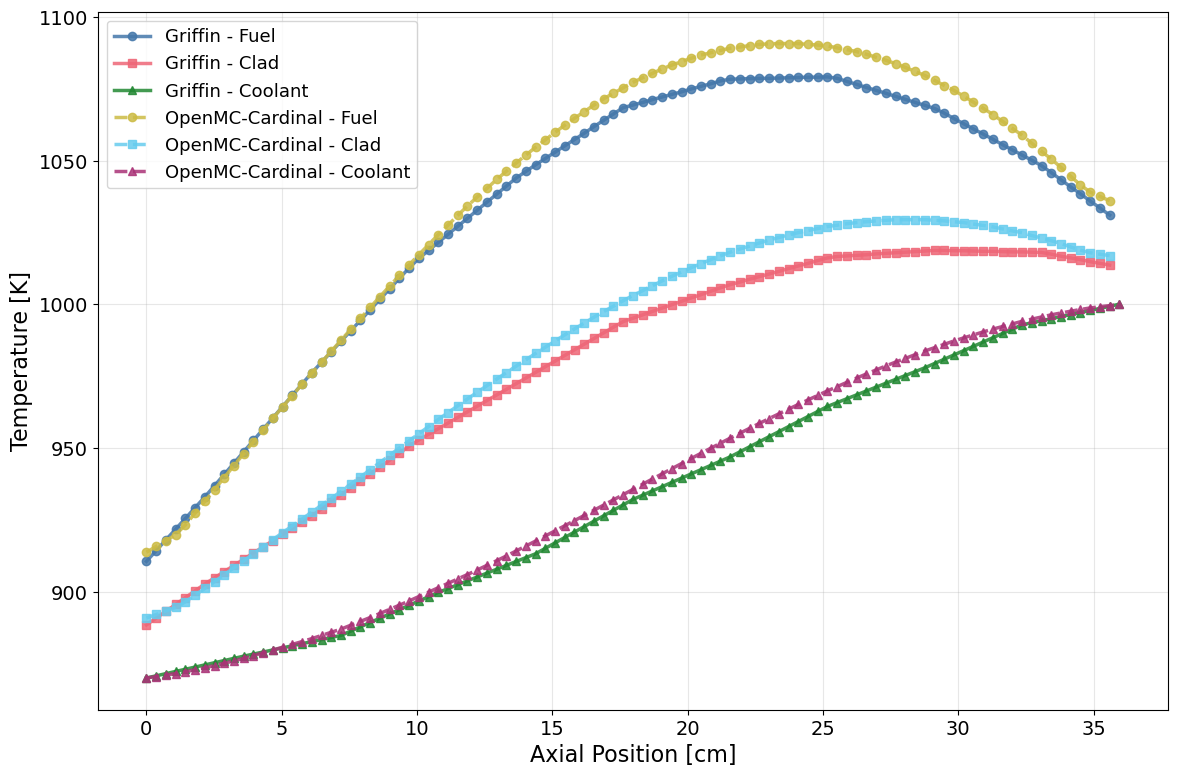


Table 7: Nominal operating characteristics
      Quantity  Experiment  OpenMC Coupling  Serpent-Griffin Coupling
 T_cool_in [K]         870            870.0                     870.0
T_cool_out [K]         980           1000.1                     975.6
        ΔT [K]         110            130.1                     105.6
   T_f_max [K]        1110           1090.8                    1079.2
T_clad_max [K]        1060           1029.5                    1018.8
       ΔP [Pa]       13100           6772.0                    6772.0


In [9]:
current_dir  = Path.cwd()
griffin_path = current_dir / "Griffin/standard_conditions/full_multiphysics"
openmc_path  = current_dir / "OpenMC_Cardinal/standard_conditions/final_sol"

files  = ['fuel_temp.csv', 'clad_temp.csv', 'cool_temp.csv']
labels = ['Fuel', 'Clad', 'Coolant']
codes  = ['Griffin', 'OpenMC-Cardinal']

plt.style.use('tableau-colorblind10')
colors = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
griffin_color = colors[3]
openmc_color  = colors[4]

# -- 3-subplot version -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (file, label) in enumerate(zip(files, labels)):
    ax = axes[i]
    for code in codes:
        if code == 'Griffin':
            temp_col = 'bison_temp'; path = griffin_path / file; color = griffin_color; marker = 'o'
        else:
            temp_col = 'htm_temp';   path = openmc_path  / file; color = openmc_color;  marker = 's'
        df    = pd.read_csv(path)
        temps = df['T'].values if file == 'cool_temp.csv' else df[temp_col].values
        coords = df['Points:2'].values * 100
        ax.plot(coords, temps, marker=marker, linestyle='-', linewidth=2.5,
                markersize=5, label=code, color=color, alpha=0.85)
    ax.set_xlabel('Axial Position [cm]', fontsize=16)
    ax.set_ylabel('Temperature [K]',     fontsize=16)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -- Single combined figure --------------------------------------------------
plt.figure(figsize=(12, 8))
line_styles = ['-', '--', '-.']
markers_list = ['o', 's', '^']

for j, code in enumerate(codes):
    for i, (file, label) in enumerate(zip(files, labels)):
        path     = griffin_path / file if code == 'Griffin' else openmc_path / file
        temp_col = 'bison_temp' if code == 'Griffin' else 'htm_temp'
        df       = pd.read_csv(path)
        temps    = df['T'].values if file == 'cool_temp.csv' else df[temp_col].values
        coords   = df['Points:2'].values * 100
        plt.plot(coords, temps, marker=markers_list[i], linestyle=line_styles[j],
                 linewidth=2.5, markersize=6, label=f'{code} - {label}',
                 color=colors[j*3 + i], alpha=0.85)

plt.xlabel('Axial Position [cm]', fontsize=16)
plt.ylabel('Temperature [K]',     fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table data extraction (unchanged logic) ------------------------------------
for file, label in zip(files, labels):
    df_griffin = pd.read_csv(griffin_path / file)
    if file == 'cool_temp.csv':
        temps_griffin = df_griffin['T'].values
        T_cool_in = temps_griffin[0]; T_cool_out = temps_griffin[-1]
    else:
        temps_griffin = df_griffin['bison_temp'].values
        if label == 'Fuel':  T_f_max    = temps_griffin.max()
        elif label == 'Clad': T_clad_max = temps_griffin.max()

for file, label in zip(files, labels):
    df_openmc = pd.read_csv(openmc_path / file)
    if file == 'cool_temp.csv':
        pass
    else:
        temps_openmc = df_openmc['htm_temp'].values
        if label == 'Fuel':  T_f_max_openmc    = temps_openmc.max()
        elif label == 'Clad': T_clad_max_openmc = temps_openmc.max()

experimental = {'T_cool_in': 870, 'T_cool_out': 980, 'ΔT': 110,
                'T_f_max': 1110, 'T_clad_max': 1060, 'ΔP': 13100}

table_data = {
    'Quantity': ['T_cool_in [K]', 'T_cool_out [K]', 'ΔT [K]', 'T_f_max [K]', 'T_clad_max [K]', 'ΔP [Pa]'],
    'Experiment':            [experimental['T_cool_in'], experimental['T_cool_out'], experimental['ΔT'],
                              experimental['T_f_max'], experimental['T_clad_max'], experimental['ΔP']],
    'OpenMC Coupling':       [T_cool_in, T_cool_out, T_cool_out - T_cool_in, T_f_max_openmc, T_clad_max_openmc, 6772],
    'Serpent-Griffin Coupling': [T_cool_in, 975.6, 105.6, T_f_max, T_clad_max, 6772],
}
df_table = pd.DataFrame(table_data)
print("\nTable 7: Nominal operating characteristics")
print(df_table.to_string(index=False))


# Effect of Hydrogen Content on Reactivity

## Uniform Hydrogen Loss

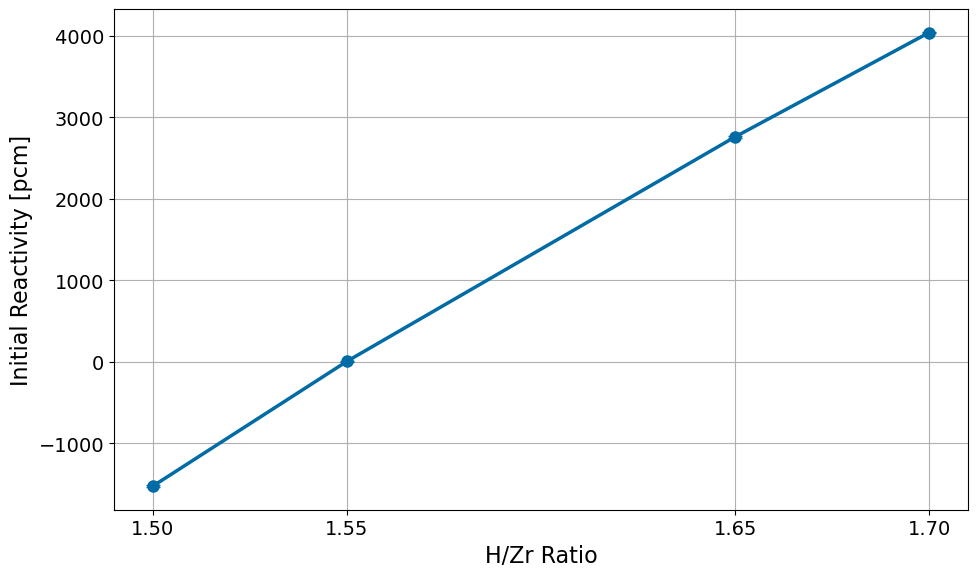

In [10]:
current_dir = Path.cwd()
ratios      = ["1.5", "1.55", "1.65", "1.7"]
ratio_values = []; rho_values = []; rho_err_values = []

for ratio in ratios:
    res_path = (current_dir / f"Serpent/depletion/hydrogen_dissociation/H_Zr_{ratio}/s82d_ac_c3_gcu_ringres.main_res.m").resolve()
    dep = st.read(res_path)
    anakeff = dep['impKeff'][0]; k_err = dep['impKeff'][1]
    rho     = (1 - 1/anakeff) * 1e5
    rho_err = (k_err / anakeff**2) * 1e5
    ratio_values.append(float(ratio)); rho_values.append(rho); rho_err_values.append(rho_err)

plt.figure(figsize=(10, 6))
plt.errorbar(ratio_values, rho_values, yerr=rho_err_values,
             fmt='o-', capsize=5, linewidth=2.5, markersize=8)
plt.xlabel('H/Zr Ratio',              fontsize=16)
plt.ylabel('Initial Reactivity [pcm]', fontsize=16)
plt.xticks(ratio_values, fontsize=14); plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


## Simple Hydrogen Migration

In [11]:
current_dir = Path.cwd()
res_name = 's82d_ac_c3_gcu_ringres.main_res.m'
diffusion_res = st.read((current_dir/'Serpent/reactivity_worths/hydrogen_diffusion/heterogenous_fuel'/res_name).resolve())
standard_res  = st.read((current_dir/'Serpent/standard_reference_sol'/res_name).resolve())

diff_k     = diffusion_res['anaKeff'][0]; diff_k_unc  = diffusion_res['anaKeff'][1]
stand_k    = standard_res['anaKeff'][0];  stand_k_unc = standard_res['anaKeff'][1]
diff_rho   = (diff_k  - 1)/diff_k;       diff_rho_unc  = np.sqrt((1/diff_k**2)**2  * diff_k_unc**2)
stand_rho  = (stand_k - 1)/stand_k;      stand_rho_unc = np.sqrt((1/stand_k**2)**2 * stand_k_unc**2)
reactivity_worth     = (diff_rho  - stand_rho)  * 1e5
reactivity_worth_unc = np.sqrt(diff_rho_unc**2 + stand_rho_unc**2) * 1e5
print(f"Reactivity Worth (Diffusion - Standard) = {reactivity_worth:.2f} ± {reactivity_worth_unc:.2f} pcm")


Reactivity Worth (Diffusion - Standard) = 138.90 ± 15.31 pcm


## Hydrogen Migration into He Gap

In [12]:
current_dir = Path.cwd()
res_name = 's82d_ac_c3_gcu_ringres.main_res.m'
diffusion_res = st.read((current_dir/'Serpent/reactivity_worths/hydrogen_diffusion/hydrogen_in_gap'/res_name).resolve())
standard_res  = st.read((current_dir/'Serpent/standard_reference_sol'/res_name).resolve())

diff_k    = diffusion_res['anaKeff'][0]; diff_k_unc  = diffusion_res['anaKeff'][1]
stand_k   = standard_res['anaKeff'][0];  stand_k_unc = standard_res['anaKeff'][1]
diff_rho  = (diff_k  - 1)/diff_k;  diff_rho_unc  = np.sqrt((1/diff_k**2)**2  * diff_k_unc**2)
stand_rho = (stand_k - 1)/stand_k; stand_rho_unc = np.sqrt((1/stand_k**2)**2 * stand_k_unc**2)
reactivity_worth     = (diff_rho  - stand_rho)  * 1e5
reactivity_worth_unc = np.sqrt(diff_rho_unc**2 + stand_rho_unc**2) * 1e5
print(f"Reactivity Worth (Diffusion - Standard) = {reactivity_worth:.2f} ± {reactivity_worth_unc:.2f} pcm")


Reactivity Worth (Diffusion - Standard) = -84.08 ± 15.34 pcm


## Removal of bound thermal scattering for hydrogen

In [13]:
current_dir = Path.cwd()
res_name = 's82d_ac_c3_gcu_ringres.main_res.m'
diffusion_res = st.read((current_dir/'Serpent/reactivity_worths/hydrogen_diffusion/no_sab'/res_name).resolve())
standard_res  = st.read((current_dir/'Serpent/standard_reference_sol'/res_name).resolve())

diff_k    = diffusion_res['anaKeff'][0]; diff_k_unc  = diffusion_res['anaKeff'][1]
stand_k   = standard_res['anaKeff'][0];  stand_k_unc = standard_res['anaKeff'][1]
diff_rho  = (diff_k  - 1)/diff_k;  diff_rho_unc  = np.sqrt((1/diff_k**2)**2  * diff_k_unc**2)
stand_rho = (stand_k - 1)/stand_k; stand_rho_unc = np.sqrt((1/stand_k**2)**2 * stand_k_unc**2)
reactivity_worth     = (diff_rho  - stand_rho)  * 1e5
reactivity_worth_unc = np.sqrt(diff_rho_unc**2 + stand_rho_unc**2) * 1e5
print(f"Reactivity Worth (Diffusion - Standard) = {reactivity_worth:.2f} ± {reactivity_worth_unc:.2f} pcm")


Reactivity Worth (Diffusion - Standard) = 91.14 ± 15.96 pcm


## Hydrogen Diffusion Modeling with SWIFT

Reading materials from /home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/Wet_Experiment_Models/Griffin/depletion/XS_Generation/burned_mat
Got 35 burnups.
Got 4222 materials.


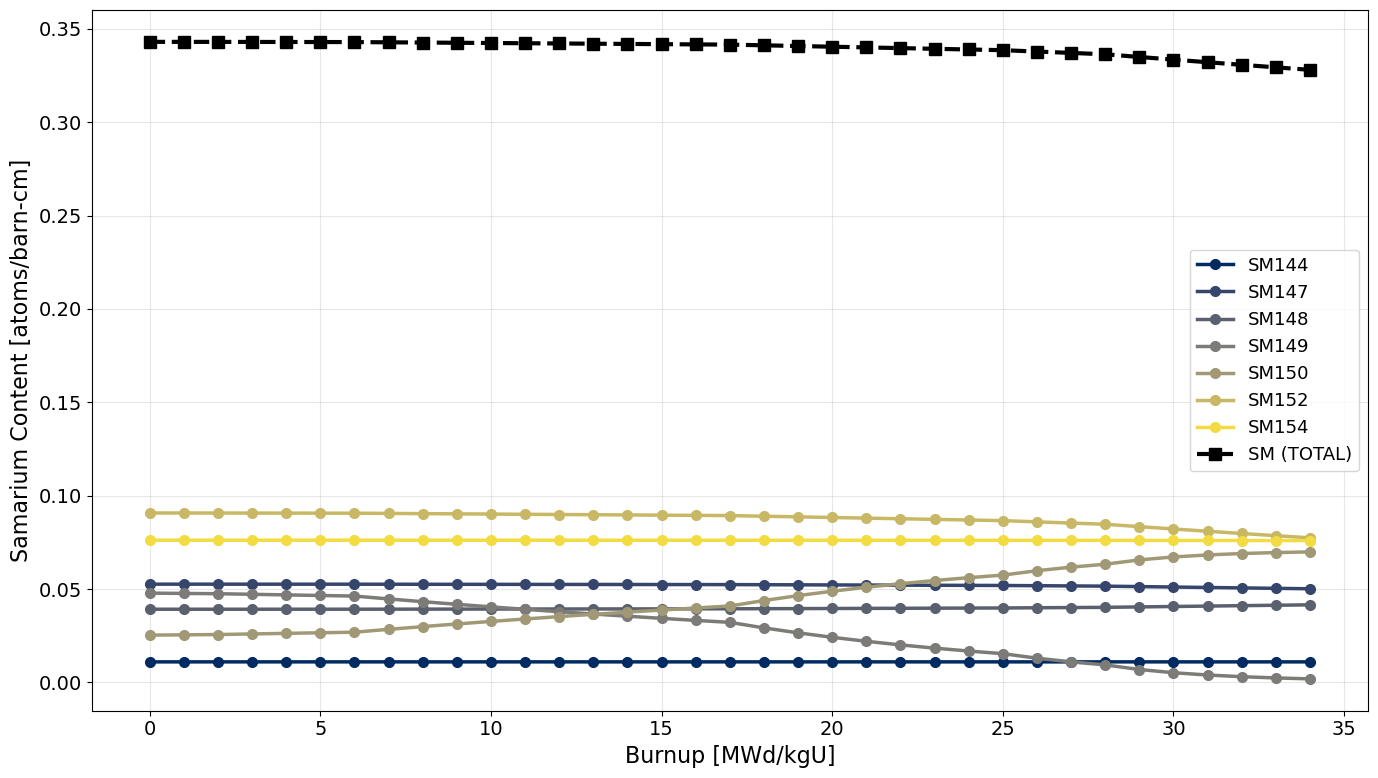

In [30]:
from krakentools import serpent

depletion_file = '/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/Wet_Experiment_Models/Griffin/depletion/XS_Generation/burned_mat'
file = serpent.read_restart_file(depletion_file)

sm_isotopes = {621440: 'sm144_total', 621470: 'sm147_total', 621480: 'sm148_total',
               621490: 'sm149_total', 621500: 'sm150_total', 621520: 'sm152_total',
               621540: 'sm154_total'}
sm_data = []
for burnup in range(len(file)):
    row = {'timestep': burnup}
    for zaid, col_name in sm_isotopes.items():
        row[col_name] = 0.0
    for material in range(len(file[burnup])):
        name = file[burnup][material].name
        zais = file[burnup][material].zais
        if 'ceramicz' in name:
            for zaid, col_name in sm_isotopes.items():
                if zaid in zais:
                    sm_index = list(zais).index(zaid)
                    row[col_name] += file[burnup][material].adenses[sm_index]
    row['sm_total'] = sum(row[col_name] for col_name in sm_isotopes.values())
    sm_data.append(row)

df = pd.DataFrame(sm_data)
df.to_csv('samarium_totals.csv', index=False)

# Colorblind-friendly gradient sampled from 'cividis' (perceptually uniform)
isotope_cols = [c for c in df.columns if c not in ('timestep', 'sm_total')]
colors_sm = plt.cm.cividis(np.linspace(0.05, 0.95, len(isotope_cols)))

plt.figure(figsize=(14, 8))
for idx, col in enumerate(isotope_cols):
    plt.plot(df['timestep'], df[col],
             label=col.replace('_total', '').upper(),
             marker='o', linewidth=2.5, markersize=7,
             color=colors_sm[idx])

# Total line kept black/dashed to stand out from the gradient
plt.plot(df['timestep'], df['sm_total'],
         label='SM (TOTAL)',
         marker='s', linewidth=3, markersize=9,
         linestyle='--', color='black')

plt.xlabel('Burnup [MWd/kgU]',               fontsize=16)
plt.ylabel('Samarium Content [atoms/barn-cm]', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=13, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

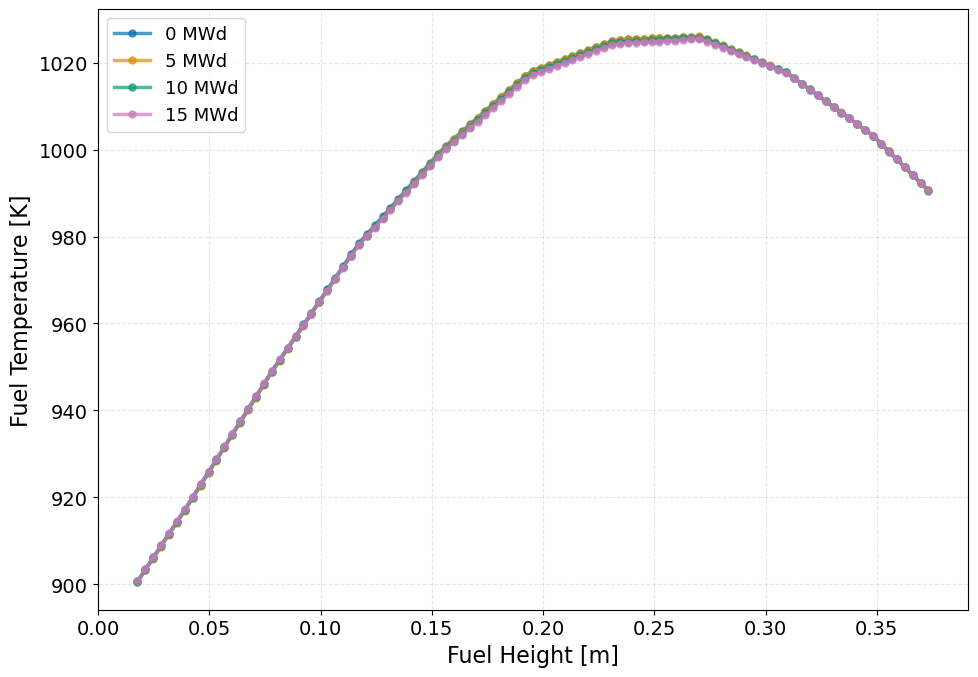

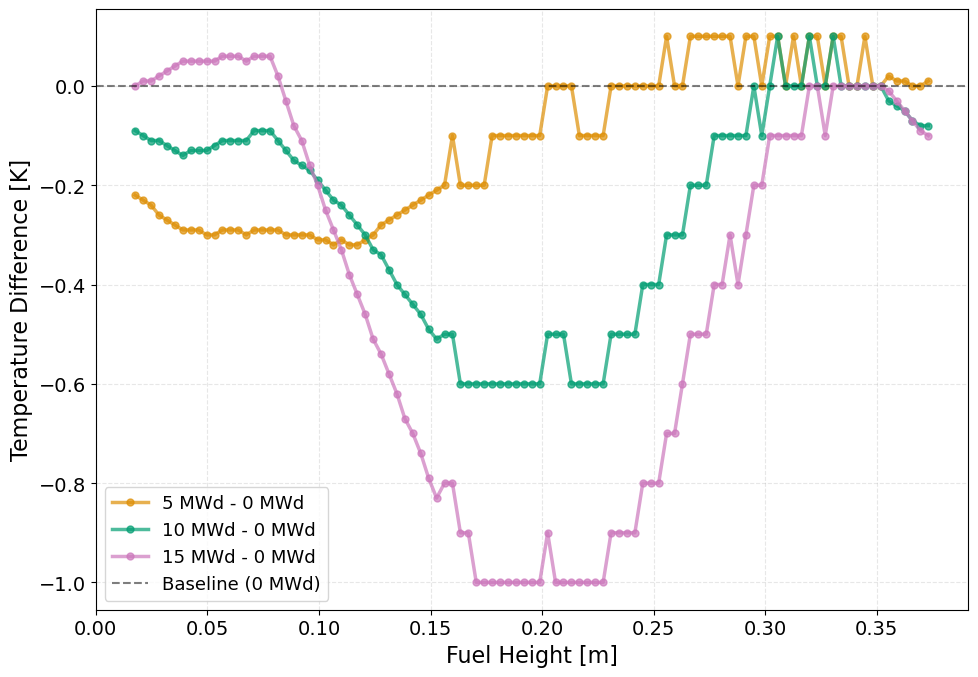

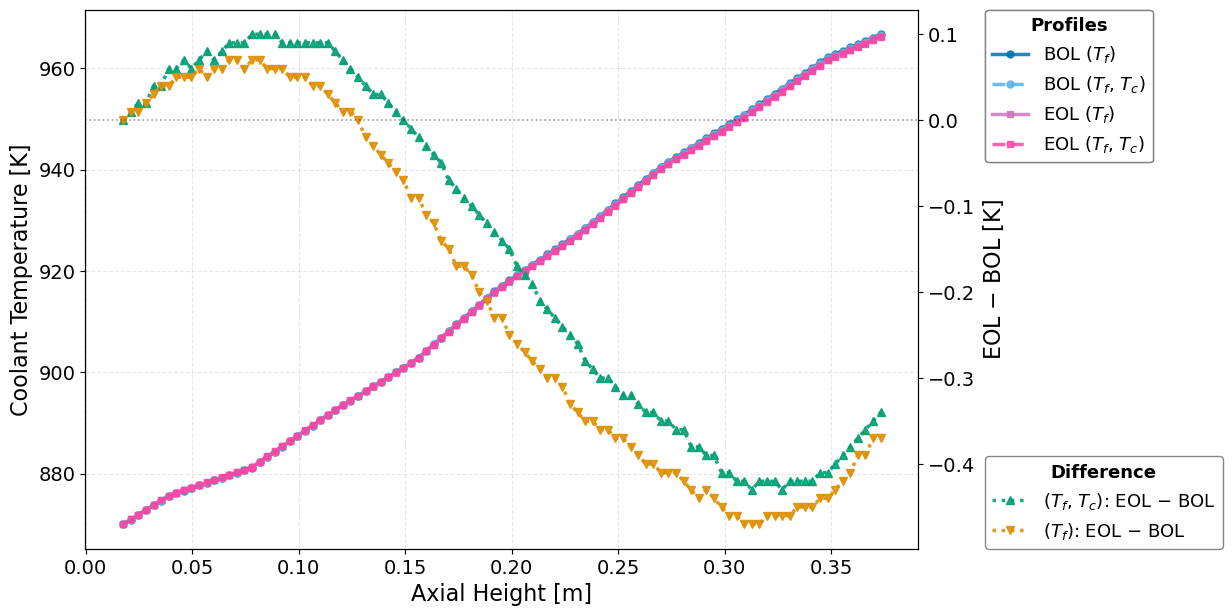

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base_path  = "/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/Wet_Experiment_Models/Griffin/depletion/full_multiphysics"
mwd_values = [0, 5, 10, 15]
colors_mwd = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC']

# ── Figure 1: Fuel temperature profiles ──────────────────────────────────────
plt.figure(figsize=(10, 7))
for idx, mwd in enumerate(mwd_values):
    filepath = os.path.join(base_path, f"fuel_center_{mwd}_MWd.csv")
    try:
        df = pd.read_csv(filepath)
        plt.plot(df['Points:2'], df['griffin_Tfuel'], marker='o', linewidth=2.5,
                 markersize=5, alpha=0.7, color=colors_mwd[idx], label=f'{mwd} MWd')
    except Exception as e:
        print(f"Error processing fuel_center_{mwd}_MWd.csv: {e}")

plt.xlabel('Fuel Height [m]',      fontsize=16)
plt.ylabel('Fuel Temperature [K]', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(loc='best', fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ── Figure 2: Fuel temperature difference relative to 0 MWd baseline ─────────
colors_diff = ['#DE8F05', '#029E73', '#CC78BC']
try:
    df_baseline   = pd.read_csv(os.path.join(base_path, "fuel_center_0_MWd.csv"))
    baseline_temp = df_baseline['griffin_Tfuel']
    plt.figure(figsize=(10, 7))
    for idx, mwd in enumerate([5, 10, 15]):
        filepath = os.path.join(base_path, f"fuel_center_{mwd}_MWd.csv")
        try:
            df = pd.read_csv(filepath)
            plt.plot(df['Points:2'], df['griffin_Tfuel'] - baseline_temp,
                     marker='o', linewidth=2.5, markersize=5, alpha=0.7,
                     color=colors_diff[idx], label=f'{mwd} MWd - 0 MWd')
        except Exception as e:
            print(f"Error: {e}")
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5,
                label='Baseline (0 MWd)')
    plt.xlabel('Fuel Height [m]',            fontsize=16)
    plt.ylabel('Temperature Difference [K]',  fontsize=16)
    plt.xticks(fontsize=14); plt.yticks(fontsize=14)
    plt.legend(loc='best', fontsize=13)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error loading baseline: {e}")

# ── Figure 3: Coolant TF vs TFC profiles + (TFC − TF) difference ─────────────
try:
    df_bol_tf  = pd.read_csv(os.path.join(base_path, "cool_BOL_TF.csv"))
    df_eol_tf  = pd.read_csv(os.path.join(base_path, "cool_EOL_TF.csv"))
    df_bol_tfc = pd.read_csv(os.path.join(base_path, "cool_BOL_TFC.csv"))
    df_eol_tfc = pd.read_csv(os.path.join(base_path, "cool_EOL_TFC.csv"))

    for df in [df_bol_tf, df_eol_tf, df_bol_tfc, df_eol_tfc]:
        df.sort_values('Points:2', inplace=True)
        df.reset_index(drop=True, inplace=True)

    height = df_bol_tf['Points:2'].values

    T_bol_tf  = df_bol_tf['griffin_Tcool'].values
    T_eol_tf  = df_eol_tf['griffin_Tcool'].values
    T_bol_tfc = df_bol_tfc['griffin_Tcool'].values
    T_eol_tfc = df_eol_tfc['griffin_Tcool'].values

    # EOL − BOL for each coupling type
    dT_tf  = T_eol_tf  - T_bol_tf    # (Tf):      EOL − BOL
    dT_tfc = T_eol_tfc - T_bol_tfc   # (Tf, Tc):  EOL − BOL

    color_bol     = '#0173B2'
    color_bol_tfc = '#56B4E9'
    color_eol     = '#CC78BC'
    color_eol_tfc = '#F748A5'
    color_dtf     = '#DE8F05'   # amber  — (Tf)     EOL−BOL
    color_dtfc    = '#029E73'   # green  — (Tf, Tc) EOL−BOL

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Primary axis — absolute coolant temperatures
    l1, = ax1.plot(height, T_bol_tf,  marker='o', linewidth=2.5, markersize=5,
                   alpha=0.85, color=color_bol,     label=r'BOL ($T_f$)')
    l2, = ax1.plot(height, T_bol_tfc, marker='o', linewidth=2.5, markersize=5,
                   alpha=0.85, color=color_bol_tfc, label=r'BOL ($T_f$, $T_c$)',
                   linestyle='--')
    l3, = ax1.plot(height, T_eol_tf,  marker='s', linewidth=2.5, markersize=5,
                   alpha=0.85, color=color_eol,     label=r'EOL ($T_f$)')
    l4, = ax1.plot(height, T_eol_tfc, marker='s', linewidth=2.5, markersize=5,
                   alpha=0.85, color=color_eol_tfc, label=r'EOL ($T_f$, $T_c$)',
                   linestyle='--')

    ax1.set_xlabel('Axial Height [m]',       fontsize=16)
    ax1.set_ylabel('Coolant Temperature [K]', fontsize=16)
    ax1.tick_params(labelsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Secondary axis — EOL − BOL for each coupling type
    ax2 = ax1.twinx()
    l5, = ax2.plot(height, dT_tfc, marker='^', linewidth=2.5, markersize=6,
                   linestyle=':', alpha=0.9, color=color_dtfc,
                   label=r'($T_f$, $T_c$): EOL $-$ BOL')
    l6, = ax2.plot(height, dT_tf,  marker='v', linewidth=2.5, markersize=6,
                   linestyle=':', alpha=0.9, color=color_dtf,
                   label=r'($T_f$): EOL $-$ BOL')
    ax2.axhline(y=0, color='black', linestyle=':', linewidth=1.2, alpha=0.4)
    ax2.set_ylabel('EOL $-$ BOL [K]', fontsize=16)
    ax2.tick_params(axis='y', labelsize=14)

    # Both legends stacked outside to the right
    legend1 = ax1.legend(
        [l1, l2, l3, l4], [l.get_label() for l in [l1, l2, l3, l4]],
        loc='upper left', bbox_to_anchor=(1.08, 1.0),
        fontsize=13, framealpha=0.95, edgecolor='gray',
        title='Profiles', title_fontsize=13, borderaxespad=0,
    )
    legend2 = ax2.legend(
        [l5, l6], [l.get_label() for l in [l5, l6]],
        loc='lower left', bbox_to_anchor=(1.08, 0.0),
        fontsize=13, framealpha=0.95, edgecolor='gray',
        title='Difference', title_fontsize=13, borderaxespad=0,
    )
    legend1.get_title().set_fontweight('bold')
    legend2.get_title().set_fontweight('bold')
    ax1.add_artist(legend1)

    fig.subplots_adjust(right=0.72)
    plt.show()

except Exception as e:
    print(f"Error loading coolant CSV files: {e}")

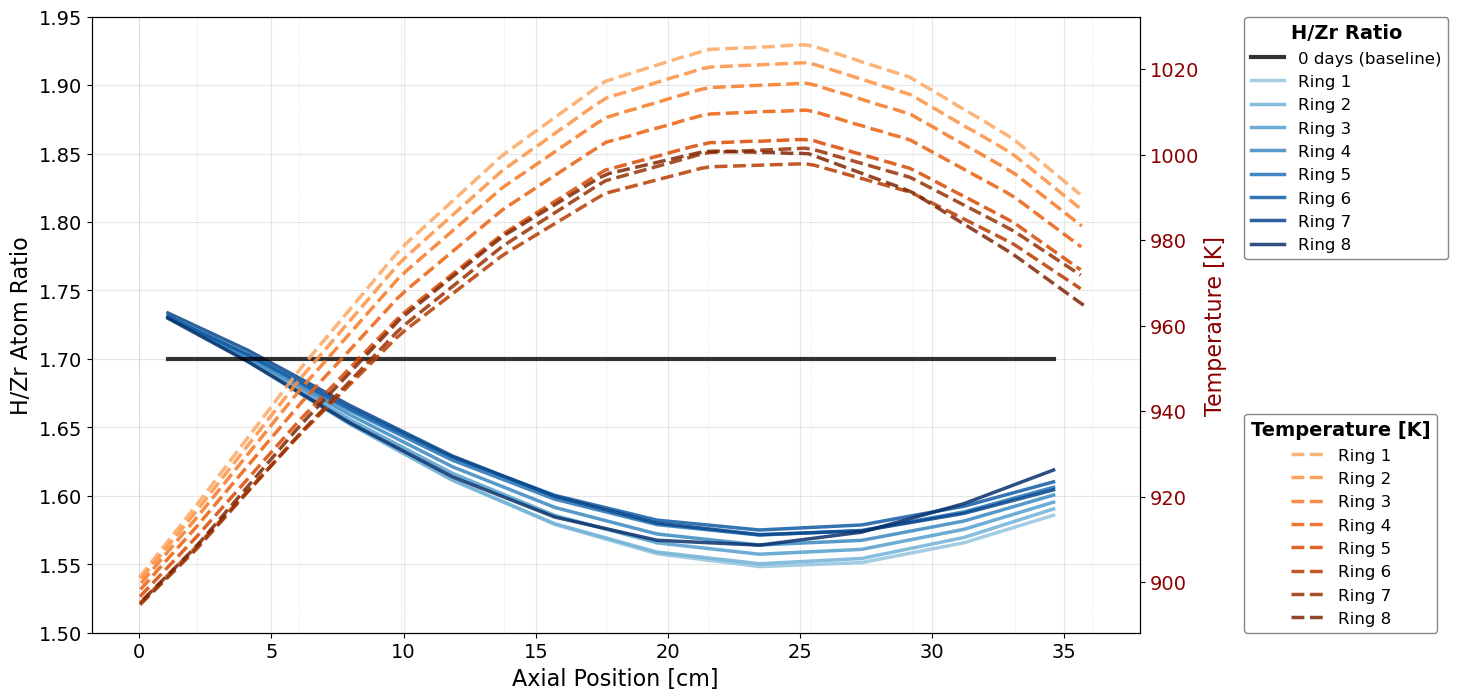

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def get_layer_boundaries():
    acl_start = 0.0; acl_end = 2.1717
    acm_start = 2.1717; acm_end = 33.13785
    acu_start = 33.13785; acu_end = 36.04614
    acm_relative_boundaries = [0.0, 3.8707690695176256, 7.741538139035251, 11.612307208552878,
                                15.483076278070502, 19.353845347588127, 23.224614417105755,
                                27.09538348662338, 30.966152556141005]
    acm_height = acm_end - acm_start
    layer_boundaries = [(acl_start/100.0, acl_end/100.0)]
    for i in range(len(acm_relative_boundaries) - 1):
        z_s = acm_start + (acm_relative_boundaries[i]  /acm_relative_boundaries[-1]) * acm_height
        z_e = acm_start + (acm_relative_boundaries[i+1]/acm_relative_boundaries[-1]) * acm_height
        layer_boundaries.append((z_s/100.0, z_e/100.0))
    layer_boundaries.append((acu_start/100.0, acu_end/100.0))
    return layer_boundaries

def load_layer_averages(csv_file):
    df = pd.read_csv(csv_file, index_col=0)
    depletion_times = [float(col) for col in df.columns]
    layer_names = list(df.index)
    layer_averages = {}
    for dep_time in depletion_times:
        layer_averages[dep_time] = {ln: df.loc[ln, str(dep_time)] for ln in layer_names}
    return layer_averages, depletion_times, layer_names

def load_temperature_data(csv_file):
    df = pd.read_csv(csv_file)
    return df['Points:2'].values, df['bison_Tfuel'].values

def load_all_rings(base_data_dir, temp_data_dir):
    all_rings_data = {}
    for ring_num in range(1, 9):
        csv_file  = f"{base_data_dir}/rings_data/ring_{ring_num}/ring{ring_num}_layer_averages.csv"
        temp_file = f"{temp_data_dir}/ring{ring_num}_center.csv"
        if os.path.exists(csv_file):
            try:
                la, dt, ln = load_layer_averages(csv_file)
                heights, temps = (load_temperature_data(temp_file)
                                  if os.path.exists(temp_file) else (None, None))
                all_rings_data[ring_num] = (la, dt, ln, heights, temps)
            except Exception as e:
                print(f"  Error loading Ring {ring_num}: {e}")
    return all_rings_data

def plot_all_rings_comparison(all_rings_data, layer_boundaries):
    fig, ax1 = plt.subplots(figsize=(16, 8))  # slightly wider to accommodate outside legends
    layer_centers = [np.mean(bounds) * 100 for bounds in layer_boundaries]

    ax1.plot(layer_centers, [1.7] * len(layer_centers), '-',
             label='0 days (baseline)', color='black', linewidth=3, alpha=0.8, zorder=10)

    # Colorblind-friendly gradients: cividis for H/Zr, plasma for temperature
    colors_h    = plt.cm.Blues( np.linspace(0.4, 1.0, 8))
    colors_temp = plt.cm.Oranges(np.linspace(0.4, 1.0, 8))

    for ring_num in sorted(all_rings_data.keys()):
        la, dt, ln, heights, temps = all_rings_data[ring_num]
        if 450.0 in dt:
            h_values = [la[450.0][l] for l in ln]
            ax1.plot(layer_centers, h_values, '-', label=f'Ring {ring_num}',
                     color=colors_h[ring_num - 1], linewidth=2.5, alpha=0.85)

    ax1.set_xlabel('Axial Position [cm]', fontsize=16)
    ax1.set_ylabel('H/Zr Atom Ratio',     fontsize=16)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.set_ylim([1.5, 1.95])
    ax1.grid(True, alpha=0.3)
    for bound in layer_boundaries:
        ax1.axvline(bound[0] * 100, color='gray', linestyle='--', alpha=0.2, linewidth=0.5)
    ax1.axvline(layer_boundaries[-1][1] * 100, color='gray', linestyle='--', alpha=0.2, linewidth=0.5)

    ax2 = ax1.twinx()
    for ring_num in sorted(all_rings_data.keys()):
        la, dt, ln, heights, temps = all_rings_data[ring_num]
        if heights is not None and temps is not None:
            ax2.plot(heights * 100, temps, '--', label=f'Ring {ring_num}',
                     color=colors_temp[ring_num - 1], linewidth=2.5, alpha=0.85)

    ax2.set_ylabel('Temperature [K]', fontsize=16, color='darkred')  # matches plasma end
    ax2.tick_params(axis='y', labelcolor='darkred', labelsize=14)

    # Place both legends outside the axes to the right, stacked vertically
    legend1 = ax1.legend(
        loc='upper left', bbox_to_anchor=(1.1, 1.0),
        fontsize=12, title='H/Zr Ratio',
        framealpha=0.95, edgecolor='gray', borderaxespad=0,
    )
    legend2 = ax2.legend(
        loc='lower left', bbox_to_anchor=(1.1, 0.0),
        fontsize=12, title='Temperature [K]',
        framealpha=0.95, edgecolor='gray', borderaxespad=0,
    )
    legend1.get_title().set_fontweight('bold')
    legend2.get_title().set_fontweight('bold')

    # Reserve space on the right for the legends
    fig.subplots_adjust(right=0.78)
    plt.show()
    return fig

def main():
    base_data_dir = ('/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/'
                     'Wet_Experiment_Models/Serpent/reactivity_worths/hydrogen_diffusion/'
                     'axial_diffusion_SWIFT/cladding_held')
    temp_data_dir = ('/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/'
                     'Wet_Experiment_Models/Griffin/depletion/full_multiphysics')
    all_rings_data  = load_all_rings(base_data_dir, temp_data_dir)
    layer_boundaries = get_layer_boundaries()
    plot_all_rings_comparison(all_rings_data, layer_boundaries)

if __name__ == "__main__":
    main()


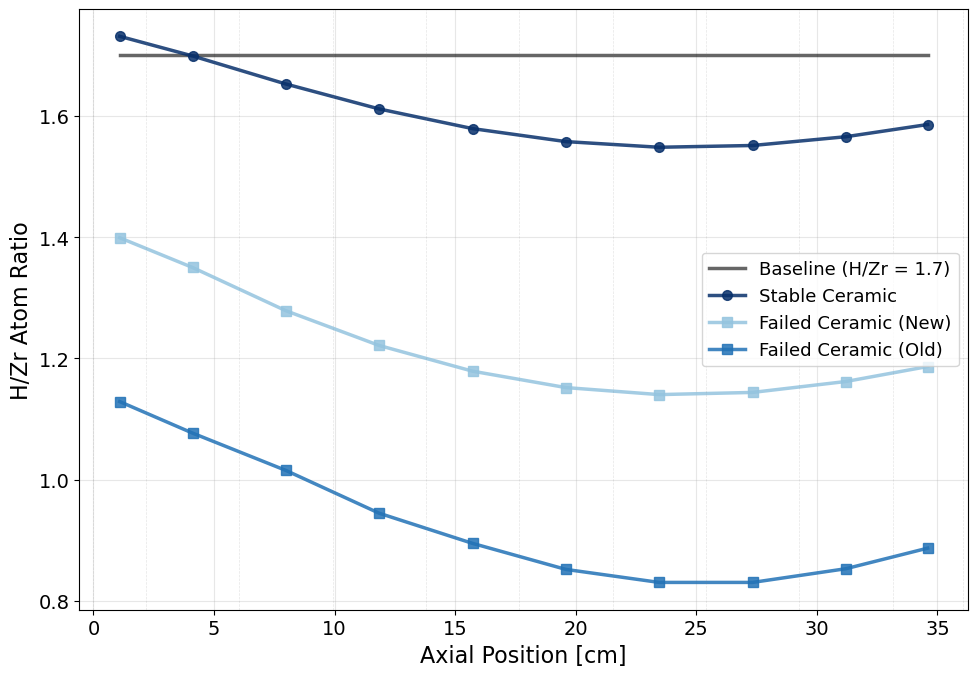

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Layer geometry (unchanged from SWIFT script) ─────────────────────────────
def get_layer_boundaries():
    acl_start = 0.0;     acl_end = 2.1717
    acm_start = 2.1717;  acm_end = 33.13785
    acu_start = 33.13785; acu_end = 36.04614
    acm_relative_boundaries = [
        0.0, 3.8707690695176256, 7.741538139035251, 11.612307208552878,
        15.483076278070502, 19.353845347588127, 23.224614417105755,
        27.09538348662338, 30.966152556141005,
    ]
    acm_height = acm_end - acm_start
    layer_boundaries = [(acl_start/100.0, acl_end/100.0)]
    for i in range(len(acm_relative_boundaries) - 1):
        z_s = acm_start + (acm_relative_boundaries[i]  /acm_relative_boundaries[-1]) * acm_height
        z_e = acm_start + (acm_relative_boundaries[i+1]/acm_relative_boundaries[-1]) * acm_height
        layer_boundaries.append((z_s/100.0, z_e/100.0))
    layer_boundaries.append((acu_start/100.0, acu_end/100.0))
    return layer_boundaries

def load_layer_averages(csv_file):
    df = pd.read_csv(csv_file, index_col=0)
    depletion_times = [float(col) for col in df.columns]
    layer_names = list(df.index)
    layer_averages = {}
    for dep_time in depletion_times:
        layer_averages[dep_time] = {ln: df.loc[ln, str(dep_time)] for ln in layer_names}
    return layer_averages, depletion_times, layer_names

# ── Failed-pin H/Zr from Serpent material definitions ────────────────────────
# H (1001.02c + 1002.02c) atom densities [atoms/barn-cm] per axial layer, bottom → top
H1_densities = np.array([
    3.98348406e-02,   # fuel_1  (bottom — ACL)
    3.80006037e-02,   # fuel_2
    3.58274317e-02,   # fuel_3
    3.33352620e-02,   # fuel_4
    3.15807746e-02,   # fuel_5
    3.00655354e-02,   # fuel_6
    2.93079158e-02,   # fuel_7
    2.93079158e-02,   # fuel_8
    3.01054101e-02,   # fuel_9
    3.13016515e-02,   # fuel_10 (top — ACU)
])

H2_densities = np.array([
    5.77605189e-06,   # fuel_1
    5.51008754e-06,   # fuel_2
    5.19497760e-06,   # fuel_3
    4.83361299e-06,   # fuel_4
    4.57921231e-06,   # fuel_5
    4.35950263e-06,   # fuel_6
    4.24964779e-06,   # fuel_7
    4.24964779e-06,   # fuel_8
    4.36528446e-06,   # fuel_9
    4.53873947e-06,   # fuel_10
])

H_densities = H1_densities + H2_densities

# Zr total atom density (identical across all layers)
Zr_total = (1.81590e-02 + 3.96000e-03 + 6.05290e-03 +
            6.13410e-03 + 9.88240e-04)   # sum of all Zr isotopes = 3.5294e-02

H_Zr_failed = H_densities / Zr_total

# ── Axial positions: centre of each layer [cm] ───────────────────────────────
layer_boundaries = get_layer_boundaries()
layer_centers_cm = np.array([np.mean(b) * 100 for b in layer_boundaries])

# ── Load 1-ring SWIFT data at 450 days ───────────────────────────────────────
base_data_dir = (
    '/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/'
    'Wet_Experiment_Models/Serpent/reactivity_worths/hydrogen_diffusion/'
    'axial_diffusion_SWIFT/cladding_held'
)
csv_ring1 = f"{base_data_dir}/rings_data/ring_1/ring1_layer_averages.csv"

la, dt, ln = load_layer_averages(csv_ring1)
H_Zr_ring1_450 = np.array([la[450.0][l] for l in ln])

csv_ring8 = "/home/garcsamu/Serpent/SNAP-REACTORS-PRIVATE/snapReactors/reactor_models/Wet_Experiment_Models/Serpent/reactivity_worths/hydrogen_diffusion/axial_diffusion_SWIFT/cladding_lost/rings_data/ring_1/ring1_layer_averages.csv"
la, dt, ln = load_layer_averages(csv_ring8)
H_Zr_failed_corrected = np.array([la[450.0][l] for l in ln])
# ── Colors matching plot_all_rings_comparison ─────────────────────────────────
colors_h    = plt.cm.Blues(np.linspace(0.4, 1.0, 8))
color_ring1 = colors_h[-1]          # Ring 1 → lightest blue (same as SWIFT plot)
color_failed_corrected = colors_h[0]           # distinct red from the colorblind-safe palette
color_failed = colors_h[4]
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(layer_centers_cm, [1.7] * len(layer_centers_cm),
        color='black', linewidth=2.5, linestyle='-', alpha=0.6,
        label='Baseline (H/Zr = 1.7)')

ax.plot(layer_centers_cm, H_Zr_ring1_450,
        marker='o', linewidth=2.5, markersize=7, alpha=0.85,
        color=color_ring1, label='Stable Ceramic')

ax.plot(layer_centers_cm, H_Zr_failed_corrected,
        marker='s', linewidth=2.5, markersize=7, alpha=0.85,
        color=color_failed_corrected, label='Failed Ceramic (New)')

ax.plot(layer_centers_cm, H_Zr_failed,
        marker='s', linewidth=2.5, markersize=7, alpha=0.85,
        color=color_failed, label='Failed Ceramic (Old)')

# Layer boundary markers
for bound in layer_boundaries:
    ax.axvline(bound[0] * 100, color='gray', linestyle='--', alpha=0.2, linewidth=0.5)
ax.axvline(layer_boundaries[-1][1] * 100, color='gray', linestyle='--', alpha=0.2, linewidth=0.5)

ax.set_xlabel('Axial Position [cm]', fontsize=16)
ax.set_ylabel('H/Zr Atom Ratio',     fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[0.00000000e+00 1.99775722e+00 3.97253537e+00 5.92493319e+00
 7.85554140e+00 9.76494275e+00 1.16537121e+01 1.35224165e+01
 1.53716153e+01 1.72018599e+01 1.90136945e+01 2.08076554e+01
 2.25842715e+01 2.43440643e+01 2.60875480e+01 2.78152293e+01
 2.95276077e+01 3.12251759e+01 3.29084189e+01 3.45778151e+01
 3.62338357e+01 3.78769450e+01 3.95076006e+01 4.11262531e+01
 4.27333464e+01 4.43293179e+01 4.59145981e+01 4.74896112e+01
 4.90547747e+01 5.06104998e+01 5.21571914e+01 5.36952478e+01
 5.52250613e+01 5.67470179e+01 5.82614975e+01 5.97688739e+01
 6.12695148e+01 6.27637821e+01 6.42520317e+01 6.57346136e+01
 6.72118720e+01 6.86841455e+01 7.01517669e+01 7.16150633e+01
 7.30743566e+01 7.45299626e+01 7.59821922e+01 7.74313505e+01
 7.88777374e+01 8.03216476e+01 8.17633704e+01 8.32031900e+01
 8.46413853e+01 8.60782303e+01 8.75139939e+01 8.89489401e+01
 9.03833279e+01 9.18174113e+01 9.32514397e+01 9.46856576e+01
 9.61203048e+01 9.75556164e+01 9.89918229e+01 1.00429150e+02
 1.01867820e+02 1.033080

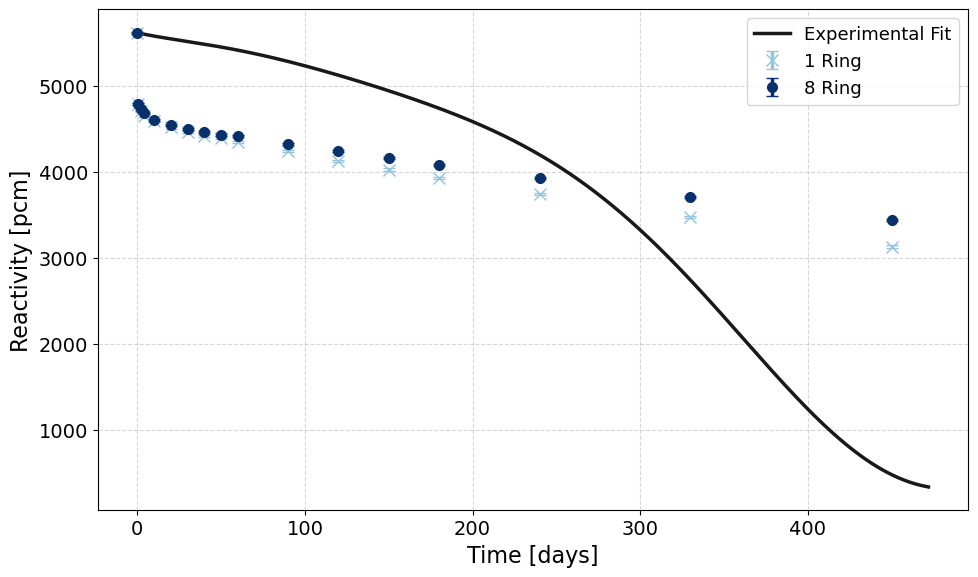

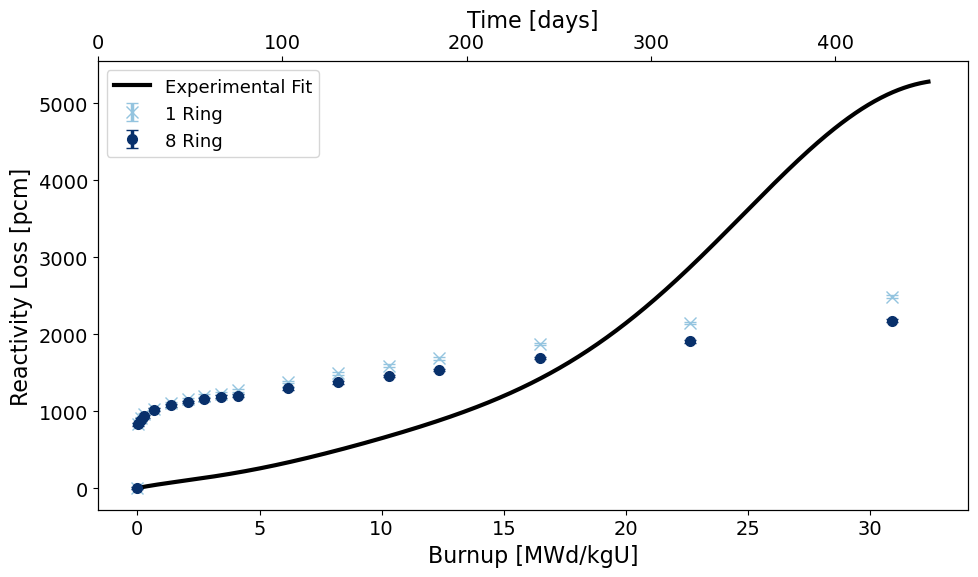

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import serpentTools as st

def cumulative_hydrogen_loss_experimental(burnup_MWd_kgU, bu0=0):
    def integral(b):
        return (
            +3.3488465592e-06 * b**7
            -3.7975024974e-04 * b**6
            +1.5872056282e-02 * b**5
            -3.0814994979e-01 * b**4
            +2.9906137252e+00 * b**3
            -1.1226376851e+01 * b**2
            +6.1999996387e+01 * b**1
        )
    if isinstance(burnup_MWd_kgU, np.ndarray):
        return np.array([integral(bu) - integral(bu0) for bu in burnup_MWd_kgU])
    return integral(burnup_MWd_kgU) - integral(bu0)

THERMAL_POWER = 0.450  # MW
U_MASS        = 6.560  # kg

def days_to_burnup(days):
    return (THERMAL_POWER * days) / U_MASS

# ── Data loading ─────────────────────────────────────────────────────────────
base_path    = Path.cwd()
res_name     = 'standardconditions.main_res.m'
state_points = ['000_5','002_0','004_0','010_0','020_0','030_0','040_0',
                '050_0','060_0','090_0','120_0','150_0','180_0','240_0','330_0','450_0']
statepoints  = [0, 0.5, 2, 4, 10, 20, 30, 40, 50, 60, 90, 120, 150, 180, 240, 330, 450]

rho_list_1ring = []; unc_list_1ring = []
rho_list_8ring = []; unc_list_8ring = []

ref_path = Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'/'axial_diffusion_SWIFT'/'reference'/res_name).resolve())
ref_res  = st.read(ref_path)
k       = ref_res['anaKeff'][0]; k_unc = ref_res['anaKeff'][1]
rho_ref = (k-1)/k * 1e5;        unc_ref = (1/k**2) * k_unc * 1e5

rho_list_1ring.append(rho_ref); unc_list_1ring.append(unc_ref)
rho_list_8ring.append(rho_ref); unc_list_8ring.append(unc_ref)

for sp in state_points:
    for rho_list, unc_list, ring in [(rho_list_1ring, unc_list_1ring, '1_ring'),
                                      (rho_list_8ring, unc_list_8ring, '8_ring')]:
        res_path = Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'
                         /'axial_diffusion_SWIFT'/'cladding_held'/ring/sp/res_name).resolve())
        res = st.read(res_path)
        k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
        rho_list.append((k-1)/k * 1e5)
        unc_list.append((1/k**2) * k_unc * 1e5)

# ── Experimental reactivity curve ────────────────────────────────────────────
t_smooth       = np.linspace(0, 472, 1000)
exp_loss_smooth = cumulative_hydrogen_loss_experimental(days_to_burnup(t_smooth))
print(exp_loss_smooth)
rho_exp_smooth  = rho_ref - exp_loss_smooth   # absolute reactivity, not loss

# ── Colors matching plot_all_rings_comparison (Blues colormap) ───────────────
colors_h    = plt.cm.Blues(np.linspace(0.4, 1.0, 8))
color_1ring = colors_h[0]   # Ring 1 → lightest blue
color_8ring = colors_h[7]   # Ring 8 → darkest blue

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_smooth, rho_exp_smooth, 'k-', linewidth=2.5,
        label='Experimental Fit', zorder=3, alpha=0.9)

ax.errorbar(statepoints, rho_list_1ring, yerr=[3*u for u in unc_list_1ring],
            fmt='x', label='1 Ring', color=color_1ring,
            capsize=4, markersize=8, zorder=3)
ax.errorbar(statepoints, rho_list_8ring, yerr=[3*u for u in unc_list_8ring],
            fmt='o', label='8 Ring', color=color_8ring,
            capsize=4, markersize=7, zorder=3)

ax.set_xlabel('Time [days]', fontsize=16)
ax.set_ylabel('Reactivity [pcm]', fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('swift_reactivity.png', dpi=400, bbox_inches='tight')
plt.show()

base_path   = Path.cwd()
res_name    = 'standardconditions.main_res.m'
state_points = ['000_5','002_0','004_0','010_0','020_0','030_0','040_0',
                '050_0','060_0','090_0','120_0','150_0','180_0','240_0','330_0','450_0']
statepoints  = [0, 0.5, 2, 4, 10, 20, 30, 40, 50, 60, 90, 120, 150, 180, 240, 330, 450]

rho_list_1ring = []; unc_list_1ring = []
rho_list_8ring = []; unc_list_8ring = []

ref_path = Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'/'axial_diffusion_SWIFT'/'reference'/res_name).resolve())
ref_res  = st.read(ref_path)
k     = ref_res['anaKeff'][0]; k_unc = ref_res['anaKeff'][1]
rho_ref = (k-1)/k * 1e5;      unc_ref = (1/k**2) * k_unc * 1e5
rho_list_1ring.append(rho_ref); unc_list_1ring.append(unc_ref)
rho_list_8ring.append(rho_ref); unc_list_8ring.append(unc_ref)

for sp in state_points:
    for rho_list, unc_list, ring in [(rho_list_1ring, unc_list_1ring, '1_ring'),
                                      (rho_list_8ring, unc_list_8ring, '8_ring')]:
        res_path = Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'
                         /'axial_diffusion_SWIFT'/'cladding_held'/ring/sp/res_name).resolve())
        res = st.read(res_path)
        k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
        rho = (k-1)/k * 1e5; err_rho = (1/k**2) * k_unc * 1e5
        rho_list.append(rho); unc_list.append(err_rho)

THERMAL_POWER = 0.450; U_MASS = 6.560
days_max    = 472
time_days   = np.linspace(0, days_max, 1000)
burnup_range = days_to_burnup(time_days)
exp_cumulative_loss = cumulative_hydrogen_loss_experimental(burnup_range, bu0=0)
rho_1ring_arr = np.array(rho_list_1ring); rho_8ring_arr = np.array(rho_list_8ring)
unc_1ring_arr = np.array(unc_list_1ring); unc_8ring_arr = np.array(unc_list_8ring)
rho_loss_1ring = rho_1ring_arr[0] - rho_1ring_arr
rho_loss_8ring = rho_8ring_arr[0] - rho_8ring_arr
unc_loss_1ring = np.sqrt(unc_1ring_arr[0]**2 + unc_1ring_arr**2)
unc_loss_8ring = np.sqrt(unc_8ring_arr[0]**2 + unc_8ring_arr**2)

# Match the Blues colormap used in plot_all_rings_comparison:
# Ring 1 → index 0, Ring 8 → index 7
colors_h = plt.cm.Blues(np.linspace(0.4, 1.0, 8))
color_1ring = colors_h[0]   # same as Ring 1 in the SWIFT plot
color_8ring = colors_h[7]   # same as Ring 8 in the SWIFT plot

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Burnup [MWd/kgU]',           fontsize=16)
ax1.set_ylabel('Reactivity Loss [pcm]', fontsize=16)
ax1.errorbar([state * THERMAL_POWER/U_MASS for state in statepoints], rho_loss_1ring, yerr=[3*u for u in unc_loss_1ring],
            fmt='x', label='1 Ring', color=color_1ring, capsize=4, markersize=8, zorder=3)
ax1.errorbar([state * THERMAL_POWER/U_MASS for state in statepoints], rho_loss_8ring, yerr=[3*u for u in unc_loss_8ring],
            fmt='o', label='8 Ring', color=color_8ring, capsize=4, markersize=7, zorder=3)
ax1.plot(burnup_range, exp_cumulative_loss, 'k-', linewidth=3, label='Experimental Fit', zorder=3)
ax2 = ax1.twiny()
ax2.set_xlim(time_days[0], time_days[-1])
ax2.set_xlabel("Time [days]")
ax.tick_params(labelsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=13)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# Long-Term Reactivity Effects

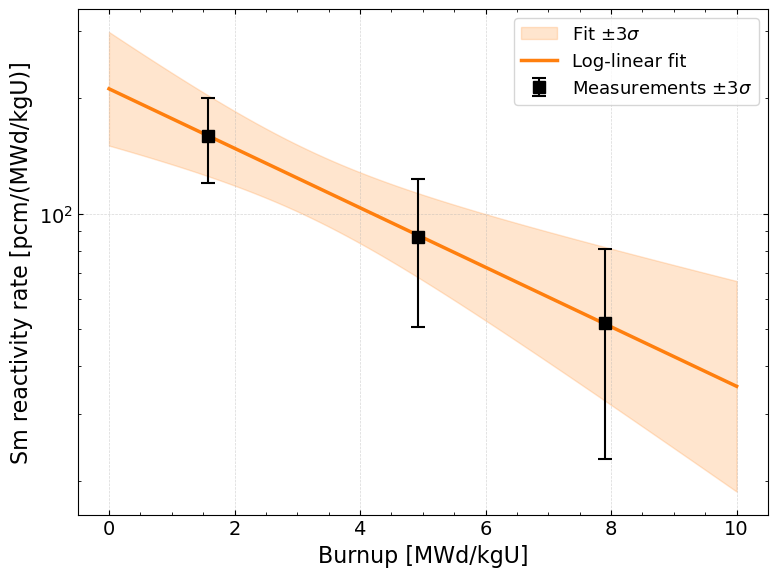

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

E_meas  = np.array([1.58, 4.92, 7.91])
R_meas  = np.array([160.0, 87.0, 52.0])
sigma_R = np.array([13.3, 12.1,  9.7])

lnR       = np.log(R_meas)
sigma_lnR = sigma_R / R_meas
weights   = 1.0 / sigma_lnR**2
S_w   = np.sum(weights); S_wE  = np.sum(weights*E_meas)
S_wE2 = np.sum(weights*E_meas**2); S_wY = np.sum(weights*lnR); S_wEY = np.sum(weights*E_meas*lnR)
Delta = S_w*S_wE2 - S_wE**2
a = (S_wE2*S_wY - S_wE*S_wEY) / Delta
b = (S_w*S_wEY  - S_wE*S_wY)  / Delta
var_a = S_wE2/Delta; var_b = S_w/Delta; cov_ab = -S_wE/Delta
sigma_a = np.sqrt(var_a); sigma_b = np.sqrt(var_b)

E_fit = np.linspace(0, 10, 300)
R_fit = np.exp(a + b*E_fit)
sigma_lnR_fit = np.sqrt(var_a + E_fit**2*var_b + 2*E_fit*cov_ab)
R_upper = np.exp(a + b*E_fit + 3*sigma_lnR_fit)
R_lower = np.exp(a + b*E_fit - 3*sigma_lnR_fit)

fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(E_fit, R_lower, R_upper, color="tab:orange", alpha=0.2, label=r"Fit $\pm 3\sigma$")
ax.plot(E_fit, R_fit, color="tab:orange", linewidth=2.5, label="Log-linear fit")
ax.errorbar(E_meas, R_meas, yerr=3*sigma_R, fmt="ks", markersize=8,
            capsize=5, capthick=1.5, elinewidth=1.5, label=r"Measurements $\pm 3\sigma$")
ax.set_yscale("log")
ax.set_xlabel("Burnup [MWd/kgU]",                       fontsize=16)
ax.set_ylabel("Sm reactivity rate [pcm/(MWd/kgU)]",      fontsize=16)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(fontsize=13)
fig.tight_layout()
plt.show()


0.0


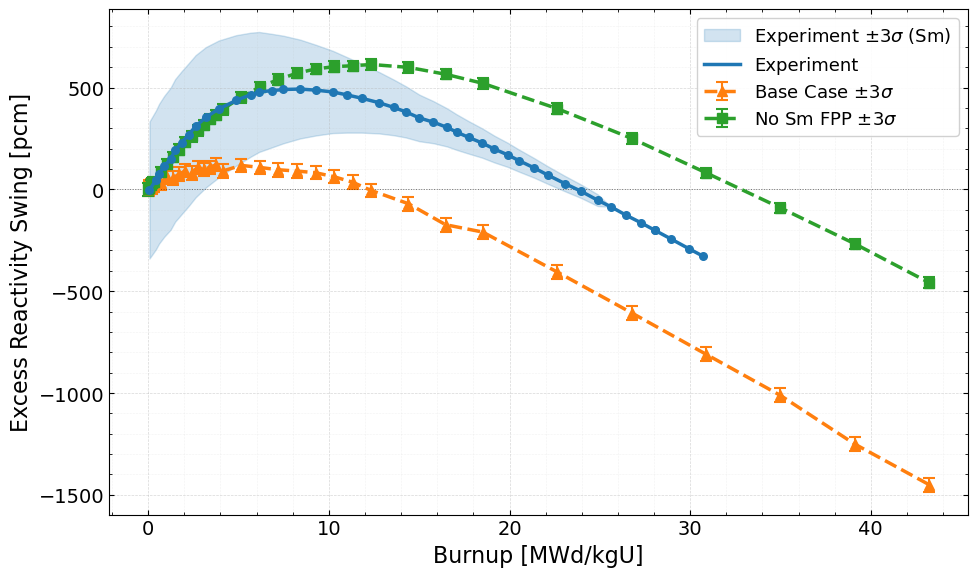

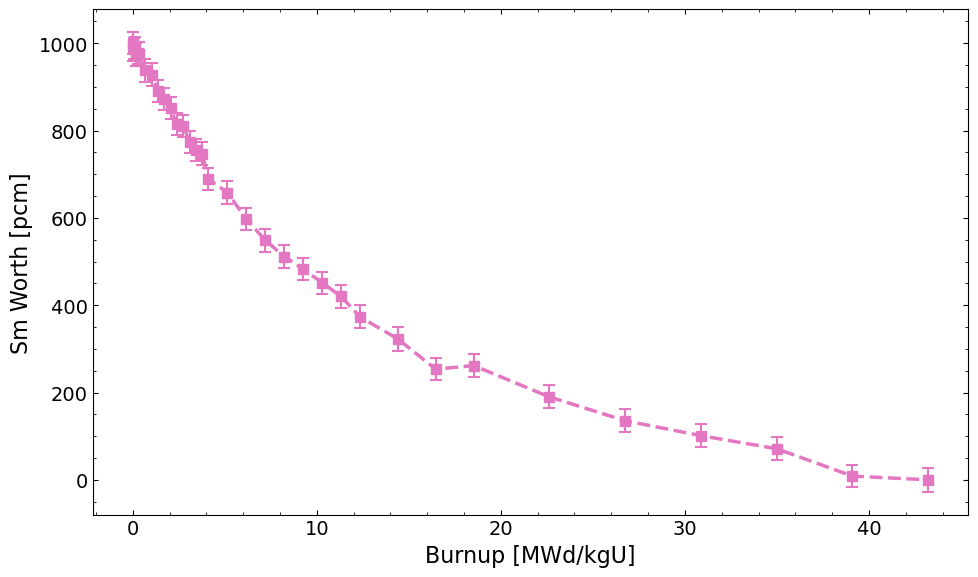

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

exp_burnup = np.array([
    0.070967888, 0.425807331, 0.603227052, 0.887098606, 1.241938048,
    1.490325657, 1.8451651,   2.235488486, 2.625811873, 3.19355498,
    3.903233865, 4.861300359, 5.677431076, 6.138722351, 6.848401235,
    7.487112231, 8.409694781, 9.296793387, 10.21937594, 11.00002271,
    11.81615343, 12.77421992, 13.59035064, 14.26454558, 15.00970841,
    15.79035518, 16.53551801, 17.06777717, 17.74197211, 18.48713494,
    19.16132988, 19.90649271, 20.50971976, 21.36133442, 22.1419812,
    23.06456375, 23.95166235, 24.8742449,  25.61940773, 26.47102239,
    27.25166916, 28.03231594, 28.03231594, 28.95489849, 29.91296498,
    30.7290957,
])
exp_rho = np.array([
    -3.3,   46.2,   77.0,  113.3,  150.7,  191.4,  228.8,  268.4,
    310.2,  354.2,  394.9,  436.7,  465.3,  478.5,  485.1,  490.6,
    492.8,  487.3,  478.5,  464.2,  447.7,  425.7,  402.6,  380.6,
    350.9,  330.0,  304.7,  281.6,  255.2,  227.7,  198.0,  169.4,
    141.9,  105.6,   69.3,   28.6,   -8.8,  -52.8,  -85.8, -127.6,
   -162.8, -200.2, -200.2, -244.2, -290.4, -328.9,
])

E_meas  = np.array([1.58, 4.76, 7.74])
R_meas  = np.array([160.0, 87.0, 52.0])
sigma_R = np.array([13.3, 12.1,  9.7])
lnR       = np.log(R_meas); sigma_lnR = sigma_R/R_meas; weights = 1.0/sigma_lnR**2
S_w=np.sum(weights); S_wE=np.sum(weights*E_meas); S_wE2=np.sum(weights*E_meas**2)
S_wY=np.sum(weights*lnR); S_wEY=np.sum(weights*E_meas*lnR)
Delta=S_w*S_wE2-S_wE**2
a=(S_wE2*S_wY-S_wE*S_wEY)/Delta; b=(S_w*S_wEY-S_wE*S_wY)/Delta
var_a=S_wE2/Delta; var_b=S_w/Delta; cov_ab=-S_wE/Delta

def Sm_worth(E, a, b):    return (np.exp(a)/np.abs(b))*np.exp(b*E)
def dS_da(E, a, b):       return Sm_worth(E, a, b)
def dS_db(E, a, b):       return np.exp(a+b*E)*(1.0-b*E)/b**2
Sm_burnup = exp_burnup[0:-8]
var_S = (dS_da(Sm_burnup,a,b)**2*var_a + dS_db(Sm_burnup,a,b)**2*var_b
         + 2*dS_da(Sm_burnup,a,b)*dS_db(Sm_burnup,a,b)*cov_ab)
sigma_exp_pcm = np.sqrt(np.maximum(var_S, 0))
sigma_exp_pcm = np.append(sigma_exp_pcm, np.zeros(8))
current_dir      = Path.cwd()
# ── Load original single depletion run ───────────────────────────────────────

current_dir      = Path.cwd()
base_path        = current_dir / "Serpent/depletion"
serpent_res_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_res.m"
serpent_dep_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_dep.m"

serpent_burnup, serpent_rho, serpent_err = load_serpent_results(serpent_res_path, serpent_dep_path)
serpent_burnup = np.asarray(serpent_burnup)
serpent_rho    = np.asarray(serpent_rho)
serpent_err    = np.asarray(serpent_err)
serpent_longterm   = serpent_rho - serpent_rho[0]
err_propagated     = np.sqrt(serpent_err**2 + serpent_err[0]**2)

# ── Load per-step restart results ─────────────────────────────────────────────

steps_path = current_dir / "Serpent/depletion/Serpent_Res/no_sm"

step_rhos    = []
step_errs    = []

for i in range(1, 35):
    step_dir = steps_path / f"step_{i}"
    res_path = step_dir / "s82d_ac_c3_gcu_ringres.main_res.m"

    if not res_path.exists():
        print(f"WARNING: Missing res file for step_{i}, skipping.")
        step_rhos.append(np.nan)
        step_errs.append(np.nan)
        continue

    dep      = st.read(res_path)
    k_values = dep['impKeff'][0]
    k_errors = dep['impKeff'][1]
    rho, rho_err = calculate_reactivity(k_values, k_errors)

    step_rhos.append(rho)
    step_errs.append(rho_err)
step_rhos.insert(0, serpent_rho[0])
step_errs.insert(0, serpent_err[0])
step_rhos = np.array(step_rhos)
step_errs = np.array(step_errs)

# Use the original depletion burnup array as x-axis (skip index 0, the initial point)
step_burnups = serpent_burnup

step_longterm       = step_rhos - serpent_rho[0]
step_err_propagated = np.sqrt(step_errs**2 + step_errs[0]**2)

# ── Plotting ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(exp_burnup, exp_rho - 3*sigma_exp_pcm, exp_rho + 3*sigma_exp_pcm,
                color="tab:blue", alpha=0.2, label=r"Experiment $\pm 3\sigma$ (Sm)")
ax.plot(exp_burnup, exp_rho, color="tab:blue", linewidth=2.5, label="Experiment", zorder=3)
ax.scatter(exp_burnup, exp_rho, color="tab:blue", s=30, zorder=4)

ax.errorbar(serpent_burnup, serpent_longterm, yerr=err_propagated,
            color="tab:orange", linewidth=2.5, linestyle="--",
            marker="^", markersize=7, capsize=4, capthick=1.5, elinewidth=1.5,
            label=r"Base Case $\pm 3\sigma$", zorder=2)

ax.errorbar(step_burnups, step_longterm, yerr=step_err_propagated,
            color="tab:green", linewidth=2.5, linestyle="--",
            marker="s", markersize=7, capsize=4, capthick=1.5, elinewidth=1.5,
            label=r"No Sm FPP $\pm 3\sigma$", zorder=2)

ax.axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.5)
ax.set_xlabel("Burnup [MWd/kgU]",              fontsize=16)
ax.set_ylabel("Excess Reactivity Swing [pcm]", fontsize=16)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(which="minor", linestyle=":",  linewidth=0.4, alpha=0.3)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
print(step_longterm[0])
plt.show()


sm_burnout = step_rhos - serpent_rho
sm_burnout_pcm = sm_burnout[-1] - sm_burnout
sm_unc = np.sqrt(step_errs**2 + serpent_err**2)
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(step_burnups, sm_burnout_pcm, yerr = sm_unc,
            color="tab:pink", linewidth=2.5, linestyle="--",
            marker="s", markersize=7, capsize=4, capthick=1.5, elinewidth=1.5,
            zorder=2)
ax.set_xlabel("Burnup [MWd/kgU]",              fontsize=16)
ax.set_ylabel("Sm Worth [pcm]", fontsize=16)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig.tight_layout()
plt.show()

[ 992.26314128 1000.37464243  987.75640949  989.55997484  974.2425447
  977.8485797   976.04706731  938.24442803  928.38524844  891.52953078
  871.81339057  851.22074016  814.41998148  810.9337477   774.16843993
  755.42167331  747.43331452  689.12587529  658.04282558  597.28409592
  549.03627096  511.55604962  482.97762032  451.60421182  420.1387649
  373.35743624  322.64132496  253.44895955  261.80355897  189.92107117
  135.41999141  101.18374206   71.23647057    8.61142187    0.        ]


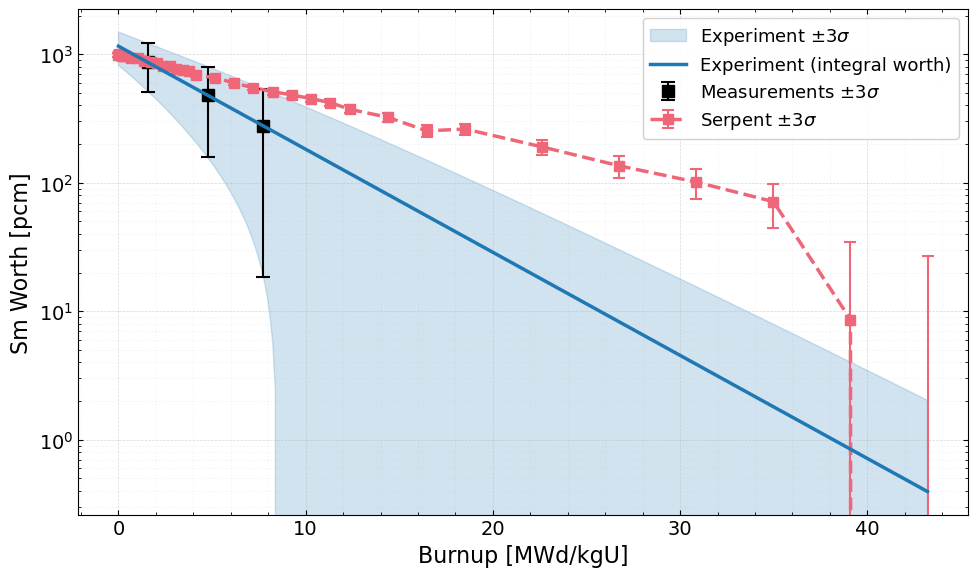

0.0


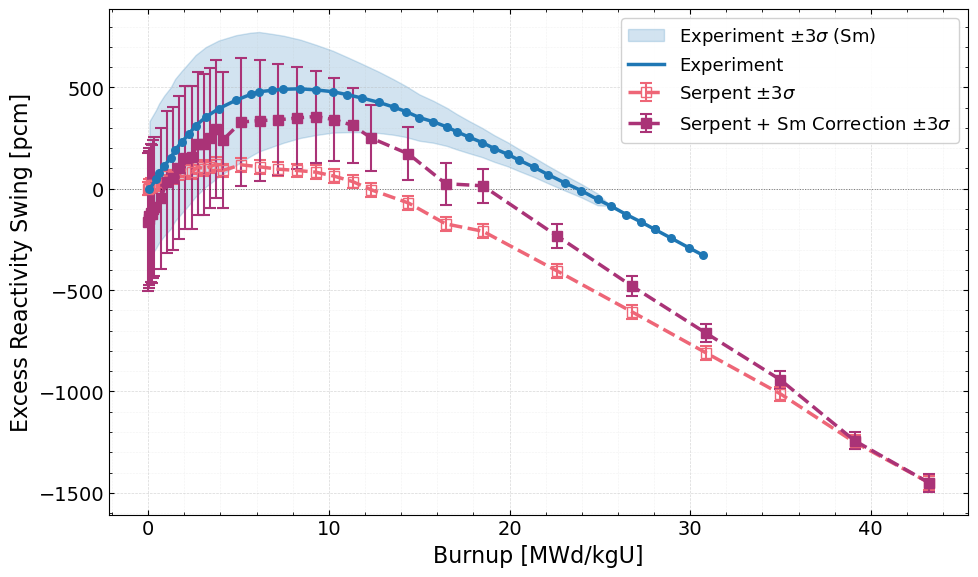

In [74]:
exp_burnup = np.array([
    0.070967888, 0.425807331, 0.603227052, 0.887098606, 1.241938048,
    1.490325657, 1.8451651,   2.235488486, 2.625811873, 3.19355498,
    3.903233865, 4.861300359, 5.677431076, 6.138722351, 6.848401235,
    7.487112231, 8.409694781, 9.296793387, 10.21937594, 11.00002271,
    11.81615343, 12.77421992, 13.59035064, 14.26454558, 15.00970841,
    15.79035518, 16.53551801, 17.06777717, 17.74197211, 18.48713494,
    19.16132988, 19.90649271, 20.50971976, 21.36133442, 22.1419812,
    23.06456375, 23.95166235, 24.8742449,  25.61940773, 26.47102239,
    27.25166916, 28.03231594, 28.03231594, 28.95489849, 29.91296498,
    30.7290957,
])
exp_rho = np.array([
    -3.3,   46.2,   77.0,  113.3,  150.7,  191.4,  228.8,  268.4,
    310.2,  354.2,  394.9,  436.7,  465.3,  478.5,  485.1,  490.6,
    492.8,  487.3,  478.5,  464.2,  447.7,  425.7,  402.6,  380.6,
    350.9,  330.0,  304.7,  281.6,  255.2,  227.7,  198.0,  169.4,
    141.9,  105.6,   69.3,   28.6,   -8.8,  -52.8,  -85.8, -127.6,
   -162.8, -200.2, -200.2, -244.2, -290.4, -328.9,
])

E_meas  = np.array([1.58, 4.76, 7.74])
R_meas  = np.array([160.0, 87.0, 52.0])
sigma_R = np.array([13.3, 12.1,  9.7])
lnR       = np.log(R_meas); sigma_lnR = sigma_R/R_meas; weights = 1.0/sigma_lnR**2
S_w=np.sum(weights); S_wE=np.sum(weights*E_meas); S_wE2=np.sum(weights*E_meas**2)
S_wY=np.sum(weights*lnR); S_wEY=np.sum(weights*E_meas*lnR)
Delta=S_w*S_wE2-S_wE**2
a=(S_wE2*S_wY-S_wE*S_wEY)/Delta; b=(S_w*S_wEY-S_wE*S_wY)/Delta
var_a=S_wE2/Delta; var_b=S_w/Delta; cov_ab=-S_wE/Delta

def Sm_worth(E, a, b):    return (np.exp(a)/np.abs(b))*np.exp(b*E)
def dS_da(E, a, b):       return Sm_worth(E, a, b)
def dS_db(E, a, b):       return np.exp(a+b*E)*(1.0-b*E)/b**2
Sm_burnup = exp_burnup[0:-8]
var_S = (dS_da(Sm_burnup,a,b)**2*var_a + dS_db(Sm_burnup,a,b)**2*var_b
         + 2*dS_da(Sm_burnup,a,b)*dS_db(Sm_burnup,a,b)*cov_ab)
sigma_exp_pcm = np.sqrt(np.maximum(var_S, 0))
sigma_exp_pcm = np.append(sigma_exp_pcm, np.zeros(8))
current_dir      = Path.cwd()
# ── Load original single depletion run ───────────────────────────────────────

current_dir      = Path.cwd()
base_path        = current_dir / "Serpent/depletion"
serpent_res_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_res.m"
serpent_dep_path = base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_dep.m"

serpent_burnup, serpent_rho, serpent_err = load_serpent_results(serpent_res_path, serpent_dep_path)
serpent_burnup = np.asarray(serpent_burnup)
serpent_rho    = np.asarray(serpent_rho)
serpent_err    = np.asarray(serpent_err)

# ── Load per-step restart results ─────────────────────────────────────────────

steps_path = current_dir / "Serpent/depletion/Serpent_Res/no_sm"

step_rhos    = []
step_errs    = []

for i in range(1, 35):
    step_dir = steps_path / f"step_{i}"
    res_path = step_dir / "s82d_ac_c3_gcu_ringres.main_res.m"

    if not res_path.exists():
        print(f"WARNING: Missing res file for step_{i}, skipping.")
        step_rhos.append(np.nan)
        step_errs.append(np.nan)
        continue

    dep      = st.read(res_path)
    k_values = dep['impKeff'][0]
    k_errors = dep['impKeff'][1]
    rho, rho_err = calculate_reactivity(k_values, k_errors)

    step_rhos.append(rho)
    step_errs.append(rho_err)
step_rhos.insert(0, serpent_rho[0])
step_errs.insert(0, serpent_err[0])
step_rhos = np.array(step_rhos)
step_errs = np.array(step_errs)
serpent_longterm   = serpent_rho - serpent_rho[0]
err_propagated     = np.sqrt(serpent_err**2 + serpent_err[0]**2)
# Use the original depletion burnup array as x-axis (skip index 0, the initial point)
step_burnups = serpent_burnup

step_longterm       = step_rhos - serpent_rho[0]
step_err_propagated = np.sqrt(step_errs**2 + step_errs[0]**2)

sm_burnout = step_rhos - serpent_rho
sm_burnout_pcm = sm_burnout[-1] - sm_burnout
sm_unc = np.sqrt(step_errs**2 + serpent_err**2)

print(sm_burnout_pcm)
# --- Experimental integral Sm worth over burnup range
E_plot      = np.linspace(step_burnups[0], step_burnups[-1], 300)
Sm_integral = Sm_worth(E_plot, a, b)

# --- Uncertainty on integral worth
var_S_plot      = (dS_da(E_plot, a, b)**2 * var_a
                 + dS_db(E_plot, a, b)**2 * var_b
                 + 2 * dS_da(E_plot, a, b) * dS_db(E_plot, a, b) * cov_ab)
sigma_S_plot    = 3 * np.sqrt(np.maximum(var_S_plot, 0))

# --- Also evaluate at the measurement points for scatter
Sm_at_meas      = Sm_worth(E_meas, a, b)
sigma_S_meas    = 3 * np.sqrt((dS_da(E_meas, a, b)**2 * var_a
                             + dS_db(E_meas, a, b)**2 * var_b
                             + 2 * dS_da(E_meas, a, b) * dS_db(E_meas, a, b) * cov_ab))

fig, ax = plt.subplots(figsize=(10, 6))
color = '#EE6677'
# --- Experimental integral Sm worth
ax.fill_between(E_plot, Sm_integral - sigma_S_plot, Sm_integral + sigma_S_plot,
                color="tab:blue", alpha=0.2, label=r"Experiment $\pm 3\sigma$")
ax.plot(E_plot, Sm_integral,
        color="tab:blue", linewidth=2.5, label="Experiment (integral worth)", zorder=3)
ax.errorbar(E_meas, Sm_at_meas, yerr=sigma_S_meas,
            fmt="ks", markersize=8, capsize=5, capthick=1.5,
            elinewidth=1.5, label=r"Measurements $\pm 3\sigma$")

# --- Simulated Sm worth
ax.errorbar(step_burnups, sm_burnout_pcm, yerr=sm_unc,
            color=color, linewidth=2.5, linestyle="--",
            marker="s", markersize=7, capsize=4, capthick=1.5,
            elinewidth=1.5, label=r"Serpent $\pm 3\sigma$", zorder=2)

ax.set_yscale("log")
ax.set_xlabel("Burnup [MWd/kgU]", fontsize=16)
ax.set_ylabel("Sm Worth [pcm]",   fontsize=16)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(which="minor", linestyle=":",  linewidth=0.4, alpha=0.3)
ax.legend(fontsize=13, framealpha=0.9)
fig.tight_layout()
plt.show()

# --- Evaluate experimental integral worth at the Serpent burnup points
Sm_at_steps       = Sm_worth(step_burnups, a, b)
var_S_at_steps    = (dS_da(step_burnups, a, b)**2 * var_a
                   + dS_db(step_burnups, a, b)**2 * var_b
                   + 2 * dS_da(step_burnups, a, b) * dS_db(step_burnups, a, b) * cov_ab)
sigma_S_at_steps  = 3 * np.sqrt(np.maximum(var_S_at_steps, 0))

# --- Difference: Serpent - Experiment
sm_diff     = sm_burnout_pcm - Sm_at_steps
sm_unc = sm_unc/3
sm_diff_unc = 3 * np.sqrt(sm_unc**2 + (sigma_S_at_steps / 3)**2)  # combine 1-sigma unc then scale to 3
serpent_longterm_sm = serpent_longterm + sm_diff
err_propogated_sm = np.sqrt(err_propagated **2 + sm_diff_unc **2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(exp_burnup, exp_rho - 3*sigma_exp_pcm, exp_rho + 3*sigma_exp_pcm,
                color="tab:blue", alpha=0.2, label=r"Experiment $\pm 3\sigma$ (Sm)")
ax.plot(exp_burnup, exp_rho, color="tab:blue", linewidth=2.5, label="Experiment", zorder=3)
ax.scatter(exp_burnup, exp_rho, color="tab:blue", s=30, zorder=4)

color = '#EE6677'
color2 = '#AA3377'  # darker shade for the filled version

ax.errorbar(serpent_burnup, serpent_longterm, yerr=err_propagated,
            color=color,
            markerfacecolor='none', markeredgecolor=color,
            linewidth=2.5, linestyle="--",
            marker="s", markersize=7, capsize=4, capthick=1.5, elinewidth=1.5,
            label=r"Serpent $\pm 3\sigma$", zorder=2)

ax.errorbar(serpent_burnup, serpent_longterm_sm, yerr=err_propogated_sm,
            color=color2,
            markerfacecolor=color2, markeredgecolor=color2,
            linewidth=2.5, linestyle="--",
            marker="s", markersize=7, capsize=4, capthick=1.5, elinewidth=1.5,
            label=r"Serpent + Sm Correction $\pm 3\sigma$", zorder=2)

ax.axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.5)
ax.set_xlabel("Burnup [MWd/kgU]",              fontsize=16)
ax.set_ylabel("Excess Reactivity Swing [pcm]", fontsize=16)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(which="minor", linestyle=":",  linewidth=0.4, alpha=0.3)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
print(step_longterm[0])
plt.show()

# Depletion Comparison

[5466.2045114  5494.23567275 5478.95824926 5511.35693031 5503.92352881
 5529.65277688 5541.68810351 5582.21128444 5662.79252785 5681.02088188
 5734.39085037 5782.59588799 5784.42215922 5852.57222262 5848.66295699
 5880.8355004  5923.09869422 5868.65977503 5959.01194434 5965.71686907
 5969.74013976 5978.85419347 5985.912718   5970.90084787 5942.32473927
 5879.71904124 5801.39998369 5654.71905551 5644.33302713 5396.58013747
 5151.04229844 4918.08656788 4688.05619506 4387.32426043 4179.8015891 ]
[5629.879518   5642.49800767 5632.58376246 5648.80599481 5642.49800767
 5650.60812287 5650.60812287 5662.32028764 5690.23763587 5686.63632026
 5704.64016503 5721.73749051 5711.83979011 5737.92927316 5728.03495182
 5738.82865455 5751.41820316 5719.93806225 5747.82153036 5737.92927316
 5726.23576249 5719.93806225 5711.83979011 5692.03819116 5665.02268446
 5624.47056689 5559.51504983 5456.48686021 5420.28364479 5224.30908138
 5023.87381231 4820.76039088 4618.62312976 4379.55594312 4180.19573908]
4044

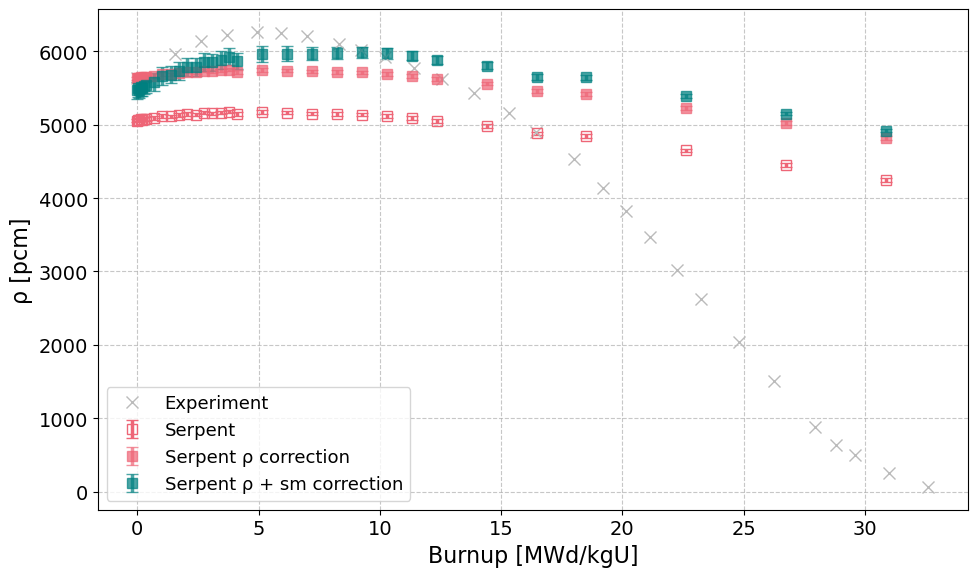

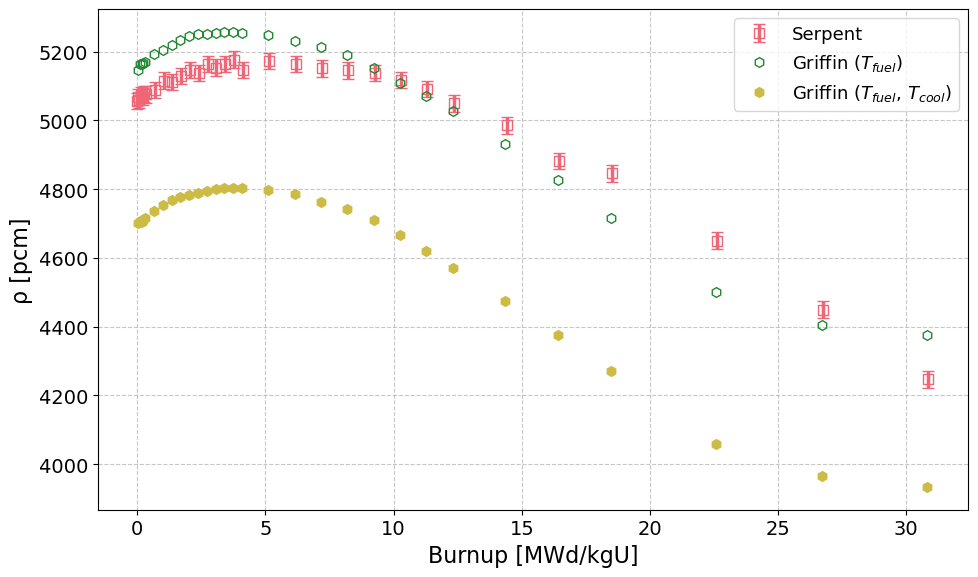

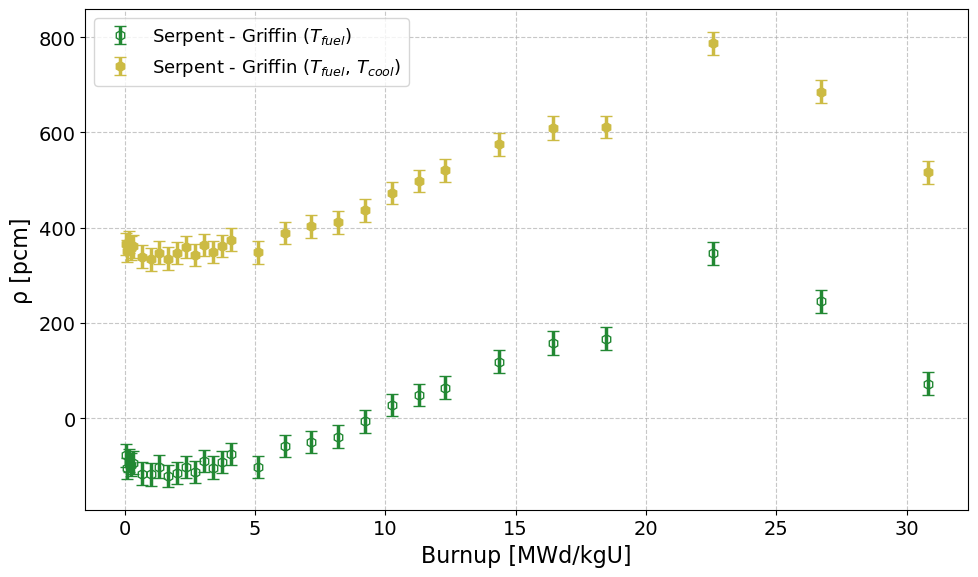

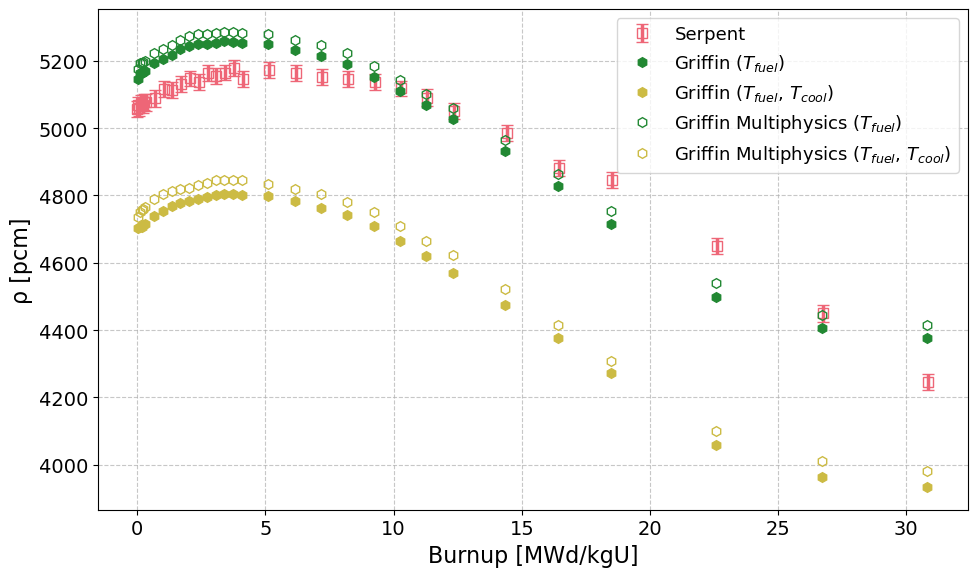

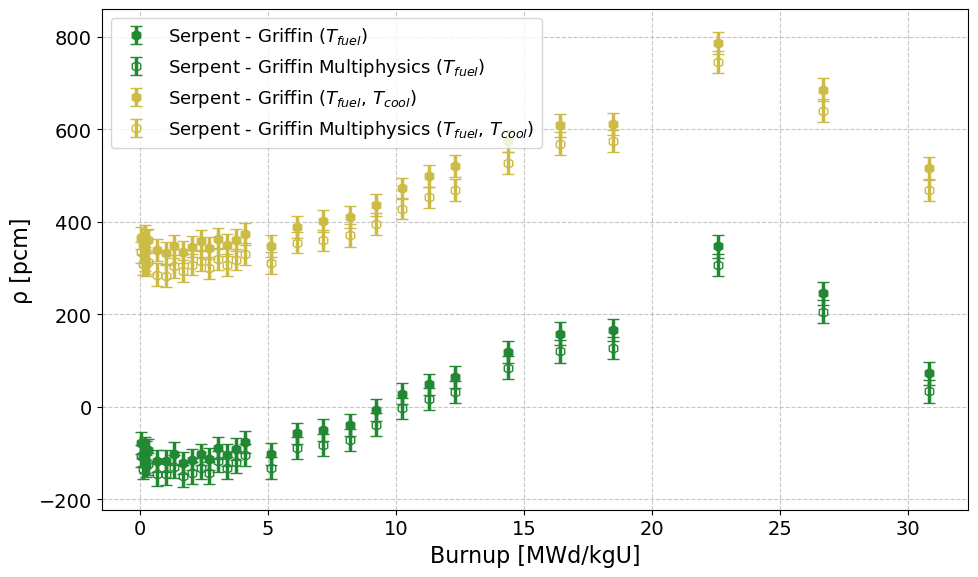

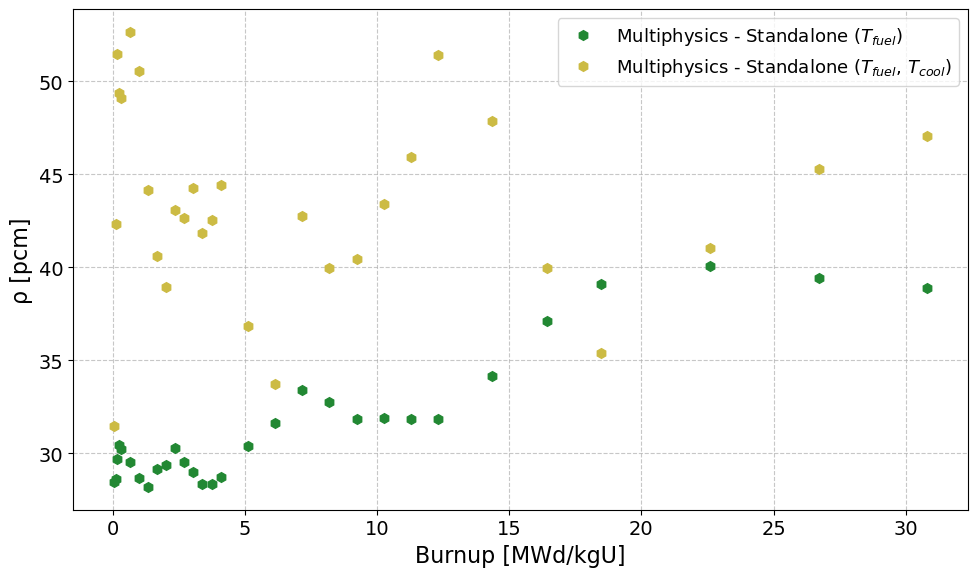

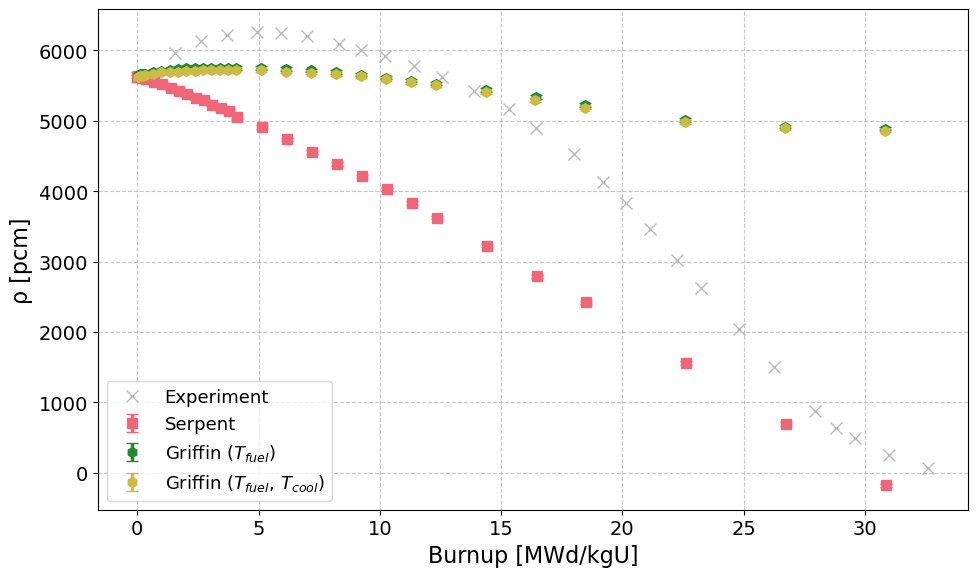

In [53]:
def cumulative_hydrogen_loss_experimental(burnup_MWd_kgU, bu0=0):
    def integral(b):
        return (
            +9.4007781053e-07 * b**7
            -1.3855844623e-04 * b**6
            +6.5406957837e-03 * b**5
            -1.3427930866e-01 * b**4
            +1.4253506292e+00 * b**3
            -5.3531892892e+00 * b**2
            +5.9119576625e+01 * b**1
        )
    if isinstance(burnup_MWd_kgU, np.ndarray):
        return np.array([integral(bu) - integral(bu0) for bu in burnup_MWd_kgU])
    return integral(burnup_MWd_kgU) - integral(bu0)

def days_to_burnup(days):
    return (THERMAL_POWER * days) / U_MASS

current_dir = Path.cwd()
base_path   = current_dir / "Serpent/depletion"
griff_path  = current_dir / "Griffin/depletion"
openmc_path = current_dir / "OpenMC_Cardinal/depletion"

openmc_burnup_dep, openmc_rho_dep, openmc_err_dep = load_openmc_results(openmc_path / "ref_endfb_results.h5")
serpent_burnup, serpent_rho, serpent_err = load_serpent_results(
    base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_res.m",
    base_path / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_dep.m")

serpent_rho_adjusted = adjust_for_hydrogen_loss(serpent_rho, serpent_burnup, h_loss_rate=162, h_loss_threshold_index=0, burnup_value=0)
serpent_rho_no_loss  = adjust_for_hydrogen_loss(serpent_rho, serpent_burnup, h_loss_rate=0)
openmc_rho_adjusted  = adjust_for_hydrogen_loss(openmc_rho_dep, openmc_burnup_dep, h_loss_rate=162, h_loss_threshold_index=0, burnup_value=0)
openmc_rho_no_loss   = adjust_for_hydrogen_loss(openmc_rho_dep, openmc_burnup_dep, h_loss_rate=0)

griff_const_data  = pd.read_csv(griff_path / "Griffin_sol/depletion_core_csv.csv")
griff_burnup = griff_const_data["burnup_MWd/kg"]
griff_rho    = (1 - 1/griff_const_data["eigenvalue"]) * 1e5
griff_rho_adjusted = adjust_for_hydrogen_loss(griff_rho, griff_burnup)

griff_phys_data  = pd.read_csv(griff_path / "full_multiphysics/depletion_core_csv.csv")
griff_phys_burnup = griff_phys_data["burnup_MWd/kg"]
griff_phys_rho    = (1 - 1/griff_phys_data["eigenvalue"]) * 1e5
griff_phys_rho_adjusted = adjust_for_hydrogen_loss(griff_phys_rho, griff_phys_burnup, bias_correction=881.531517217, h_loss_rate=0)

griff_const_data_Tfuel = pd.read_csv(griff_path / "Griffin_sol/Tfuel_only/depletion_core_csv.csv")
griff_burnup_Tfuel = griff_const_data_Tfuel["burnup_MWd/kg"]
griff_rho_Tfuel    = (1 - 1/griff_const_data_Tfuel["eigenvalue"]) * 1e5

griff_phys_data_Tfuel  = pd.read_csv(griff_path / "full_multiphysics/Tfuel_only/depletion_core_csv.csv")
griff_phys_burnup_Tfuel = griff_phys_data_Tfuel["burnup_MWd/kg"]
griff_phys_rho_Tfuel    = (1 - 1/griff_phys_data_Tfuel["eigenvalue"]) * 1e5
griff_phys_rho_Tf_adjusted = adjust_for_hydrogen_loss(griff_phys_rho_Tfuel, griff_phys_burnup, bias_correction=471.43631312, h_loss_rate=0)

exp_data   = pd.read_csv(base_path / "Serpent_Res/burn-data.csv")
exp_burnup = exp_data['x (MWd/kgU)'].values
exp_rho    = exp_data['y(pcm)'].values

# --- Evaluate experimental integral worth at the Serpent burnup points
Sm_at_steps       = Sm_worth(step_burnups, a, b)
var_S_at_steps    = (dS_da(step_burnups, a, b)**2 * var_a
                   + dS_db(step_burnups, a, b)**2 * var_b
                   + 2 * dS_da(step_burnups, a, b) * dS_db(step_burnups, a, b) * cov_ab)
sigma_S_at_steps  = 3 * np.sqrt(np.maximum(var_S_at_steps, 0))

# --- Difference: Serpent - Experiment
sm_diff     = sm_burnout_pcm - Sm_at_steps
sm_unc = sm_unc/3
sm_diff_unc = np.sqrt(sm_unc**2 + (sigma_S_at_steps / 3)**2)  # combine 1-sigma unc then scale to 3

serpent_rho_no_loss_sm = sm_diff + serpent_rho
serpent_err_sm = np.sqrt(sm_diff_unc**2 + serpent_err **2)
serpent_rho_no_loss_sm  = adjust_for_hydrogen_loss(serpent_rho_no_loss_sm, serpent_burnup, h_loss_rate=0) #, bias_correction = 737.779)
print(serpent_rho_no_loss_sm)
print(serpent_rho_no_loss)

griff_diff_rho_FC = griff_phys_rho    - griff_rho
griff_diff_rho_F  = griff_phys_rho_Tfuel - griff_rho_Tfuel
MTf_diff     = serpent_rho[0:-4] - griff_phys_rho_Tfuel
MTf_Tc_diff  = serpent_rho[0:-4] - griff_phys_rho
Tf_diff      = serpent_rho[0:-4] - griff_rho_Tfuel
Tf_Tc_diff   = serpent_rho[0:-4] - griff_rho

colors = ['#4477AA','#EE6677','#228833','#CCBB44','#66CCEE','#AA3377','#BBBBBB']
experiment_color     = colors[-1]; serpent_color = colors[1]
griffin_Tfuel_color  = colors[2];  griffin_color = colors[3]
openmc_color         = colors[4]

_lw = 2.5; _ms = 7; _cs = 4

def _depl_fig():
    return plt.figure(figsize=(10, 6))

## Plot 1 -------------------------------------------------------------------
print(serpent_rho[-3])
_depl_fig()
plt.errorbar(exp_burnup, exp_rho, fmt='x', markersize=_ms+1, label="Experiment", color=experiment_color)
plt.errorbar(serpent_burnup[:-3], serpent_rho[:-3], yerr=serpent_err[:-3],
             fmt='s', markersize=_ms, markerfacecolor='none', markeredgecolor=serpent_color,
             label='Serpent', color=serpent_color, capsize=_cs)
plt.errorbar(serpent_burnup[:-3], serpent_rho_no_loss[:-3], yerr=serpent_err[:-3],
             fmt='s', markersize=_ms, markerfacecolor=serpent_color,
             alpha=0.7, label='Serpent ρ correction', color=serpent_color, capsize=_cs)
plt.errorbar(serpent_burnup[:-3], serpent_rho_no_loss_sm[:-3], yerr=serpent_err_sm[:-3],
             fmt='s', markersize=_ms, markerfacecolor='teal',
             alpha=0.7, label='Serpent ρ + sm correction', color='teal', capsize=_cs)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 2 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(serpent_burnup[:-3], serpent_rho[:-3], yerr=serpent_err[:-3],
             fmt='s', markersize=_ms, markerfacecolor='none', markeredgecolor=serpent_color,
             label='Serpent', color=serpent_color, capsize=_cs)
plt.errorbar(griff_burnup_Tfuel[1:], griff_rho_Tfuel[1:], fmt='h', markersize=_ms,
             markerfacecolor='none', label=r"Griffin ($T_{fuel}$)", color=griffin_Tfuel_color)
plt.errorbar(griff_burnup[1:],       griff_rho[1:],        fmt='h', markersize=_ms,
             label=r"Griffin ($T_{fuel}$, $T_{cool}$)", color=griffin_color)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 3 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(griff_burnup_Tfuel[1:], Tf_diff[1:],    yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             markerfacecolor='none', label=r'Serpent - Griffin ($T_{fuel}$)', color=griffin_Tfuel_color, capsize=_cs)
plt.errorbar(griff_burnup[1:],       Tf_Tc_diff[1:], yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             label=r"Serpent - Griffin ($T_{fuel}$, $T_{cool}$)", color=griffin_color, capsize=_cs)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 4 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(serpent_burnup[:-3], serpent_rho[:-3], yerr=serpent_err[:-3],
             fmt='s', markersize=_ms, markerfacecolor='none', markeredgecolor=serpent_color,
             label='Serpent', color=serpent_color, capsize=_cs)
plt.errorbar(griff_burnup_Tfuel[1:],      griff_rho_Tfuel[1:],      fmt='h', markersize=_ms,
             label=r"Griffin ($T_{fuel}$)",               color=griffin_Tfuel_color)
plt.errorbar(griff_burnup[1:],            griff_rho[1:],            fmt='h', markersize=_ms,
             label=r"Griffin ($T_{fuel}$, $T_{cool}$)",   color=griffin_color)
plt.errorbar(griff_phys_burnup_Tfuel[1:], griff_phys_rho_Tfuel[1:], fmt='h', markersize=_ms,
             markerfacecolor='none', label=r"Griffin Multiphysics ($T_{fuel}$)", color=griffin_Tfuel_color)
plt.errorbar(griff_phys_burnup[1:],       griff_phys_rho[1:],       fmt='h', markersize=_ms,
             markerfacecolor='none', label=r"Griffin Multiphysics ($T_{fuel}$, $T_{cool}$)", color=griffin_color)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 5 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(griff_burnup_Tfuel[1:],      Tf_diff[1:],    yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             label=r'Serpent - Griffin ($T_{fuel}$)', color=griffin_Tfuel_color, capsize=_cs)
plt.errorbar(griff_phys_burnup_Tfuel[1:], MTf_diff[1:],   yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             markerfacecolor='none', label=r'Serpent - Griffin Multiphysics ($T_{fuel}$)', color=griffin_Tfuel_color, capsize=_cs)
plt.errorbar(griff_burnup[1:],            Tf_Tc_diff[1:], yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             label=r"Serpent - Griffin ($T_{fuel}$, $T_{cool}$)", color=griffin_color, capsize=_cs)
plt.errorbar(griff_phys_burnup[1:],       MTf_Tc_diff[1:],yerr=serpent_err[1:-4], fmt='h', markersize=_ms,
             markerfacecolor='none', label=r"Serpent - Griffin Multiphysics ($T_{fuel}$, $T_{cool}$)", color=griffin_color, capsize=_cs)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 6 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(griff_phys_burnup_Tfuel[1:], griff_diff_rho_F[1:],  fmt='h', markersize=_ms,
             label=r'Multiphysics - Standalone ($T_{fuel}$)', color=griffin_Tfuel_color)
plt.errorbar(griff_phys_burnup[1:],       griff_diff_rho_FC[1:], fmt='h', markersize=_ms,
             label=r'Multiphysics - Standalone ($T_{fuel}$, $T_{cool}$)', color=griffin_color)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

## Plot 7 -------------------------------------------------------------------
_depl_fig()
plt.errorbar(exp_burnup, exp_rho, fmt='x', markersize=_ms+1, label="Experiment", color=experiment_color)
plt.errorbar(serpent_burnup[:-3], serpent_rho_adjusted[:-3], yerr=serpent_err[:-3],
             fmt='s', markersize=_ms, markerfacecolor=serpent_color,
             label='Serpent', color=serpent_color, capsize=_cs)
plt.errorbar(griff_phys_burnup_Tfuel[1:], griff_phys_rho_Tf_adjusted[1:], yerr=serpent_err[1:-4],
             fmt='h', markersize=_ms, label=r'Griffin ($T_{fuel}$)', color=griffin_Tfuel_color, capsize=_cs)
plt.errorbar(griff_phys_burnup[1:],       griff_phys_rho_adjusted[1:],    yerr=serpent_err[1:-4],
             fmt='h', markersize=_ms, label=r'Griffin ($T_{fuel}$, $T_{cool}$)', color=griffin_color, capsize=_cs)
plt.xlabel("Burnup [MWd/kgU]", fontsize=16); plt.ylabel("ρ [pcm]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()


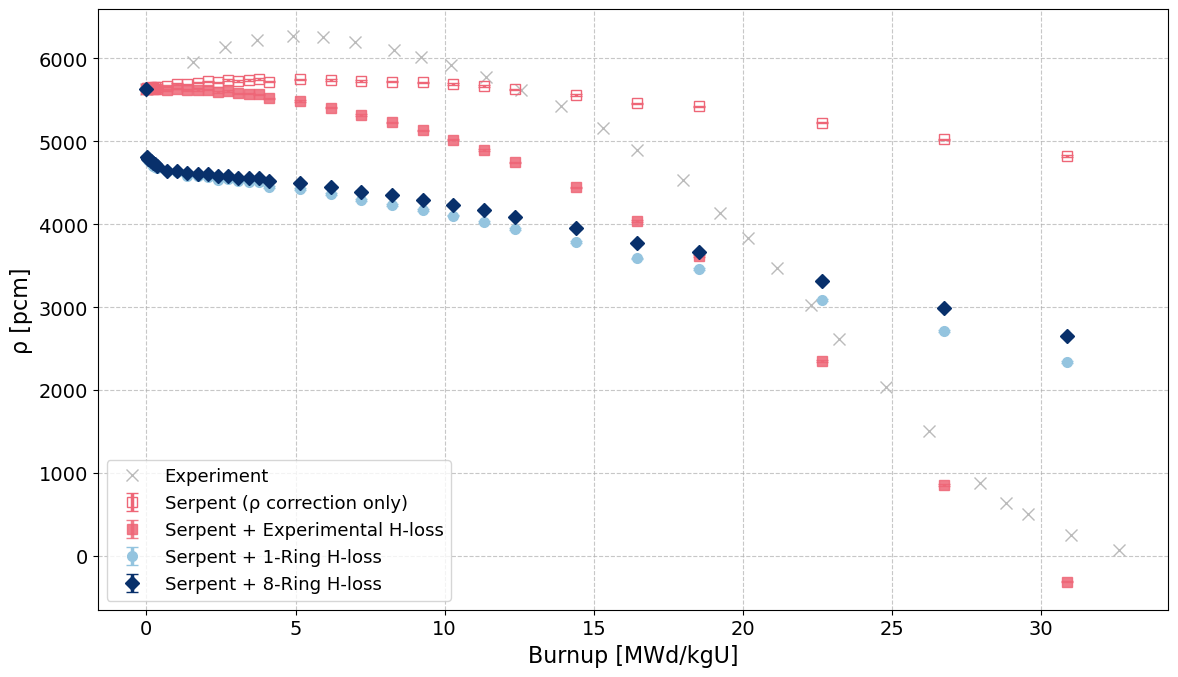

EOL discrepancy between experiment and serpent 569.0977360951035 +/- 8.06845776511573


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import serpentTools as st
from scipy.interpolate import interp1d

# ── Shared constants and helpers ──────────────────────────────────────────────
THERMAL_POWER = 0.450  # MW
U_MASS        = 6.560  # kg

def days_to_burnup(days):
    return (THERMAL_POWER * days) / U_MASS

def cumulative_hydrogen_loss_experimental(burnup_MWd_kgU, bu0=0):
    def integral(b):
        return (
            +3.3488465592e-06 * b**7
            -3.7975024974e-04 * b**6
            +1.5872056282e-02 * b**5
            -3.0814994979e-01 * b**4
            +2.9906137252e+00 * b**3
            -1.1226376851e+01 * b**2
            +6.1999996387e+01 * b**1
        )
    if isinstance(burnup_MWd_kgU, np.ndarray):
        return np.array([integral(bu) - integral(bu0) for bu in burnup_MWd_kgU])
    return integral(burnup_MWd_kgU) - integral(bu0)

# ── Load SWIFT 1-ring and 8-ring reactivity data ──────────────────────────────
base_path    = Path.cwd()
res_name     = 'standardconditions.main_res.m'
state_points = ['000_5','002_0','004_0','010_0','020_0','030_0','040_0',
                '050_0','060_0','090_0','120_0','150_0','180_0','240_0','330_0','450_0']
statepoints  = np.array([0, 0.5, 2, 4, 10, 20, 30, 40, 50,
                          60, 90, 120, 150, 180, 240, 330, 450], dtype=float)

rho_list_1ring = []; unc_list_1ring = []
rho_list_8ring = []; unc_list_8ring = []

ref_res = st.read(Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'
                         /'axial_diffusion_SWIFT'/'reference'/res_name).resolve()))
k       = ref_res['anaKeff'][0]; k_unc = ref_res['anaKeff'][1]
rho_ref_swift = (k-1)/k * 1e5;  unc_ref = (1/k**2) * k_unc * 1e5

rho_list_1ring.append(rho_ref_swift); unc_list_1ring.append(unc_ref)
rho_list_8ring.append(rho_ref_swift); unc_list_8ring.append(unc_ref)

for sp in state_points:
    for rho_list, unc_list, ring in [(rho_list_1ring, unc_list_1ring, '1_ring'),
                                      (rho_list_8ring, unc_list_8ring, '8_ring')]:
        res = st.read(Path((base_path/'Serpent'/'reactivity_worths'/'hydrogen_diffusion'
                            /'axial_diffusion_SWIFT'/'cladding_held'/ring/sp/res_name).resolve()))
        k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
        rho_list.append((k-1)/k * 1e5)
        unc_list.append((1/k**2) * k_unc * 1e5)

rho_1ring_arr = np.array(rho_list_1ring)
rho_8ring_arr = np.array(rho_list_8ring)
unc_1ring_arr = np.array(unc_list_1ring)
unc_8ring_arr = np.array(unc_list_8ring)

# Cumulative loss from SWIFT relative to t=0 [pcm], indexed by days
swift_loss_1ring = rho_ref_swift - rho_1ring_arr   # positive = loss
swift_loss_8ring = rho_ref_swift - rho_8ring_arr
swift_unc_1ring  = np.sqrt(unc_ref**2 + unc_1ring_arr**2)
swift_unc_8ring  = np.sqrt(unc_ref**2 + unc_8ring_arr**2)

# Convert SWIFT statepoints (days) → burnup for interpolation
# statepoints_full = np.concatenate([[0], statepoints])   # length 17, includes t=0
swift_burnup     = days_to_burnup(statepoints)

# Interpolators: loss as a function of burnup [MWd/kgU]
interp_loss_1ring = interp1d(swift_burnup, swift_loss_1ring,
                              kind='linear', bounds_error=False,
                              fill_value=(swift_loss_1ring[0], swift_loss_1ring[-1]))
interp_loss_8ring = interp1d(swift_burnup, swift_loss_8ring,
                              kind='linear', bounds_error=False,
                              fill_value=(swift_loss_8ring[0], swift_loss_8ring[-1]))
interp_unc_1ring  = interp1d(swift_burnup, swift_unc_1ring,
                              kind='linear', bounds_error=False,
                              fill_value=(swift_unc_1ring[0], swift_unc_1ring[-1]))
interp_unc_8ring  = interp1d(swift_burnup, swift_unc_8ring,
                              kind='linear', bounds_error=False,
                              fill_value=(swift_unc_8ring[0], swift_unc_8ring[-1]))

# ── Load Serpent depletion and apply uniform bias correction ──────────────────
depl_base = base_path / "Serpent/depletion"
serpent_burnup, serpent_rho, serpent_err = load_serpent_results(
    depl_base / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_res.m",
    depl_base / "Serpent_Res/s82d_ac_c3_gcu_ringres.main_dep.m")

# Bias correction only (no H-loss) — this is the starting point for all three curves
serpent_rho_no_loss = adjust_for_hydrogen_loss(serpent_rho, serpent_burnup, h_loss_rate=0)

# ── Apply each hydrogen loss model to the bias-corrected Serpent curve ─────────
serpent_bu = np.asarray(serpent_burnup)

# 1) Experimental polynomial loss
exp_loss_on_serpent = cumulative_hydrogen_loss_experimental(serpent_bu)
serpent_rho_exp_hloss = serpent_rho_no_loss - exp_loss_on_serpent

# 2) 1-ring SWIFT loss (interpolated onto serpent burnup grid)
swift_1ring_on_serpent = interp_loss_1ring(serpent_bu)
swift_1ring_unc_serp   = interp_unc_1ring(serpent_bu)
serpent_rho_1ring_hloss = serpent_rho_no_loss - swift_1ring_on_serpent
serpent_err_1ring        = np.sqrt(np.asarray(serpent_err)**2 + swift_1ring_unc_serp**2)

# 3) 8-ring SWIFT loss (interpolated onto serpent burnup grid)
swift_8ring_on_serpent = interp_loss_8ring(serpent_bu)
swift_8ring_unc_serp   = interp_unc_8ring(serpent_bu)
serpent_rho_8ring_hloss = serpent_rho_no_loss - swift_8ring_on_serpent
serpent_err_8ring        = np.sqrt(np.asarray(serpent_err)**2 + swift_8ring_unc_serp**2)

# ── Experimental data ─────────────────────────────────────────────────────────
exp_data   = pd.read_csv(depl_base / "Serpent_Res/burn-data.csv")
exp_burnup = exp_data['x (MWd/kgU)'].values
exp_rho    = exp_data['y(pcm)'].values

# ── Colors ────────────────────────────────────────────────────────────────────
colors          = ['#4477AA','#EE6677','#228833','#CCBB44','#66CCEE','#AA3377','#BBBBBB']
experiment_color = colors[-1]
serpent_color    = colors[1]
colors_h         = plt.cm.Blues(np.linspace(0.4, 1.0, 8))
color_1ring      = colors_h[0]   # lightest blue — Ring 1
color_8ring      = colors_h[7]   # darkest blue  — Ring 8

_lw = 2.5; _ms = 7; _cs = 4
slice_ = slice(None, -3)   # drop last 3 burnup points (same as original)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Experiment
ax.errorbar(exp_burnup, exp_rho, fmt='x', markersize=_ms+1,
            label='Experiment', color=experiment_color)

# Serpent with bias correction only (no H-loss) — open markers
ax.errorbar(serpent_bu[slice_], serpent_rho_no_loss[slice_],
            yerr=np.asarray(serpent_err)[slice_],
            fmt='s', markersize=_ms, markerfacecolor='none',
            markeredgecolor=serpent_color, color=serpent_color,
            capsize=_cs, label='Serpent (ρ correction only)')

# Serpent + experimental H-loss
ax.errorbar(serpent_bu[slice_], serpent_rho_exp_hloss[slice_],
            yerr=np.asarray(serpent_err)[slice_],
            fmt='s', markersize=_ms, markerfacecolor=serpent_color,
            color=serpent_color, capsize=_cs, alpha=0.85,
            label='Serpent + Experimental H-loss')

# Serpent + 1-ring SWIFT loss
ax.errorbar(serpent_bu[slice_], serpent_rho_1ring_hloss[slice_],
            yerr=serpent_err_1ring[slice_],
            fmt='o', markersize=_ms, color=color_1ring,
            capsize=_cs, label='Serpent + 1-Ring H-loss')

# Serpent + 8-ring SWIFT loss
ax.errorbar(serpent_bu[slice_], serpent_rho_8ring_hloss[slice_],
            yerr=serpent_err_8ring[slice_],
            fmt='D', markersize=_ms, color=color_8ring,
            capsize=_cs, label='Serpent + 8-Ring H-loss')

ax.set_xlabel('Burnup [MWd/kgU]', fontsize=16)
ax.set_ylabel('ρ [pcm]',          fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"EOL discrepancy between experiment and serpent {exp_rho[-6] - serpent_rho_exp_hloss[-4]} +/- {serpent_err[-4]}")

# Power Distributions

RADIAL POWER DISTRIBUTION ANALYSIS
[0.         0.0025113  0.00230643 0.00247535 0.00261557 0.0026678
 0.00266748 0.00274284 0.00280014 0.00270325 0.00266828 0.00264628
 0.00266399 0.00246137 0.00232413 0.00251218 0.        ]
[0.         0.00248213 0.00226396 0.00242794 0.00260412 0.0026527
 0.00260825 0.00272414 0.00280014 0.00270572 0.0026705  0.00265173
 0.00256523 0.00242415 0.00233147 0.00246036 0.        ]
[0.         0.00245603 0.00232784 0.00244244 0.00260134 0.00268659
 0.00266614 0.00272069 0.00280014 0.00270109 0.00264395 0.00266948
 0.0026198  0.002421   0.00234751 0.00249269 0.        ]


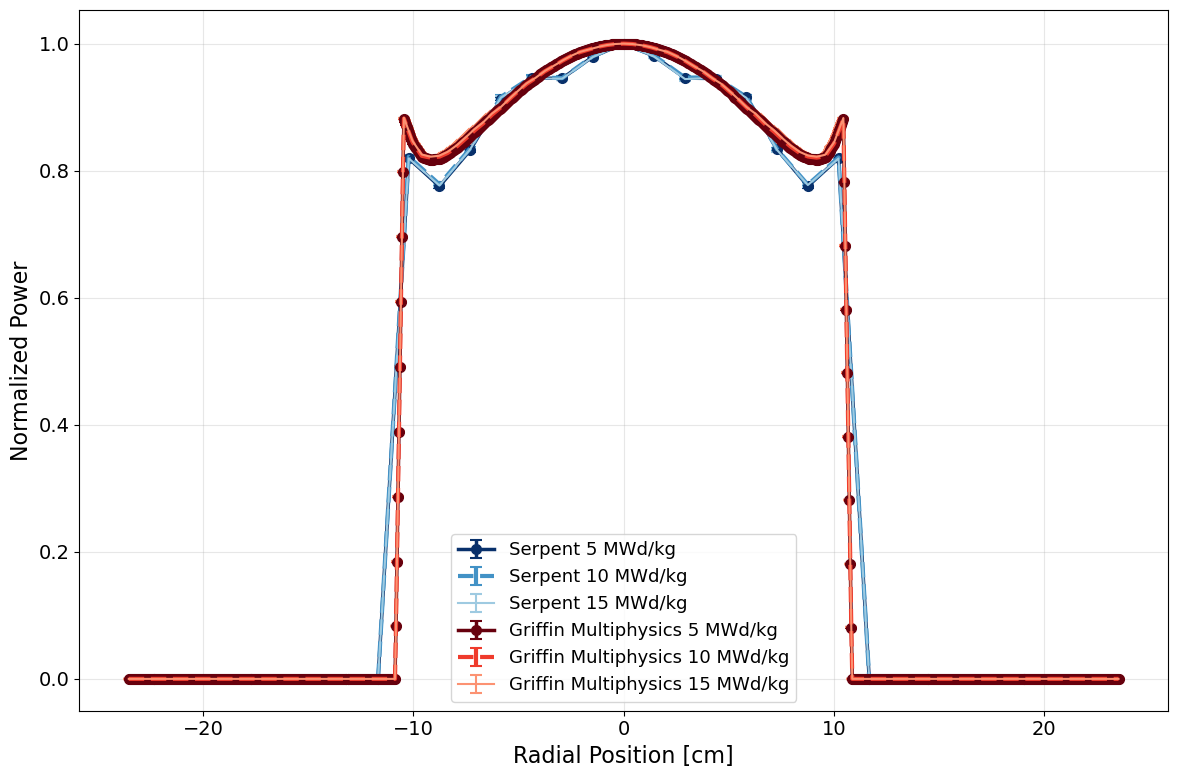


Note: Distributions are normalized. Integration analysis skipped.

AXIAL POWER DISTRIBUTION ANALYSIS
[0.00040721 0.000543   0.00063367 0.00069504 0.00072125 0.00071591
 0.00069942 0.00062448 0.0005025  0.00036338]
[0.0004035  0.00055471 0.00065017 0.00071478 0.00076368 0.00073756
 0.00069881 0.00062297 0.00051402 0.00036037]
[0.00041526 0.00057149 0.00066948 0.00071556 0.00076368 0.00073793
 0.00069979 0.00064195 0.00051606 0.00037082]


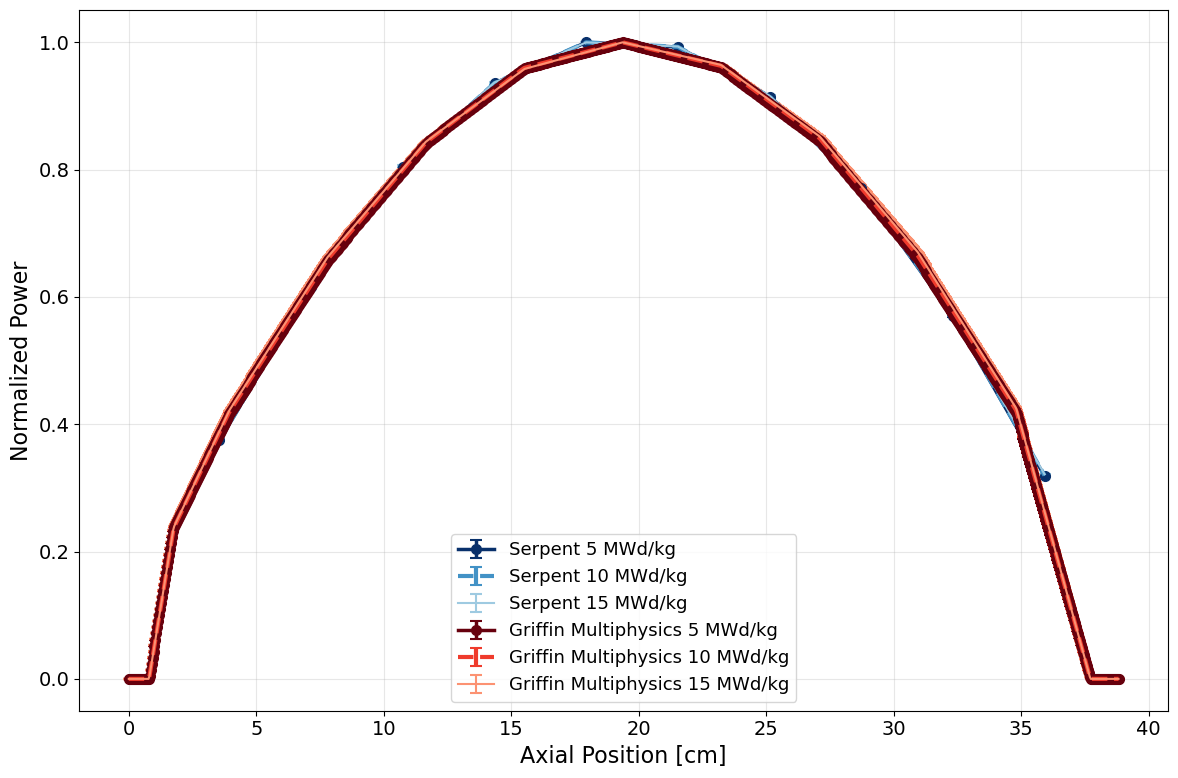


Note: Distributions are normalized. Integration analysis skipped.


In [57]:
print("="*60)
print("RADIAL POWER DISTRIBUTION ANALYSIS")
print("="*60)
radial_data, radial_serpent, radial_griffin, radial_rel_diff = analyze_power_distribution('radial', normalize=True, norm_type='peak')

print("\n" + "="*60)
print("AXIAL POWER DISTRIBUTION ANALYSIS")
print("="*60)
axial_data, axial_serpent, axial_griffin, axial_rel_diff = analyze_power_distribution('axial', normalize=True, norm_type='peak')


# Reactivity Coefficients

## Fuel Temperature Coefficient

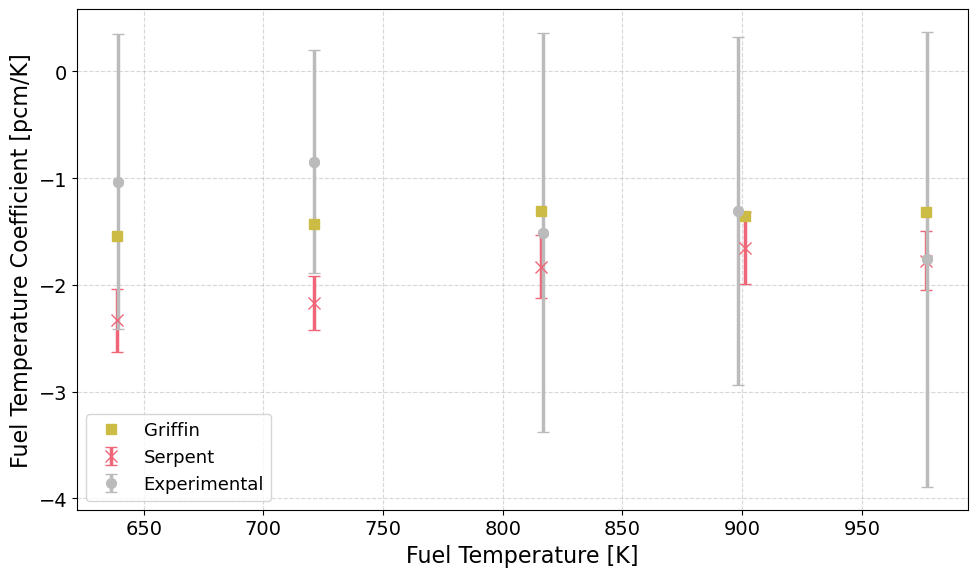

In [22]:
current_dir = Path.cwd()
base_path = current_dir / "Serpent/reactivity_worths/fuel_coeff/ftc_effect"
res_name  = 's82d_ac_c3_gcu_ringres.main_res.m'
temp_name = ['639','721','816','899','901','977','1070']
temp_list = [639, 721, 816, 899, 901, 977, 1070]
fuel_temp_list = [613.2536, 684.2536, 767.2536, 850.2536, 0, 934.2536, 0]
rho_list = []; unc_list = []; reac_list = []; reac_unc_list = []

for i in temp_name:
    res = st.read(Path((base_path/i/res_name).resolve()))
    k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
    rho_list.append((k-1)/k)
    unc_list.append(np.sqrt((1/k**2)**2 * k_unc**2))

for i, temp in enumerate(temp_list):
    if temp not in (1070, 899):
        reac = ((rho_list[i] - rho_list[i+1]) / (temp_list[i] - temp_list[i+1])) * 1e5
        unc  = np.sqrt(2) * (1/abs(temp_list[i]-temp_list[i+1])) * np.sqrt(unc_list[i]**2 + unc_list[i+1]**2) * 1e5
        reac_list.append(reac); reac_unc_list.append(unc * 3)

griff_temp_name = ['639','721','816','899','901','977','1000']
griff_temp_list = [639, 721, 816, 899, 901, 977, 1000]
griff_path  = current_dir / "Griffin/reactivity_worths/fuel_coeff/ftc_effect"
griff_rho_list = []; griff_reac_list = []
for i in griff_temp_name:
    res = pd.read_csv(Path((griff_path/i/'wet_core_csv.csv').resolve()))
    k = res['eigenvalue'].values[1]
    griff_rho_list.append((k-1)/k)
for i, temp in enumerate(griff_temp_list):
    if temp not in (1000, 899):
        griff_reac_list.append(((griff_rho_list[i]-griff_rho_list[i+1])/(griff_temp_list[i]-griff_temp_list[i+1]))*1e5)

exp_data = pd.read_csv((base_path/'plot-data.csv').resolve())
temp_list_plot = [639, 721, 816, 901, 977]

colors = ['#4477AA','#EE6677','#228833','#CCBB44','#66CCEE','#AA3377','#BBBBBB']
experiment_color = colors[-1]; serpent_color = colors[1]; griffin_color = colors[3]

plt.figure(figsize=(10, 6))
plt.errorbar(griff_temp_name[-5:] if False else temp_list_plot, griff_reac_list,
             yerr=None, fmt='s', markersize=_ms, label='Griffin', color=griffin_color)
plt.errorbar(temp_list_plot, reac_list, yerr=reac_unc_list,
             fmt='x', markersize=_ms+1, label="Serpent", color=serpent_color, capsize=_cs)
plt.errorbar(exp_data['x(kelvin)'].values, exp_data['y(pcm/K)'].values,
             yerr=3*exp_data['abs_unc'].values, fmt='o', markersize=_ms,
             label='Experimental', color=experiment_color, capsize=_cs)
plt.xlabel('Fuel Temperature [K]',                    fontsize=16)
plt.ylabel('Fuel Temperature Coefficient [pcm/K]',     fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout()
plt.show()


## Isothermal Temperature Coefficient

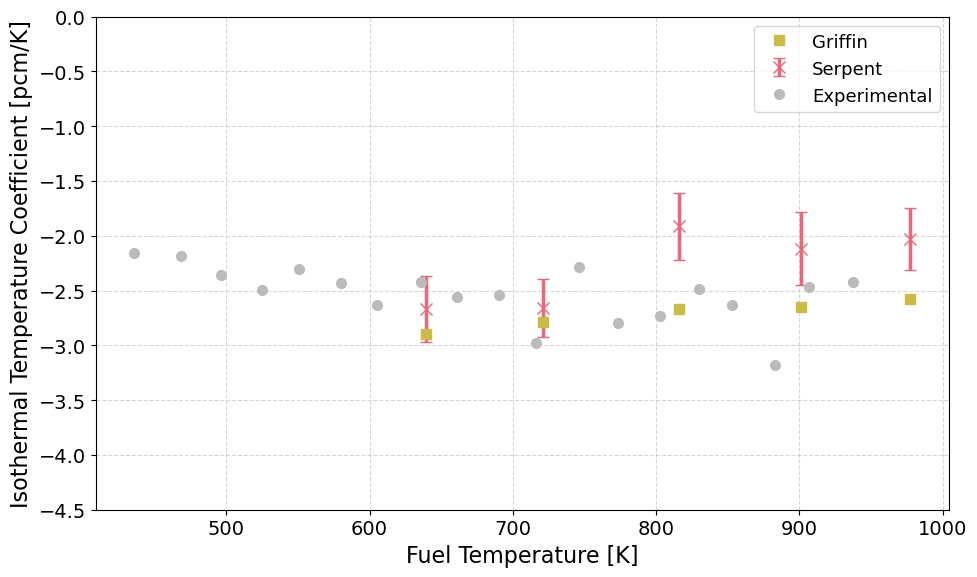

In [23]:
current_dir = Path.cwd()
base_path = current_dir / "Serpent/reactivity_worths/fuel_coeff/itc_effect"
res_name  = 's82d_ac_c3_gcu_ringres.main_res.m'
temp_name = ['639','721','816','899','901','977','1070']
temp_list = [639, 721, 816, 899, 901, 977, 1070]
rho_list  = []; unc_list = []; reac_list = []; reac_unc_list = []

for i in temp_name:
    res = st.read(Path((base_path/i/res_name).resolve()))
    k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
    rho_list.append((k-1)/k)
    unc_list.append(np.sqrt((1/k**2)**2 * k_unc**2))

for i, temp in enumerate(temp_list):
    if temp not in (1070, 899):
        reac = ((rho_list[i]-rho_list[i+1])/(temp_list[i]-temp_list[i+1]))*1e5
        unc  = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_list[i]**2+unc_list[i+1]**2)*1e5
        reac_list.append(reac); reac_unc_list.append(unc*3)

griff_temp_name = ['639','721','816','899','901','977','1000']
griff_temp_list = [639, 721, 816, 899, 901, 977, 1000]
griff_path  = current_dir / "Griffin/reactivity_worths/fuel_coeff/itc_effect"
griff_rho_list = []; griff_reac_list = []
for i in griff_temp_name:
    res = pd.read_csv(Path((griff_path/i/'wet_core_csv.csv').resolve()))
    k = res['eigenvalue'].values[1]; griff_rho_list.append((k-1)/k)
for i, temp in enumerate(griff_temp_list):
    if temp not in (1000, 899):
        griff_reac_list.append(((griff_rho_list[i]-griff_rho_list[i+1])/(griff_temp_list[i]-griff_temp_list[i+1]))*1e5)

exp_data = pd.read_csv((base_path/'itc_data.csv').resolve())
temp_list_plot = [639, 721, 816, 901, 977]

plt.figure(figsize=(10, 6))
plt.errorbar(temp_list_plot, griff_reac_list, yerr=None,
             fmt='s', markersize=_ms, label='Griffin', color=griffin_color)
plt.errorbar(temp_list_plot, reac_list, yerr=reac_unc_list,
             fmt='x', markersize=_ms+1, label="Serpent", color=serpent_color, capsize=_cs)
plt.errorbar(exp_data['x(kelvin)'].values, exp_data['y(pcm/K)'].values, yerr=None,
             fmt='o', markersize=_ms, label='Experimental', color=experiment_color)
plt.xlabel('Fuel Temperature [K]',                          fontsize=16)
plt.ylabel('Isothermal Temperature Coefficient [pcm/K]',     fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-4.5, 0); plt.tight_layout()
plt.show()


## Power Coefficient

### Method A

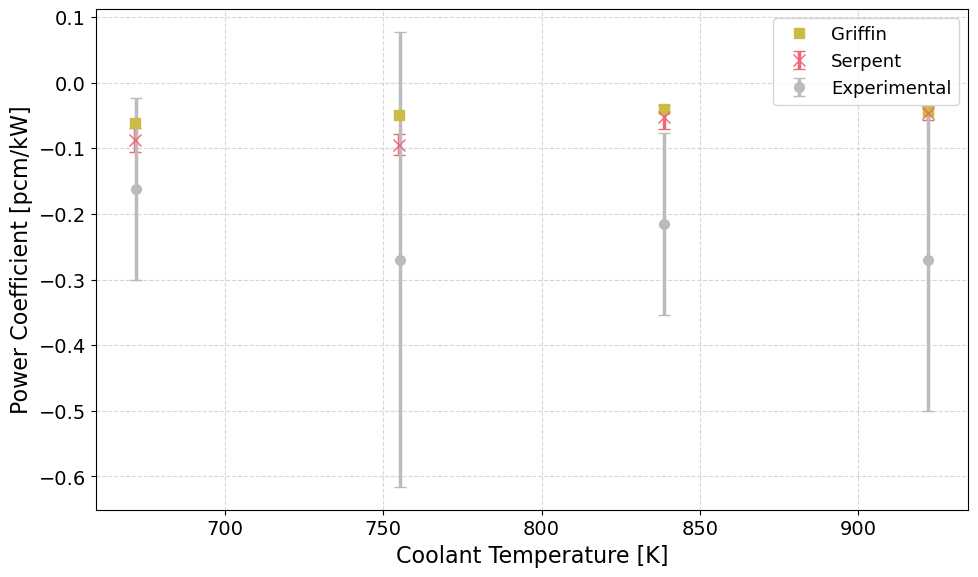

In [24]:
current_dir    = Path.cwd()
base_path      = current_dir / "Serpent/reactivity_worths/power_coeff"
res_name       = 'standardconditions.main_res.m'
temp_name      = ['601','672','755','838','899','922','1022']
temp_list      = [601, 672, 755, 838, 899, 922, 1022]
fuel_temp_list = [613.2536, 684.2536, 767.2536, 850.2536, 0, 934.2536, 0]
rho_list = []; unc_list = []; reac_list = []; reac_unc_list = []

for i in temp_name:
    res = st.read(Path((base_path/i/res_name).resolve()))
    k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
    rho_list.append((k-1)/k); unc_list.append(np.sqrt((1/k**2)**2*k_unc**2))

for i, temp in enumerate(temp_list):
    if temp not in (1022, 899):
        reac = ((rho_list[i]-rho_list[i+1])/(temp_list[i]-temp_list[i+1]))*1e5
        dP, UA = power_change(temp_list[i], fuel_temp_list[i])
        unc = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_list[i]**2+unc_list[i+1]**2)*1e5
        reac_list.append(reac/UA); reac_unc_list.append(unc/UA*3)

griff_temp_name = ['601','672','755','838','899','922','1022']
griff_temp_list = [601, 672, 755, 838, 899, 922, 1022]
griff_path2 = current_dir / "Griffin/reactivity_worths/pow_coeff"
griff_rho_list = []; griff_reac_list = []
for i in griff_temp_name:
    res = pd.read_csv(Path((griff_path2/i/'wet_core_csv.csv').resolve()))
    k = res['eigenvalue'].values[1]; griff_rho_list.append((k-1)/k)
for i, temp in enumerate(griff_temp_list):
    if temp not in (1022, 899):
        reac = ((griff_rho_list[i]-griff_rho_list[i+1])/(griff_temp_list[i]-griff_temp_list[i+1]))*1e5
        dP, UA = power_change(griff_temp_list[i], fuel_temp_list[i])
        griff_reac_list.append(reac/UA)

exp_data_A = pd.read_csv((current_dir/base_path/'pow_coeff_A.csv').resolve())
temp_list_plot = [601, 671.8, 755.1, 838.5, 921.98]

plt.figure(figsize=(10, 6))
plt.errorbar(temp_list_plot[-4:], griff_reac_list[-4:], yerr=None,
             fmt='s', markersize=_ms, label='Griffin', color=griffin_color)
plt.errorbar(temp_list_plot[-4:], reac_list[-4:], yerr=reac_unc_list[-4:],
             fmt='x', markersize=_ms+1, label="Serpent", color=serpent_color, capsize=_cs)
plt.errorbar(exp_data_A['x(K)'].values[-4:], exp_data_A['y(pcm/kW)'].values[-4:],
             yerr=3*exp_data_A['unc'].values[-4:], fmt='o', markersize=_ms,
             label='Experimental', color=experiment_color, capsize=_cs)
plt.xlabel('Coolant Temperature [K]',     fontsize=16)
plt.ylabel('Power Coefficient [pcm/kW]',   fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout()
plt.show()


### Method B

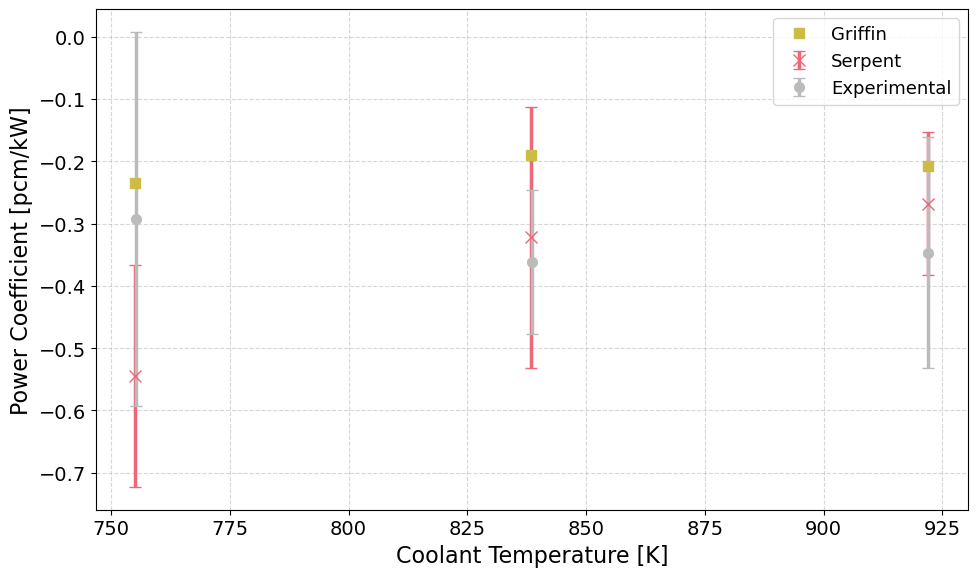

In [25]:
current_dir  = Path.cwd()
ftc_path     = current_dir / "Serpent/reactivity_worths/power_coeff"
grid_path    = current_dir / "Serpent/reactivity_worths/power_coeff/grid_effect"
res_name     = 'standardconditions.main_res.m'
temp_name    = ['601','672','755','838','899','922','1022']
temp_list    = [601, 672, 755, 838, 899, 922, 1022]
fuel_temp_list = [613.2536, 684.2536, 767.2536, 850.2536, 0, 934.2536, 0]
rho_ftc_list = []; unc_ftc_list = []; rho_grid_list = []; unc_grid_list = []
reac_list = []; reac_unc_list = []

for i in temp_name:
    res_ftc  = st.read(Path((ftc_path /i/res_name).resolve()))
    res_grid = st.read(Path((grid_path/i/res_name).resolve()))
    for res, rho_l, unc_l in [(res_ftc, rho_ftc_list, unc_ftc_list),
                               (res_grid, rho_grid_list, unc_grid_list)]:
        k = res['anaKeff'][0]; k_unc = res['anaKeff'][1]
        rho_l.append((k-1)/k); unc_l.append(np.sqrt((1/k**2)**2*k_unc**2))

for i, temp in enumerate(temp_list):
    if temp not in (1022, 899):
        reac_ftc  = ((rho_ftc_list[i] -rho_ftc_list[i+1]) /(temp_list[i]-temp_list[i+1]))*1e5
        reac_grid = ((rho_grid_list[i]-rho_grid_list[i+1])/(temp_list[i]-temp_list[i+1]))*1e5
        dP, UA = power_change(temp_list[i], fuel_temp_list[i])
        WC = coolant_flow_heat_capacity(temp_list[i], fuel_temp_list[i])
        pow_coeff = reac_ftc/UA + (0.41*reac_ftc + reac_grid/2)/WC
        unc_ftc   = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_ftc_list[i]**2+unc_ftc_list[i+1]**2)*1e5
        unc_grid  = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_grid_list[i]**2+unc_grid_list[i+1]**2)*1e5
        unc_pow   = np.sqrt((1/UA+1/WC)**2*unc_ftc**2 + (1/(2*WC))**2*unc_grid**2)
        reac_list.append(pow_coeff); reac_unc_list.append(unc_pow*3)

griff_temp_name = ['601','672','755','838','899','922','1022']
griff_temp_list = [601, 672, 755, 838, 899, 922, 1022]
griff_path2     = current_dir / "Griffin/reactivity_worths/pow_coeff"
griff_grid_path = current_dir / "Griffin/reactivity_worths/fuel_coeff/grid_effect"
griff_rho_list = []; griff_rho_grid_list = []; griff_reac_list = []
for i in griff_temp_name:
    for pth, lst in [(griff_path2, griff_rho_list),(griff_grid_path, griff_rho_grid_list)]:
        res = pd.read_csv(Path((pth/i/'wet_core_csv.csv').resolve()))
        lst.append((res['eigenvalue'].values[1]-1)/res['eigenvalue'].values[1])
for i, temp in enumerate(griff_temp_list):
    if temp not in (1022, 899):
        reac_ftc  = ((griff_rho_list[i] -griff_rho_list[i+1]) /(griff_temp_list[i]-griff_temp_list[i+1]))*1e5
        reac_grid = ((griff_rho_grid_list[i]-griff_rho_grid_list[i+1])/(griff_temp_list[i]-griff_temp_list[i+1]))*1e5
        dP, UA = power_change(griff_temp_list[i], fuel_temp_list[i])
        WC = coolant_flow_heat_capacity(griff_temp_list[i], fuel_temp_list[i])
        griff_reac_list.append(reac_ftc/UA + (0.41*reac_ftc + reac_grid/2)/WC)

exp_data_B = pd.read_csv((current_dir/"Serpent/reactivity_worths/power_coeff/pow_coeff_B.csv").resolve())
temp_list_plot = [601, 672, 755.1, 838.5, 921.98]

plt.figure(figsize=(10, 6))
plt.errorbar(temp_list_plot[-3:], griff_reac_list[-3:], yerr=None,
             fmt='s', markersize=_ms, label='Griffin', color=griffin_color)
plt.errorbar(temp_list_plot[-3:], reac_list[-3:], yerr=reac_unc_list[-3:],
             fmt='x', markersize=_ms+1, label="Serpent", color=serpent_color, capsize=_cs)
plt.errorbar(exp_data_B['x(K)'].values[-3:], exp_data_B['y(pcm/kW)'].values[-3:],
             yerr=3*exp_data_B['unc'].values[-3:], fmt='o', markersize=_ms,
             label='Experimental', color=experiment_color, capsize=_cs)
plt.xlabel('Coolant Temperature [K]',     fontsize=16)
plt.ylabel('Power Coefficient [pcm/kW]',   fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout()
plt.savefig('pow_coeff_B.png', dpi=400)
plt.show()


### Method C

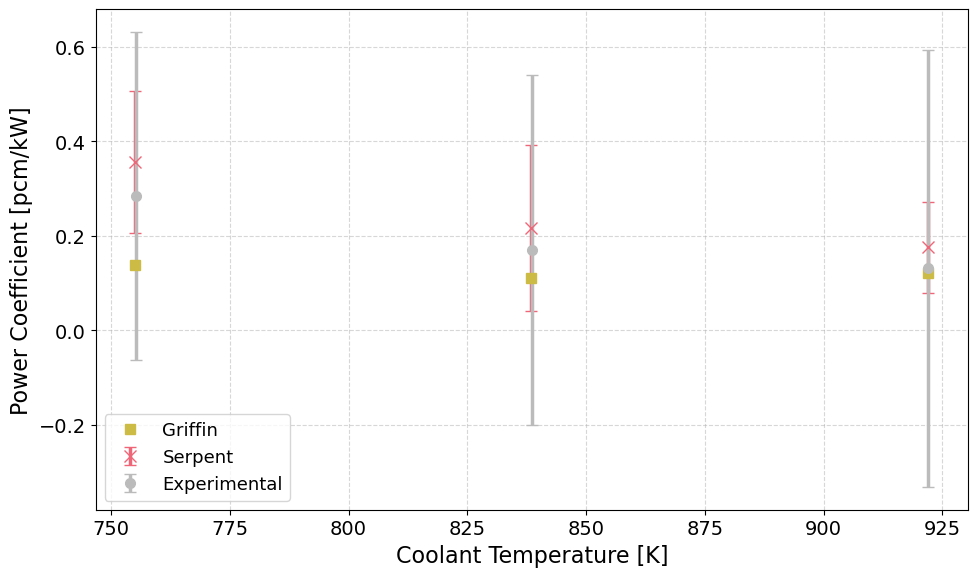

In [26]:
# (same data loading as Method B — reuse variables from above)
reac_list_C = []; reac_unc_list_C = []
for i, temp in enumerate(temp_list):
    if temp not in (1022, 899):
        reac_ftc  = ((rho_ftc_list[i] -rho_ftc_list[i+1]) /(temp_list[i]-temp_list[i+1]))*1e5
        reac_grid = ((rho_grid_list[i]-rho_grid_list[i+1])/(temp_list[i]-temp_list[i+1]))*1e5
        dP, UA = power_change(temp_list[i], fuel_temp_list[i])
        WC = coolant_flow_heat_capacity(temp_list[i], fuel_temp_list[i])
        pow_coeff = reac_ftc/UA - (0.41*reac_ftc + reac_grid/2)/WC
        unc_ftc  = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_ftc_list[i]**2+unc_ftc_list[i+1]**2)*1e5
        unc_grid = np.sqrt(2)*(1/abs(temp_list[i]-temp_list[i+1]))*np.sqrt(unc_grid_list[i]**2+unc_grid_list[i+1]**2)*1e5
        unc_pow  = np.sqrt((1/UA-1/WC)**2*unc_ftc**2 + (1/(2*WC))**2*unc_grid**2)
        reac_list_C.append(pow_coeff); reac_unc_list_C.append(unc_pow*3)

griff_reac_list_C = []
for i, temp in enumerate(griff_temp_list):
    if temp not in (1022, 899):
        reac_ftc  = ((griff_rho_list[i] -griff_rho_list[i+1]) /(griff_temp_list[i]-griff_temp_list[i+1]))*1e5
        reac_grid = ((griff_rho_grid_list[i]-griff_rho_grid_list[i+1])/(griff_temp_list[i]-griff_temp_list[i+1]))*1e5
        dP, UA = power_change(griff_temp_list[i], fuel_temp_list[i])
        WC = coolant_flow_heat_capacity(griff_temp_list[i], fuel_temp_list[i])
        griff_reac_list_C.append(reac_ftc/UA - (0.41*reac_ftc + reac_grid/2)/WC)

exp_data_C = pd.read_csv((current_dir/"Serpent/reactivity_worths/power_coeff/pow_coeff_C.csv").resolve())

plt.figure(figsize=(10, 6))
plt.errorbar(temp_list_plot[-3:], griff_reac_list_C[-3:], yerr=None,
             fmt='s', markersize=_ms, label='Griffin', color=griffin_color)
plt.errorbar(temp_list_plot[-3:], reac_list_C[-3:], yerr=reac_unc_list_C[-3:],
             fmt='x', markersize=_ms+1, label="Serpent", color=serpent_color, capsize=_cs)
plt.errorbar(exp_data_C['x(K)'].values[-3:], exp_data_C['y(pcm/kW)'].values[-3:],
             yerr=3*exp_data_C['unc'].values[-3:], fmt='o', markersize=_ms,
             label='Experimental', color=experiment_color, capsize=_cs)
plt.xlabel('Coolant Temperature [K]',     fontsize=16)
plt.ylabel('Power Coefficient [pcm/kW]',   fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.legend(fontsize=13); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout()
plt.savefig('pow_coeff_C.png', dpi=400)
plt.show()


## Poison Worth

In [27]:
current_dir  = Path.cwd()
poison_path  = Path("Serpent/reactivity_worths/poison_coeff")
res_name     = 's82d_ac_c3_gcu_ringres.main_res.m'
poison_res   = st.read((current_dir/poison_path/res_name).resolve())
standard_res = st.read((current_dir/'Serpent/standard_reference_sol'/res_name).resolve())
no_xenon_res = st.read((current_dir/poison_path/'no_xenon'/res_name).resolve())
xenon_res    = st.read((current_dir/poison_path/'xenon'/res_name).resolve())

def _rho_unc(k, k_unc):
    return (k-1)/k, np.sqrt((1/k**2)**2 * k_unc**2)

poi_rho,   poi_rho_unc   = _rho_unc(poison_res['anaKeff'][0],   poison_res['anaKeff'][1])
stand_rho, stand_rho_unc = _rho_unc(standard_res['anaKeff'][0], standard_res['anaKeff'][1])
no_xen_rho, _            = _rho_unc(no_xenon_res['anaKeff'][0], no_xenon_res['anaKeff'][1])
xen_rho,  xen_rho_unc    = _rho_unc(xenon_res['anaKeff'][0],    xenon_res['anaKeff'][1])

poison_worth       = (stand_rho - poi_rho) * 1e5
xen_worth          = (no_xen_rho - xen_rho) * 1e5
total_poison_worth = poison_worth + xen_worth
poison_worth_unc   = np.sqrt(poi_rho_unc**2 + stand_rho_unc**2 + xen_rho_unc**2) * 1e5

exp_poison_worth = -1130; exp_poison_unc = 240
difference = total_poison_worth - exp_poison_worth
difference_unc = np.sqrt(poison_worth_unc**2 + exp_poison_unc**2)
print(f"Modeled poison worth is {total_poison_worth:.2f} ± {poison_worth_unc:.2f} pcm (1σ)")
print(f"Experimental poison worth is {exp_poison_worth:.2f} ± {exp_poison_unc:.2f} pcm (1σ)")
print(f"Reactivity difference is {difference:.2f} ± {difference_unc:.2f} pcm (1σ)")


Modeled poison worth is -1246.04 ± 19.09 pcm (1σ)
Experimental poison worth is -1130.00 ± 240.00 pcm (1σ)
Reactivity difference is -116.04 ± 240.76 pcm (1σ)


## Coolant Worth

In [28]:
current_dir = Path.cwd()
nak_res   = st.read((current_dir/"Serpent/reactivity_worths/NaK_worth/cold_nak/standardconditions.main_res.m").resolve())
nonak_res = st.read((current_dir/"Serpent/reactivity_worths/NaK_worth/cold_nonak/standardconditions.main_res.m").resolve())

no_nak_rho, no_nak_rho_unc = _rho_unc(nonak_res['anaKeff'][0], nonak_res['anaKeff'][1])
stand_rho,  stand_rho_unc  = _rho_unc(nak_res['anaKeff'][0],   nak_res['anaKeff'][1])
nak_worth     = (no_nak_rho - stand_rho) * 1e5
nak_worth_unc = np.sqrt(no_nak_rho_unc**2 + stand_rho_unc**2) * 1e5
exp_nak_worth = -310; exp_nak_unc = 20
difference = -nak_worth - exp_nak_worth
difference_unc = np.sqrt(nak_worth_unc**2 + exp_nak_unc**2)
print(f"NaK worth is -{nak_worth:.2f} ± {nak_worth_unc:.2f} pcm (1σ)")
print(f"Experimental NaK worth is {exp_nak_worth:.2f} ± {exp_nak_unc:.2f} pcm (1σ)")
print(f"Reactivity difference is {difference:.2f} ± {difference_unc:.2f} pcm (1σ)")


NaK worth is -27.43 ± 9.38 pcm (1σ)
Experimental NaK worth is -310.00 ± 20.00 pcm (1σ)
Reactivity difference is 282.57 ± 22.09 pcm (1σ)


## Xenon Worth

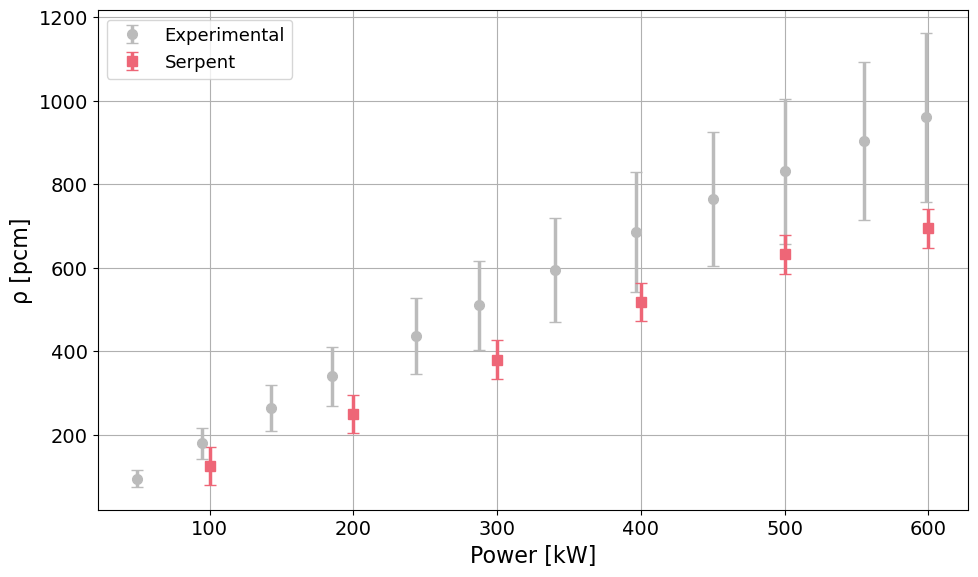

In [29]:
xenon_path   = current_dir / "Serpent/reactivity_worths/xenon_worth"
csv_df       = pd.read_csv(xenon_path / 'exp_data.csv')
x_csv        = csv_df['x(power[kw])']
y_csv        = csv_df['y(pcm)']
unc_csv      = 3*csv_df['unc(pcm)']
power_levels = [f"{i}kw" for i in range(100, 601, 100)]
res_name     = 's82d_ac_c3_gcu_ringres.main_res.m'
reactivity_diffs = []; reactivity_uncs = []

for power in power_levels:
    base_dir   = xenon_path / power
    xenon_res  = st.read(base_dir / 'xenon'    / res_name)
    nox_res    = st.read(base_dir / 'no_xenon' / res_name)
    k_xen = xenon_res['anaKeff'][0]; k_xen_unc = xenon_res['anaKeff'][1]
    k_nox = nox_res['anaKeff'][0];   k_nox_unc = nox_res['anaKeff'][1]
    rho_xen = (k_xen-1)/k_xen; rho_nox = (k_nox-1)/k_nox
    rho_xen_unc = np.abs(1/k_xen**2) * k_xen_unc
    rho_nox_unc = np.abs(1/k_nox**2) * k_nox_unc
    worth_pcm   = (rho_nox - rho_xen) * 1e5
    worth_unc   = 3*np.sqrt(rho_xen_unc**2 + rho_nox_unc**2) * 1e5
    reactivity_diffs.append(worth_pcm); reactivity_uncs.append(worth_unc)

x_sim = [int(p.strip('kw')) for p in power_levels[:len(reactivity_diffs)]]

plt.figure(figsize=(10, 6))
plt.errorbar(x_csv, y_csv, yerr=unc_csv, fmt='o', markersize=_ms,
             label='Experimental', capsize=_cs, color=experiment_color)
plt.errorbar(x_sim, reactivity_diffs, yerr=reactivity_uncs, fmt='s', markersize=_ms,
             label='Serpent', capsize=_cs, color=serpent_color)
plt.xlabel('Power [kW]', fontsize=16)
plt.ylabel('ρ [pcm]',    fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True); plt.legend(fontsize=13); plt.tight_layout()
plt.show()
